<a href="https://colab.research.google.com/github/ayeshabaig575/FYP/blob/main/FYP-III%20SEGMENTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc # Import roc_curve and auc here
# Import the SVC class
from sklearn.svm import SVC
from tensorflow.keras.layers import Dropout, Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, GlobalAveragePooling2D, Dense
from tensorflow.keras.layers import Dropout
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import itertools
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings("ignore")
# Import seaborn
import seaborn as sns # This line imports the seaborn library and assigns it to the alias 'sns'

print('Modules loaded.')

Modules loaded.


In [ ]:
# Generate data paths with labels
data_dir = '/content/drive/MyDrive/Dataset_BUSI_with_GT'
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

In [ ]:
# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis=1)
strat = df['labels']

In [ ]:
train_df, test_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=123, stratify=strat)


In [ ]:
# Function to load and preprocess images
def load_and_preprocess_images(filepaths, img_size=(224, 224)):
    images = []
    for filepath in filepaths:
        img = cv2.imread(filepath)
        img = cv2.resize(img, img_size)
        img = img.astype('float32')  # Convert to float32
        img = preprocess_input(img)  # Preprocess for DenseNet201
        images.append(img)
    return np.array(images)

In [ ]:
# Load training and testing images
X_train = load_and_preprocess_images(train_df['filepaths'].values)
y_train = train_df['labels'].values
X_test = load_and_preprocess_images(test_df['filepaths'].values)
y_test = test_df['labels'].values

In [ ]:
# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test) # Encode y_test using the same LabelEncoder

In [ ]:
# Load DenseNet201 model for feature extraction
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the last 20 layers of DenseNet201
for layer in base_model.layers[:-20]:  # Freeze all layers except the last 20
    layer.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)  # L2 Regularization
x = Dropout(0.6)(x)  # Dropout to prevent overfitting
predictions = Dense(len(le.classes_), activation='softmax', kernel_regularizer=l2(0.01))(x)  # L2 Regularization

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Create the complete model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model for 40 epochs
epochs = 40
history = model.fit(X_train, y_train_encoded, validation_split=0.2, epochs=epochs, batch_size=32)


Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.5373 - loss: 5.5304 - val_accuracy: 0.7787 - val_loss: 4.6495
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 153ms/step - accuracy: 0.7654 - loss: 4.5605 - val_accuracy: 0.8024 - val_loss: 4.1127
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.7892 - loss: 4.0769 - val_accuracy: 0.7984 - val_loss: 3.7101
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.8193 - loss: 3.6810 - val_accuracy: 0.8340 - val_loss: 3.3460
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.8708 - loss: 3.2595 - val_accuracy: 0.8656 - val_loss: 3.0297
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.9106 - loss: 2.9263 - val_accuracy: 0.8854 - val_loss: 2.7653
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.9078 - loss: 2.6943 - val_accuracy: 0.8972 - val_loss: 2.5561
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.9343 - loss: 2.4383 - val_accuracy: 0.

In [ ]:
# Extract features using the trained model
X_train_features = model.predict(X_train)
X_test_features = model.predict(X_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 770ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step


In [ ]:
# Flatten the features
X_train_features = X_train_features.reshape(X_train_features.shape[0], -1)
X_test_features = X_test_features.reshape(X_test_features.shape[0], -1)

In [ ]:
# Train the SVM model
svm_model = SVC(kernel='linear', C=1.0, random_state=43, probability=True)  # Enable probability for ROC curve
svm_model.fit(X_train_features, y_train_encoded)

SVC(kernel='linear', probability=True, random_state=43)

In [ ]:
# Make predictions
y_pred = svm_model.predict(X_test_features)
y_pred_proba = svm_model.predict_proba(X_test_features)  # Probabilities for ROC curve

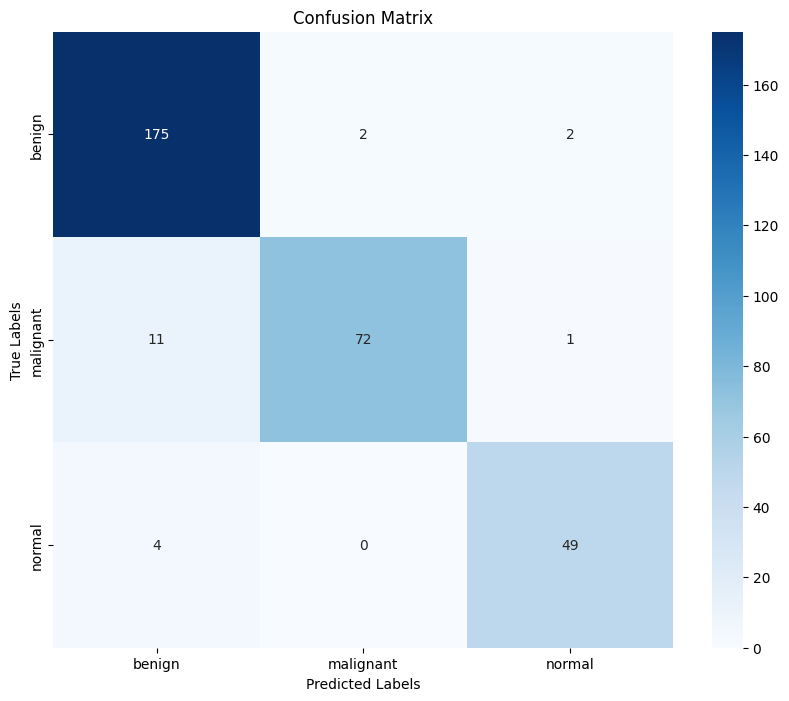

In [ ]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

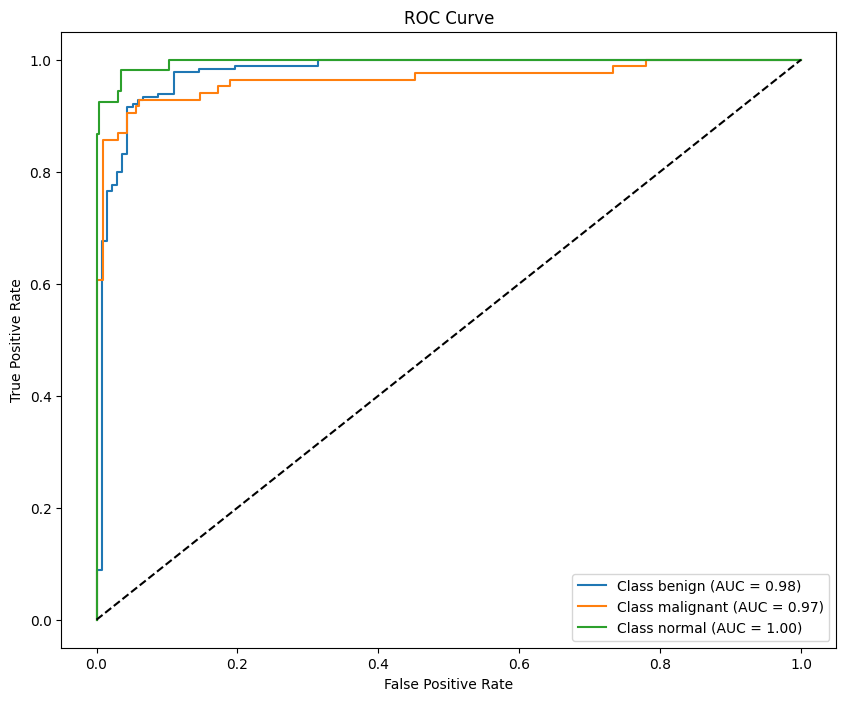

In [ ]:
# 2. ROC Curve and AUC Score
plt.figure(figsize=(10, 8))
for i in range(len(le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_encoded == i, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {le.classes_[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
# Classification report
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      benign       0.92      0.98      0.95       179
   malignant       0.97      0.86      0.91        84
      normal       0.94      0.92      0.93        53

    accuracy                           0.94       316
   macro avg       0.95      0.92      0.93       316
weighted avg       0.94      0.94      0.94       316



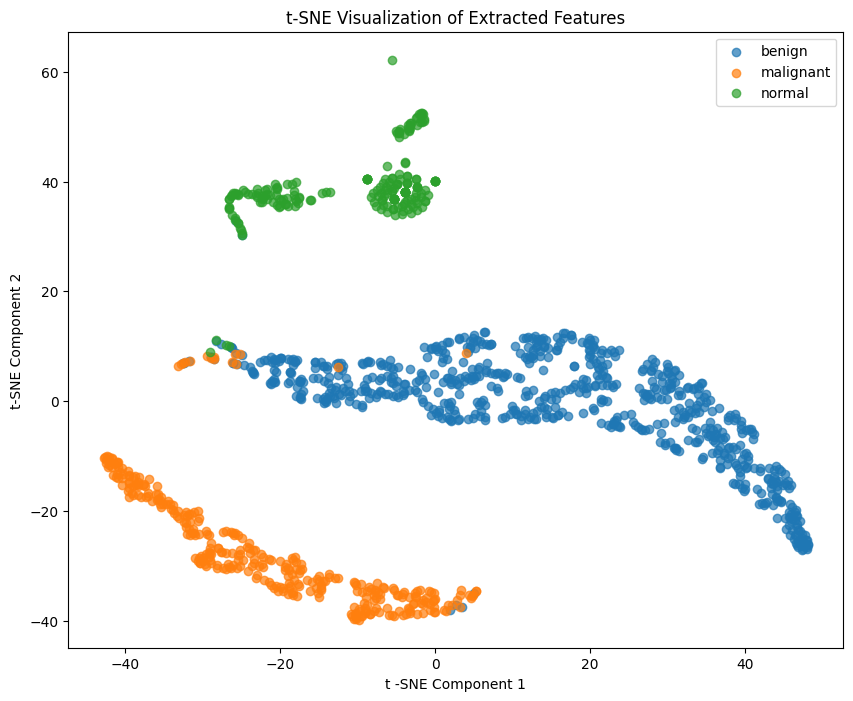

In [ ]:
# 3. t-SNE Visualization of Extracted Features
# Import TSNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train_features)

plt.figure(figsize=(10, 8))
for i in range(len(le.classes_)):
    indices = np.where(y_train_encoded == i)
    plt.scatter(X_train_tsne[indices, 0], X_train_tsne[indices, 1], label=le.classes_[i], alpha=0.7)
plt.title('t-SNE Visualization of Extracted Features')
plt.xlabel('t -SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()

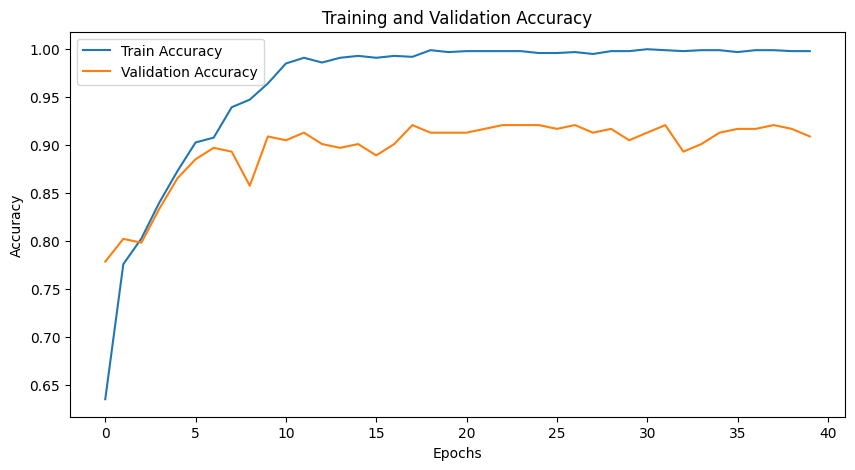

In [ ]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


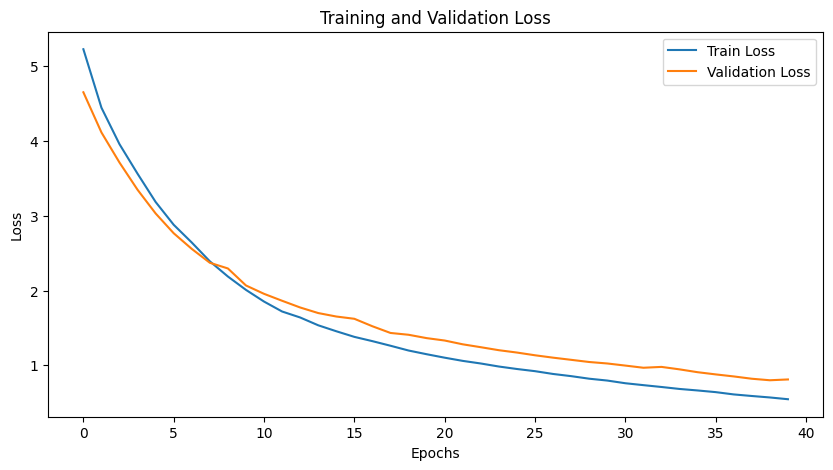

In [ ]:
# Plot Training & Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Function to display extracted features
def plot_feature_maps(model, X_sample, layer_name):
    feature_extractor = Model(inputs=model.input,
                              outputs=model.get_layer(layer_name).output)
    feature_maps = feature_extractor.predict(np.expand_dims(X_sample, axis=0))
    feature_maps = np.squeeze(feature_maps)
    num_maps = feature_maps.shape[-1]

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < num_maps:
            ax.imshow(feature_maps[:, :, i], cmap='viridis')
            ax.axis('off')
    plt.suptitle(f'Feature Maps from Layer: {layer_name}')
    plt.show()

In [ ]:
# Function to visualize true vs predicted labels
def visualize_predictions(X_test, y_test, y_pred, le, num_samples=10):
    plt.figure(figsize=(15, 5))

    indices = np.random.choice(len(X_test), num_samples, replace=False)
    for i, idx in enumerate(indices):
        img = X_test[idx]
        true_label = le.inverse_transform([y_test[idx]])[0]
        pred_label = le.inverse_transform([y_pred[idx]])[0]

        plt.subplot(2, num_samples // 2, i + 1)
        plt.imshow(cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2RGB))
        plt.title(f'True: {true_label}\nPred: {pred_label}', fontsize=10)
        plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


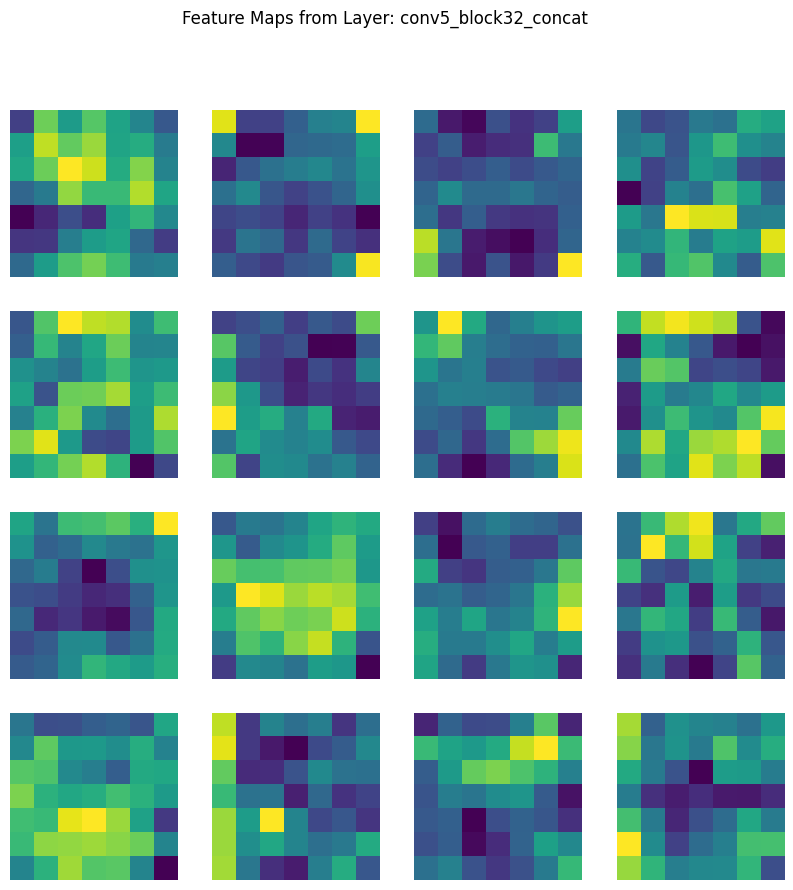

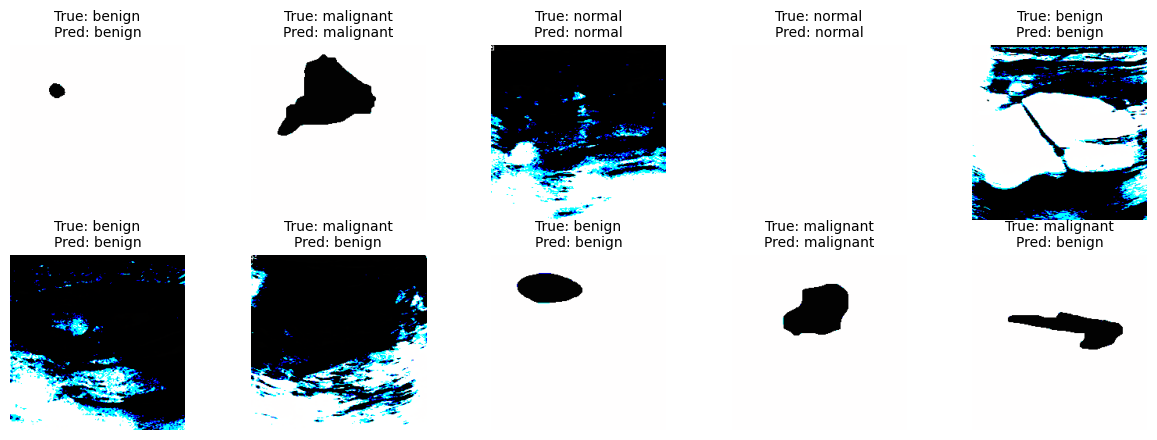

In [ ]:
# Plot extracted feature maps
plot_feature_maps(model, X_test[0], 'conv5_block32_concat')

# Visualize classification results
visualize_predictions(X_test, y_test_encoded, y_pred, le)


In [ ]:
# Import the joblib library
import joblib

# Save the model using joblib
joblib.dump(svm_model, 'svm_model.pkl')

['svm_model.pkl']

# **SEGMENTATION**




In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.utils import to_categorical

# Step 1: Filter the Classified Images (Benign or Malignant)
cancerous_indices = np.where((y_pred == 1) | (y_pred == 2))[0]  # Indices of Benign and Malignant images
cancerous_images = X_test[cancerous_indices]


In [ ]:
# Step 2: Define the Multi-Class U-Net Model
def unet_model(input_size=(224, 224, 3), num_classes=3):  # num_classes = 3 for Benign, Malignant, Normal
    inputs = Input(input_size)

    # Downsample
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    # Bottleneck
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(conv5)

    # Upsample
    up6 = UpSampling2D(size=(2, 2))(conv5)
    up6 = concatenate([up6, conv4], axis=-1)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(up6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(conv6)
    up7 = UpSampling2D(size=(2, 2))(conv6)
    up7 = concatenate([up7, conv3], axis=-1)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(up7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(conv7)

    up8 = UpSampling2D(size=(2, 2))(conv7)
    up8 = concatenate([up8, conv2], axis=-1)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(up8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(conv8)

    up9 = UpSampling2D(size=(2, 2))(conv8)
    up9 = concatenate([up9, conv1], axis=-1)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(up9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(conv9)
    # Output layer for multi-class segmentation
    outputs = Conv2D(num_classes, 1, activation='softmax')(conv9)  # Softmax for multi-class

    model = Model(inputs=[inputs], outputs=[outputs])
    return model




In [ ]:
# Load or define the U-Net model
num_classes = 3  # Benign, Malignant, Normal
unet = unet_model(num_classes=num_classes)
unet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Step 3: Prepare Ground Truth Masks for Multi-Class Segmentation
# Assuming you have ground truth masks in one-hot encoded format
def load_masks(filepaths, num_classes=3):
    masks = []
    for filepath in filepaths:
        mask = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (224, 224))
        # Ensure pixel values are within the expected range
        mask = np.clip(mask, 0, num_classes - 1) # clip values exceeding the range
        mask = to_categorical(mask, num_classes=num_classes)  # One-hot encode the mask
        masks.append(mask)
    return np.array(masks)

In [ ]:
# Load masks for cancerous images (assuming you have them)
cancerous_masks = load_masks(filepaths=test_df.iloc[cancerous_indices]['filepaths'].values, num_classes=num_classes)

In [ ]:
# Train the U-Net model (if you have ground truth masks)
unet.fit(cancerous_images, cancerous_masks, batch_size=8, epochs=10, validation_split=0.2)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5275 - loss: 0.9182 - val_accuracy: 0.6545 - val_loss: 0.6496
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 407ms/step - accuracy: 0.6865 - loss: 0.6094 - val_accuracy: 0.7371 - val_loss: 0.6015
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 391ms/step - accuracy: 0.7841 - loss: 0.5234 - val_accuracy: 0.7649 - val_loss: 0.5069
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 393ms/step - accuracy: 0.8705 - loss: 0.3572 - val_accuracy: 0.7553 - val_loss: 0.5676
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 377ms/step - accuracy: 0.7838 - loss: 0.4895 - val_accuracy: 0.7693 - val_loss: 0.4666
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - accuracy: 0.7643 - loss: 0.4790 - val_accuracy: 0.8736 - val_loss: 0.3631
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 382ms/step - accuracy: 0.8683 - loss: 0.4004 - val_accuracy: 0.7919 - val_loss: 0.4689
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - accuracy: 0.8163 - loss: 0.4585 - val_accuracy:

In [ ]:
# Predict segmentation masks for cancerous images
predicted_masks = unet.predict(cancerous_images)


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 819ms/step


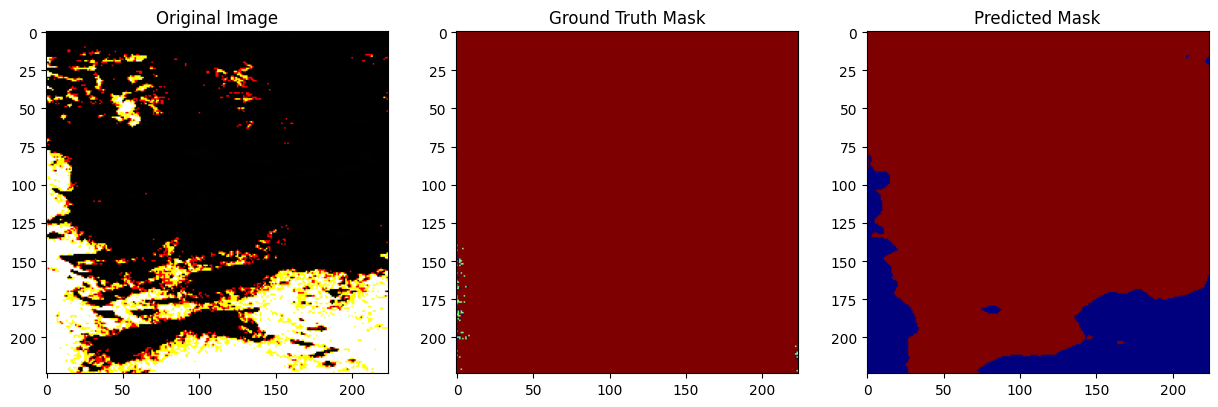

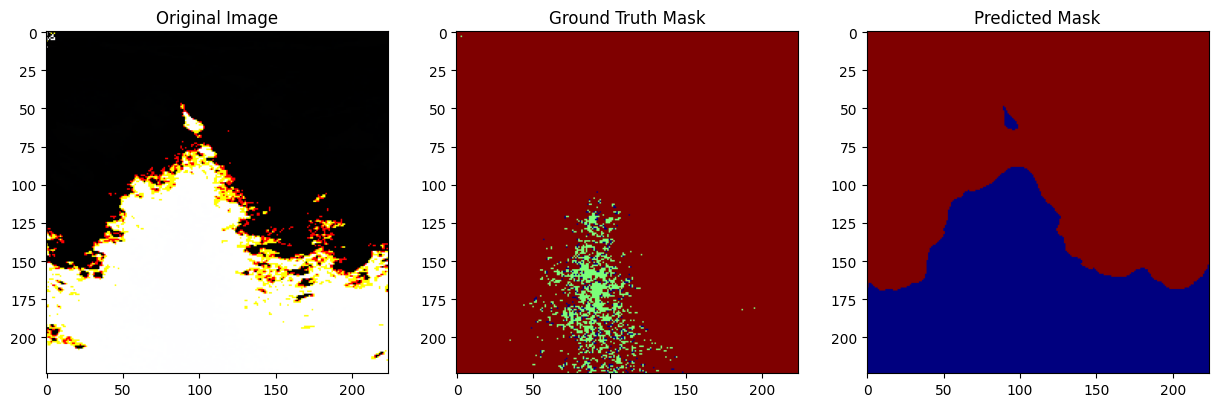

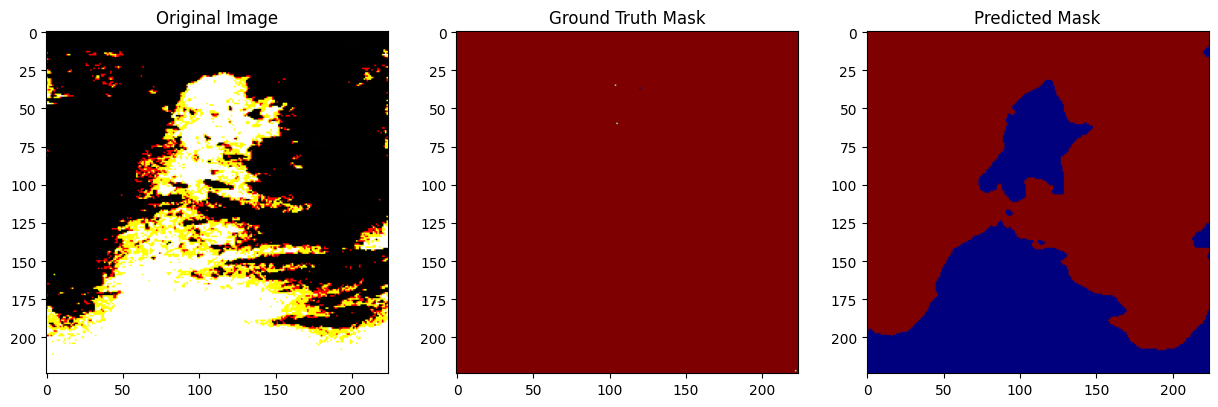

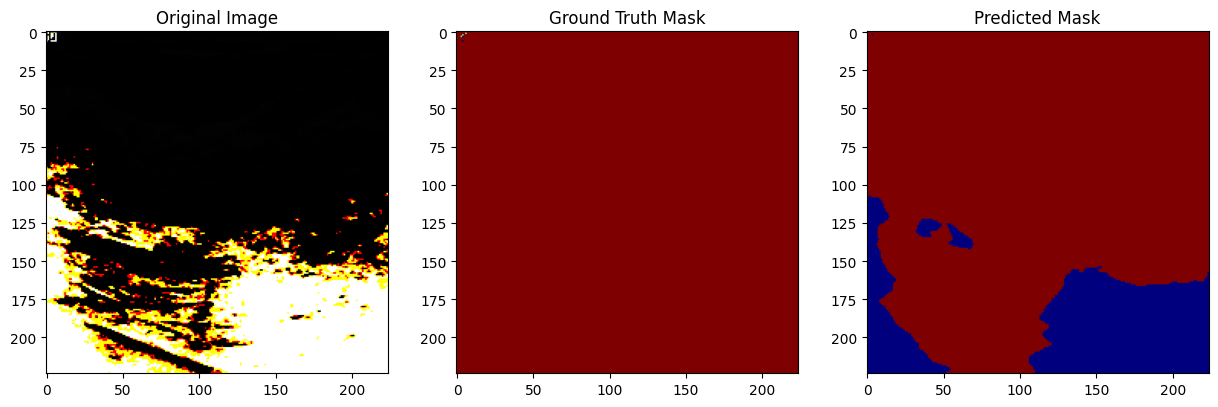

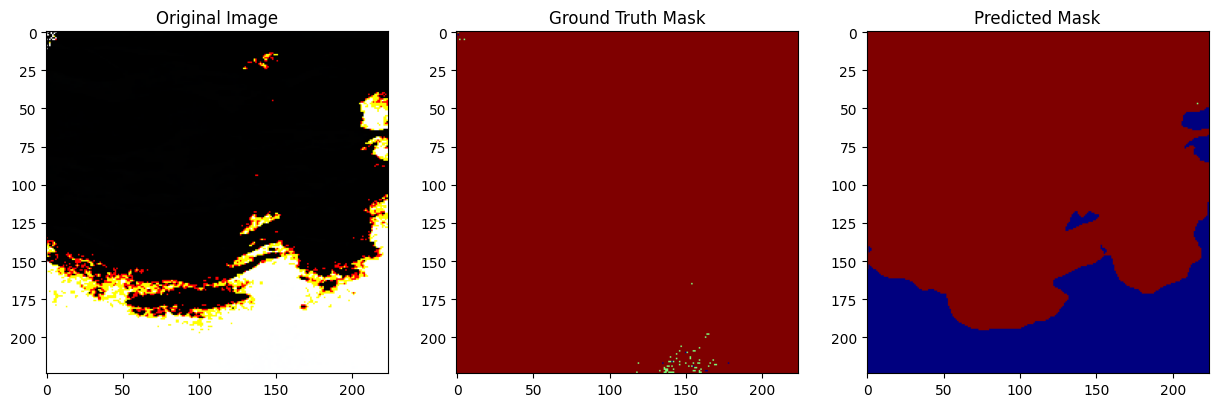

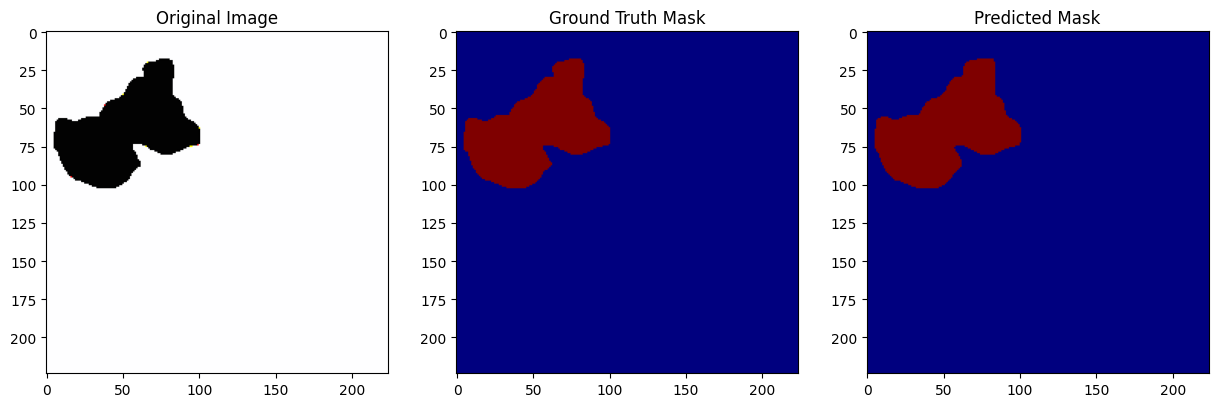

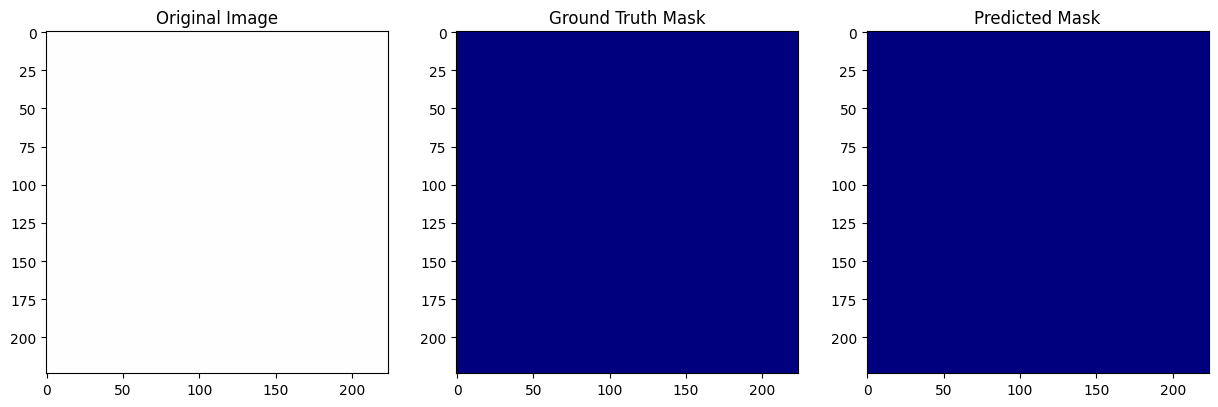

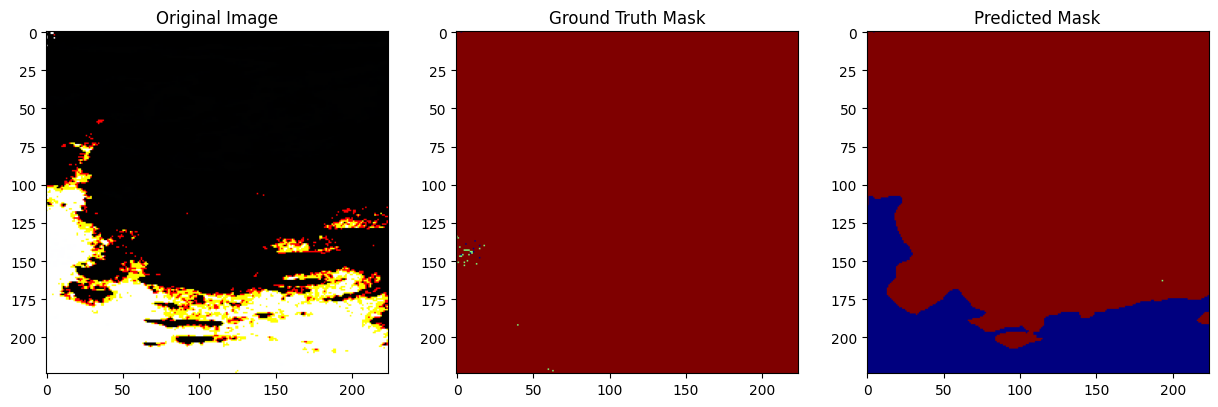

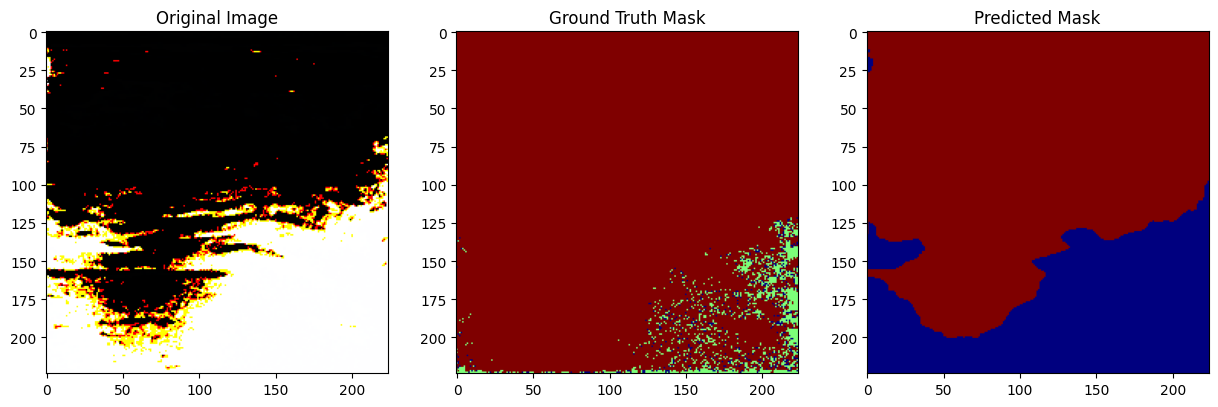

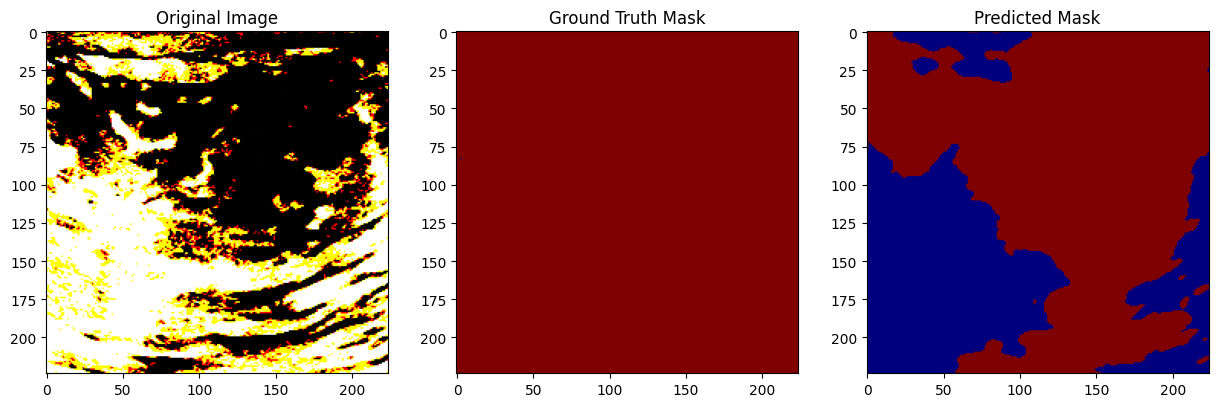

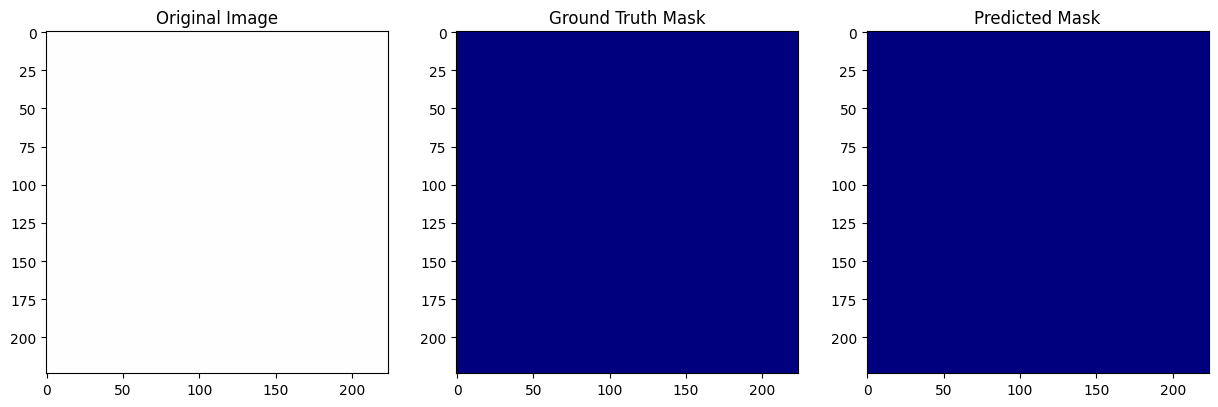

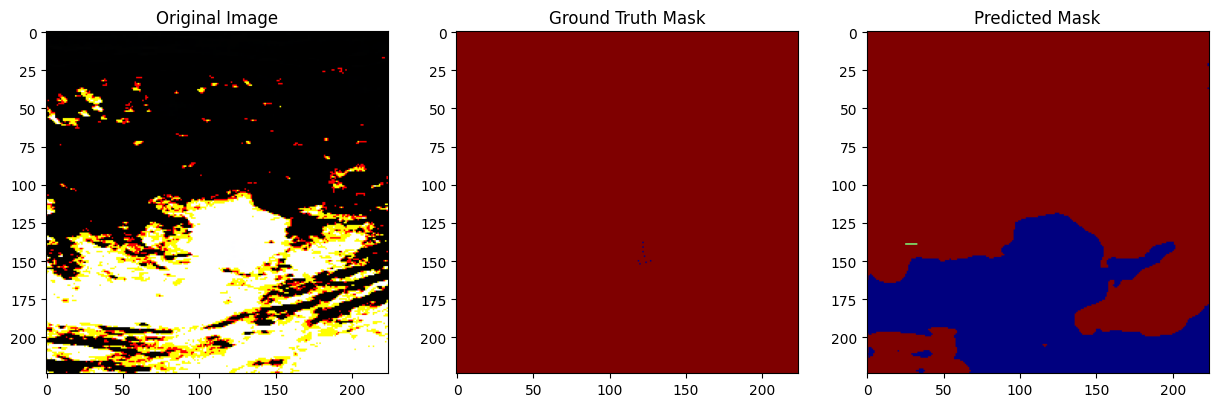

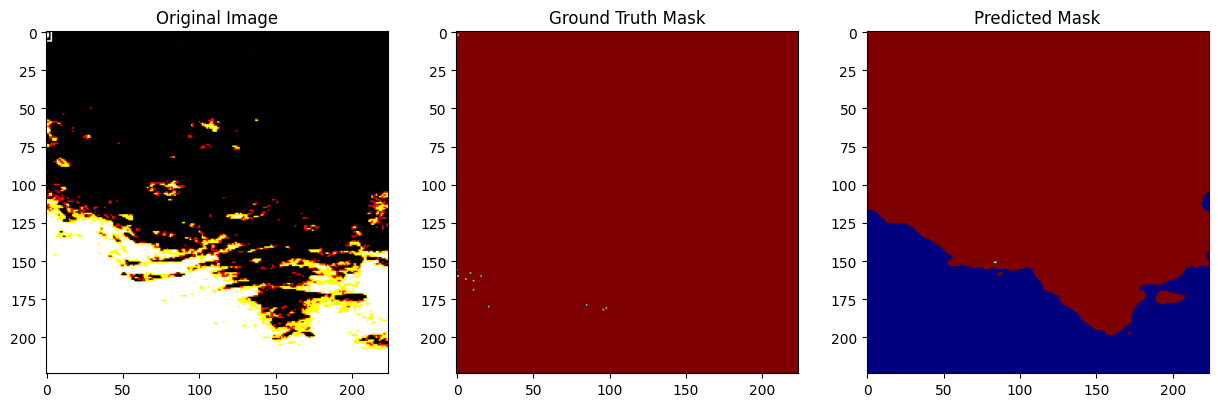

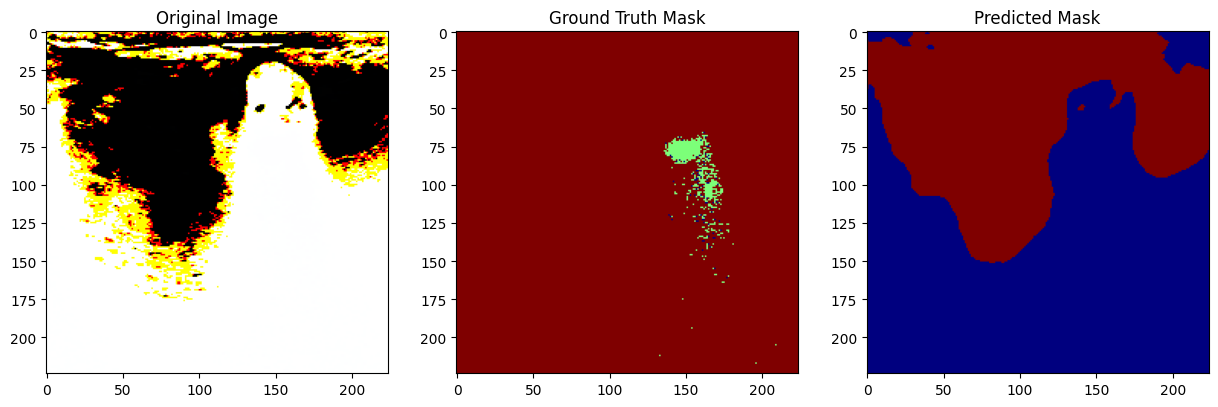

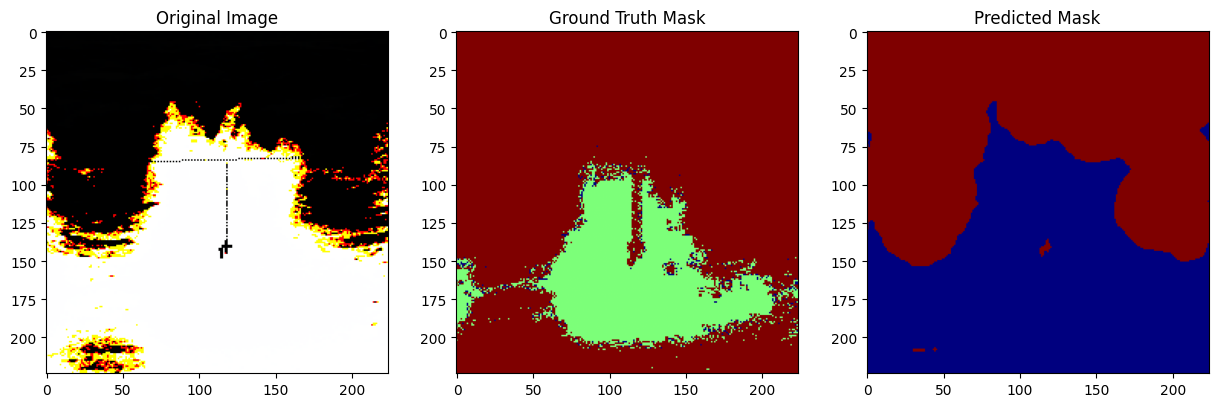

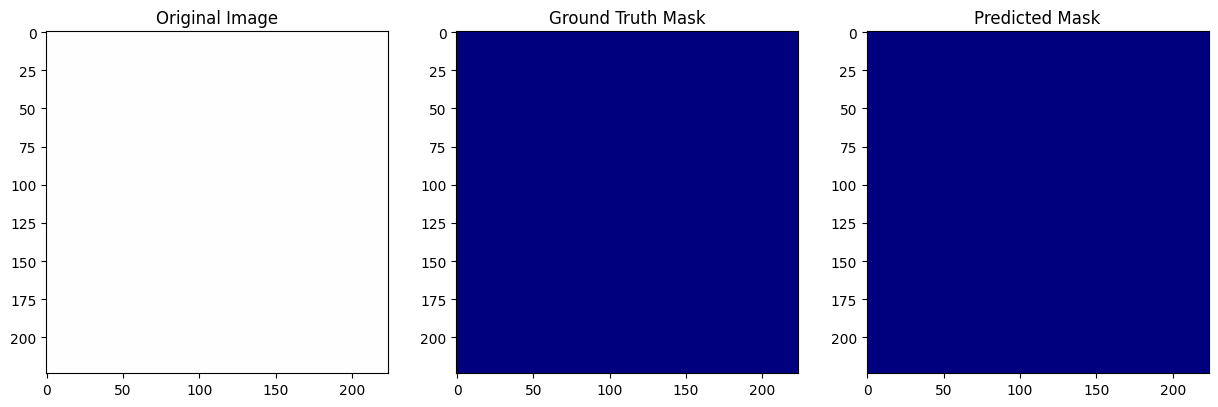

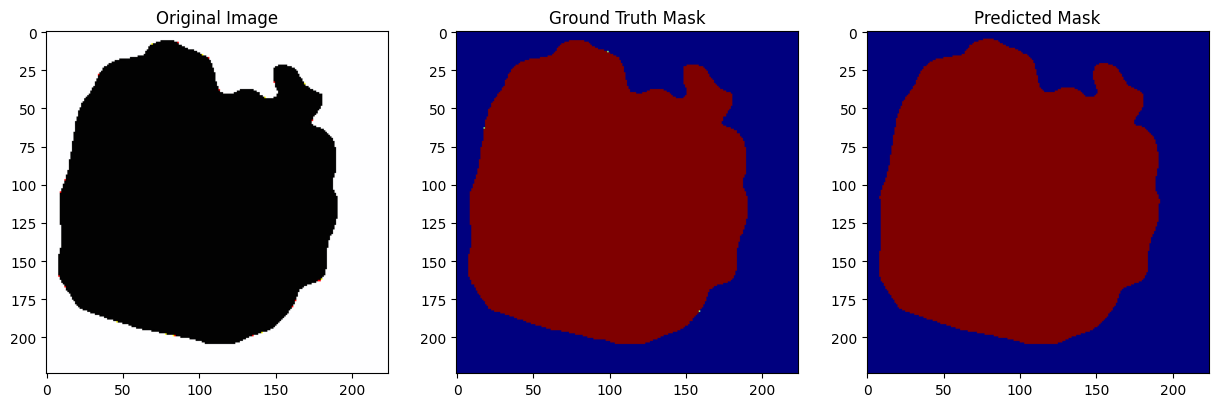

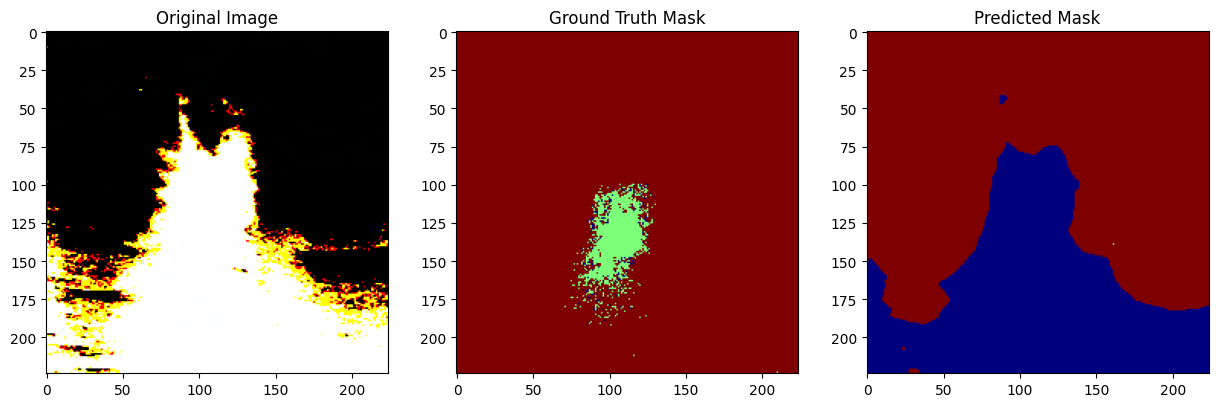

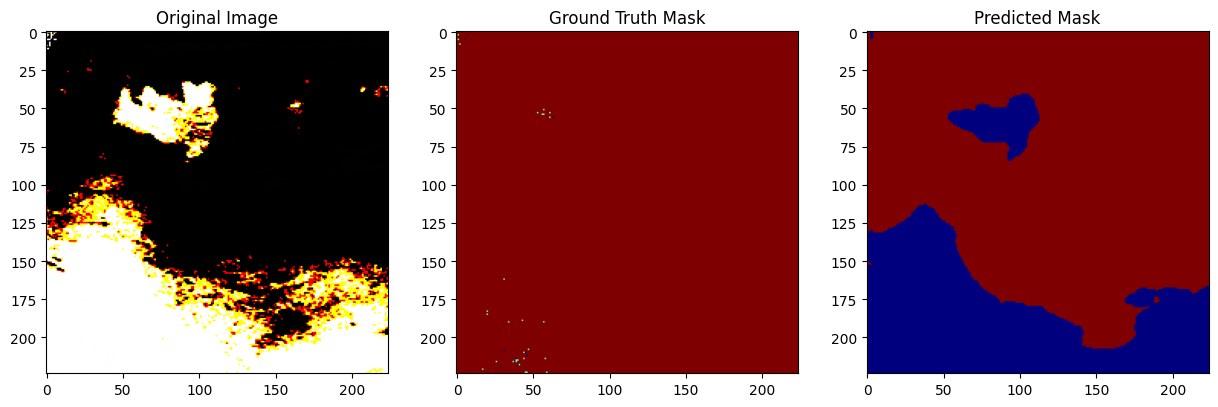

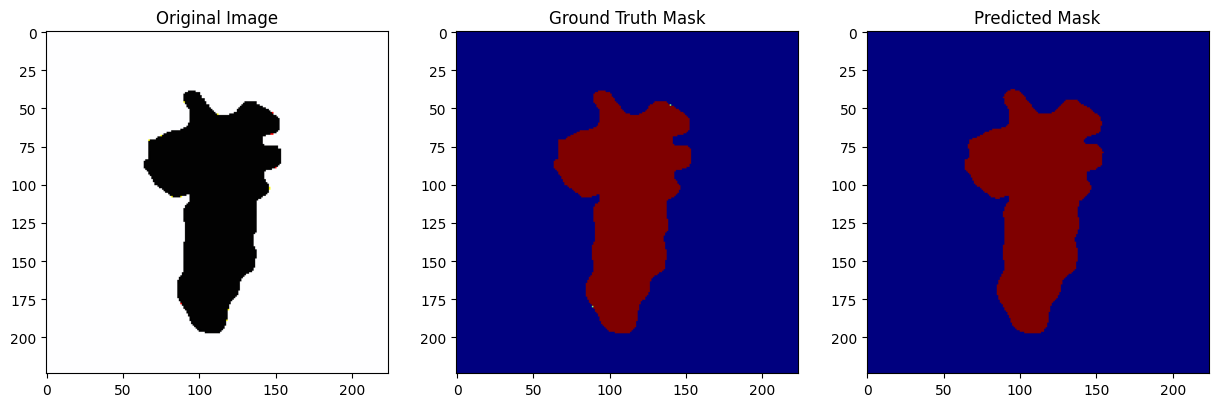

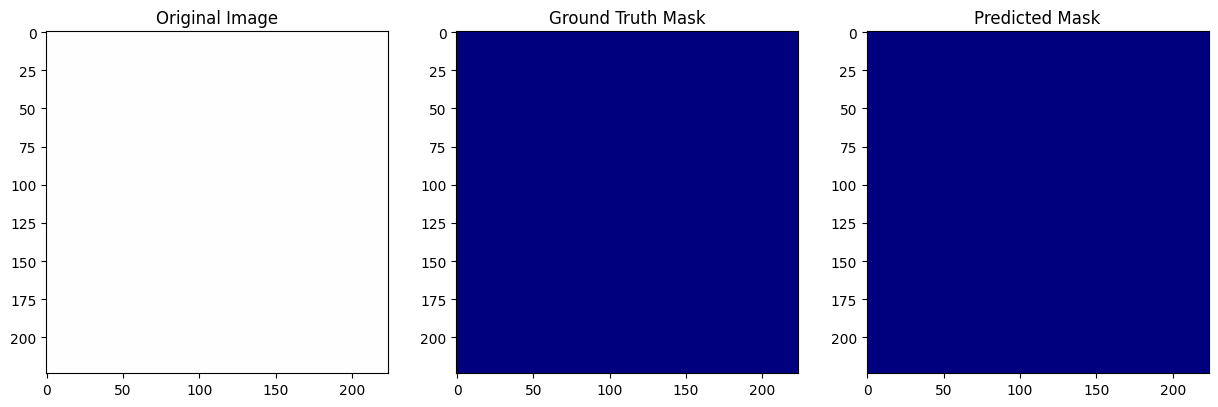

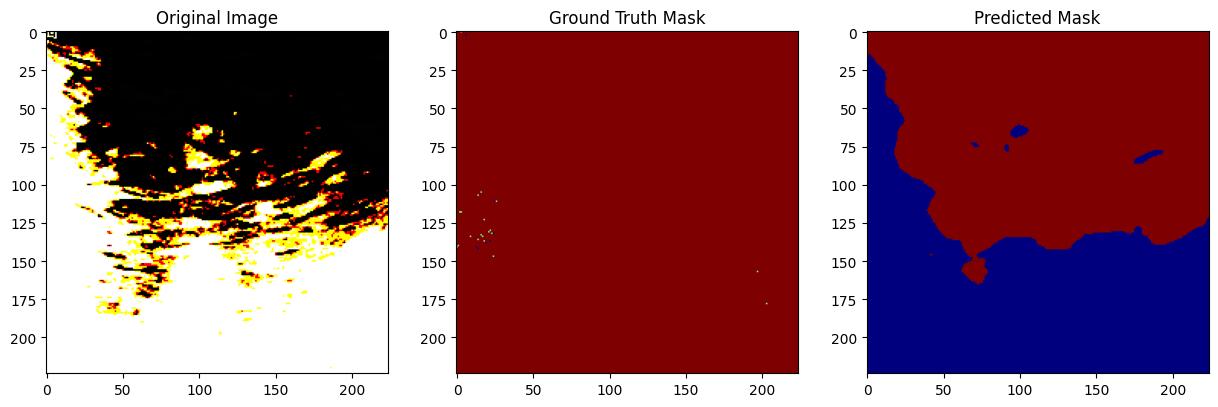

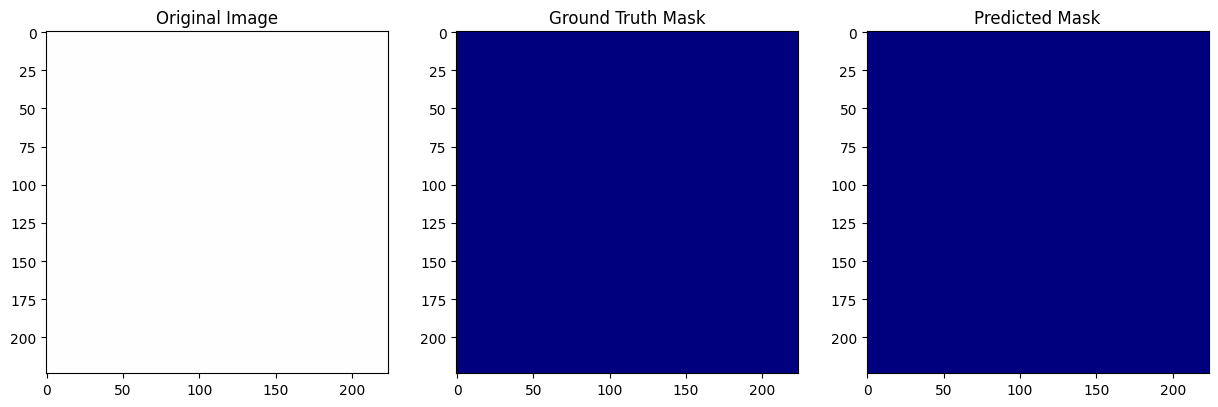

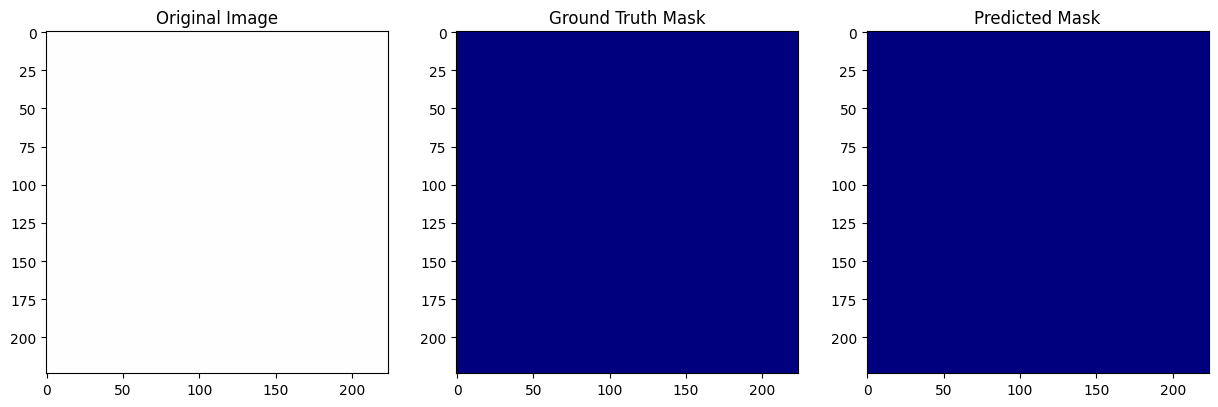

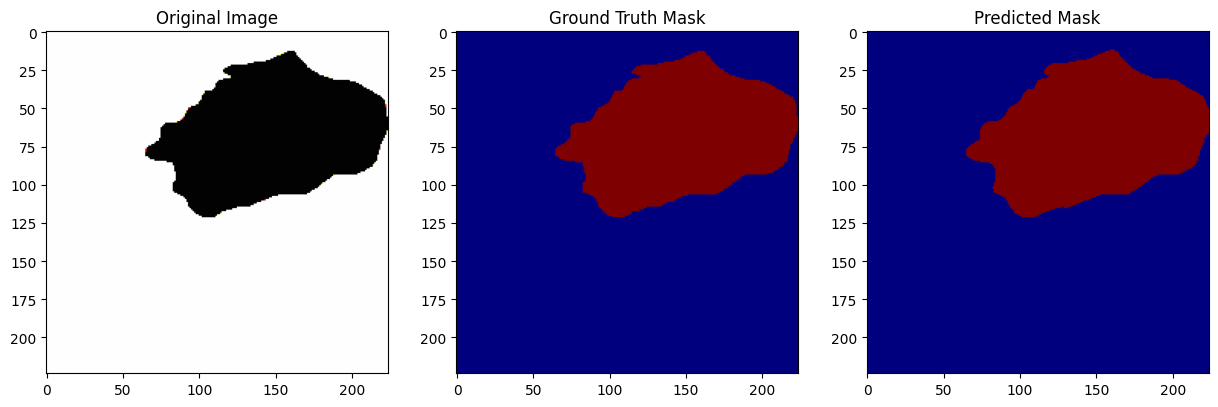

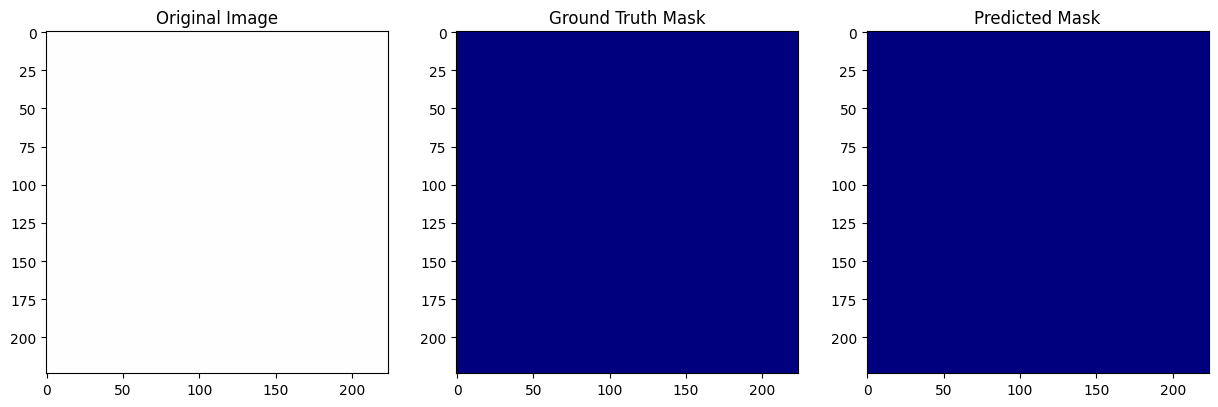

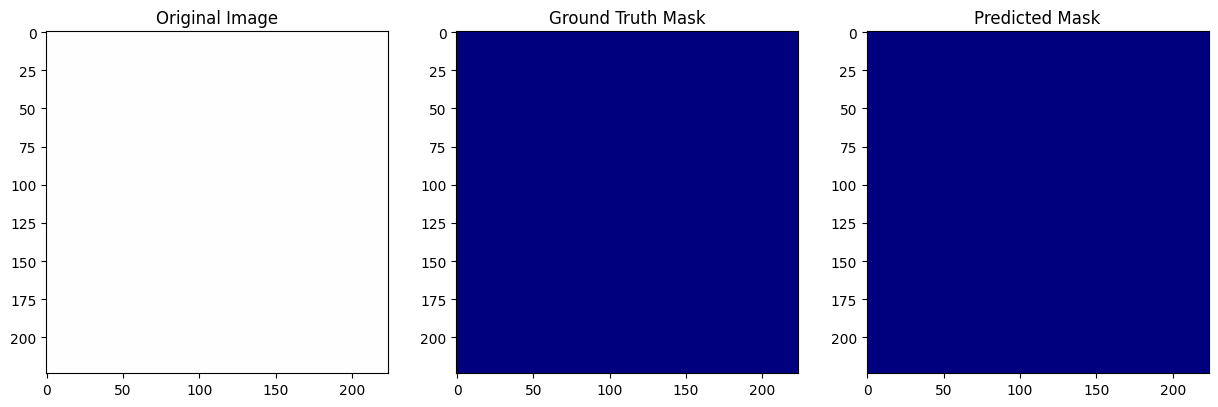

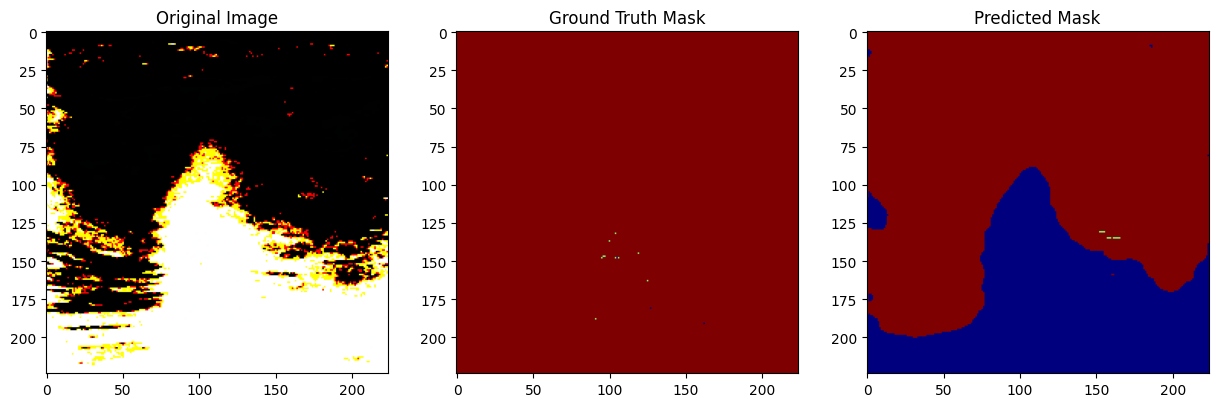

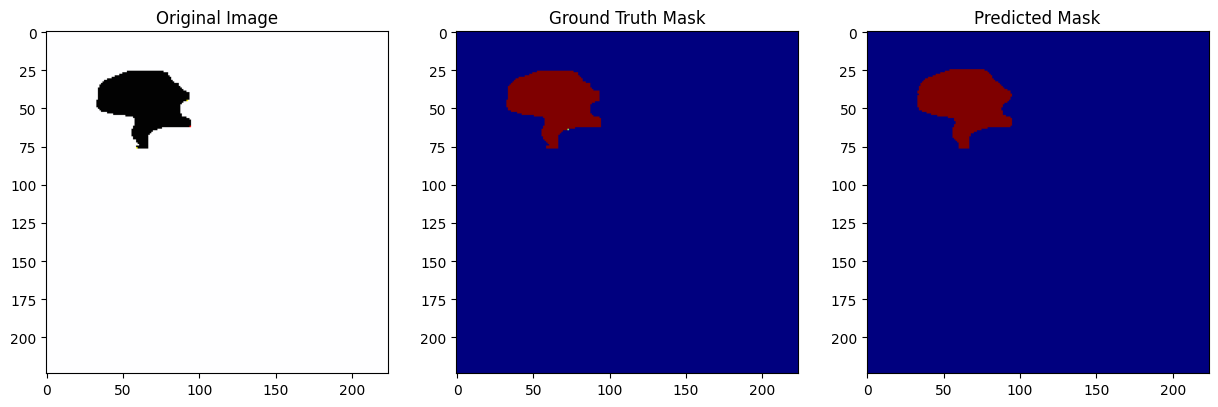

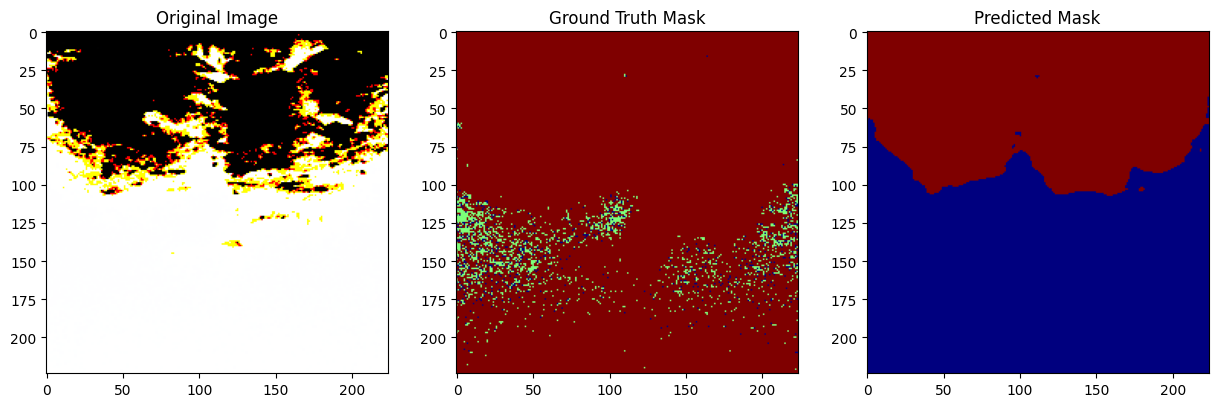

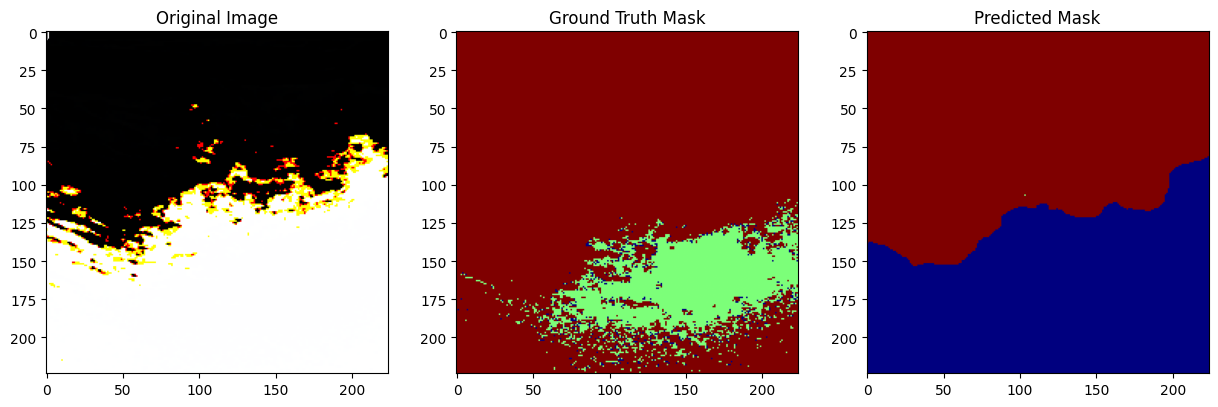

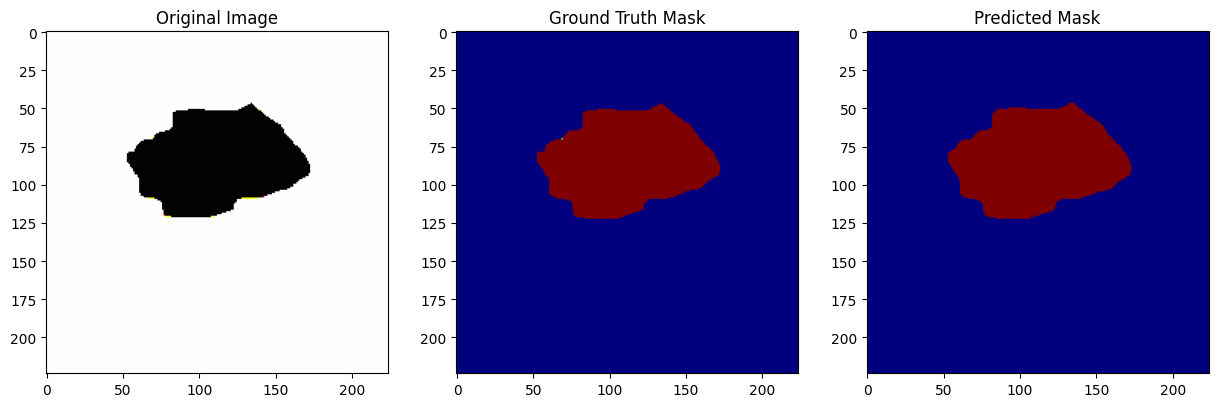

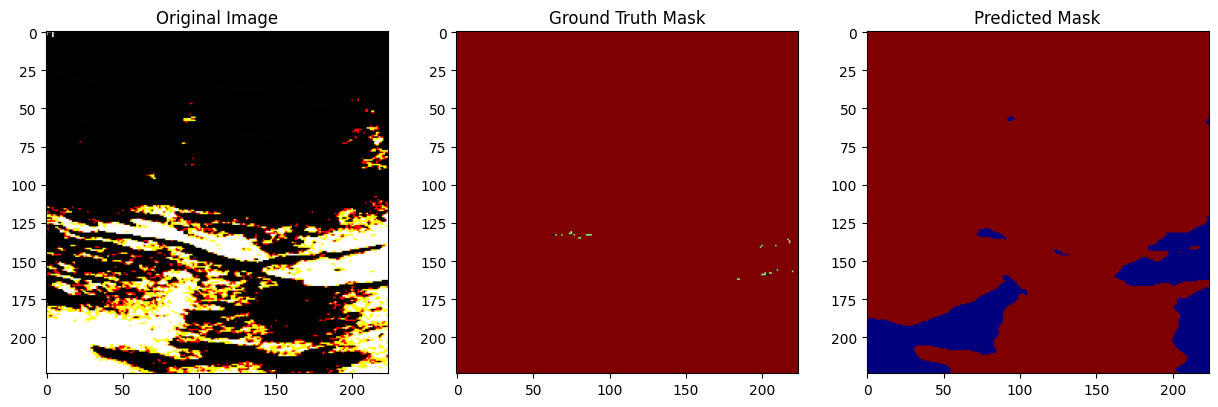

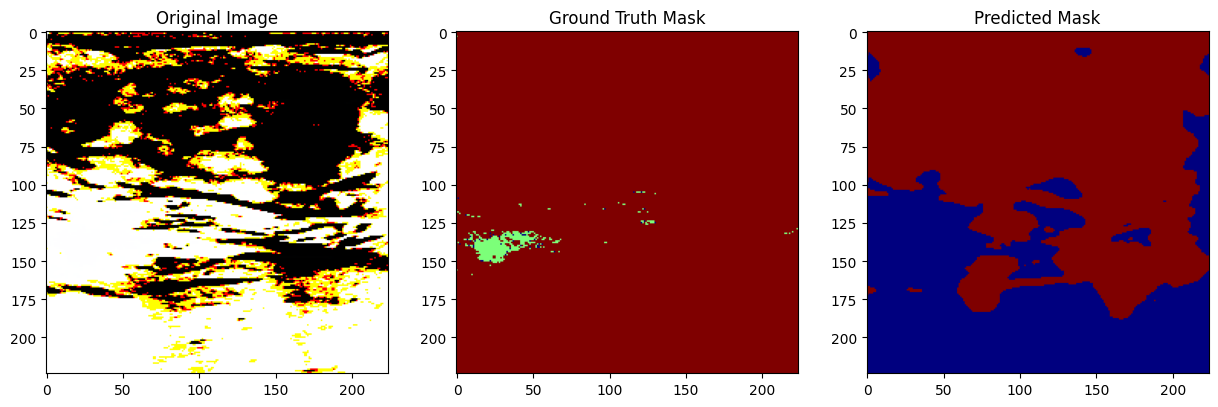

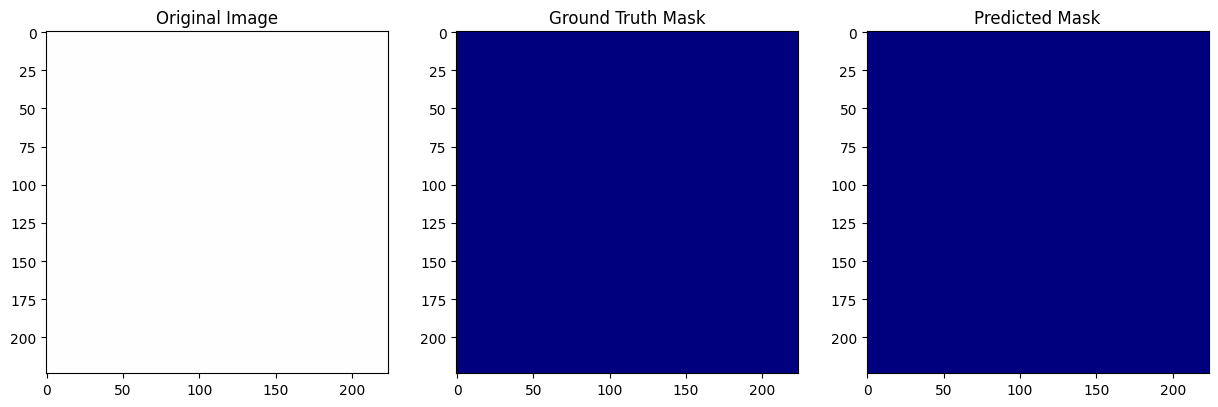

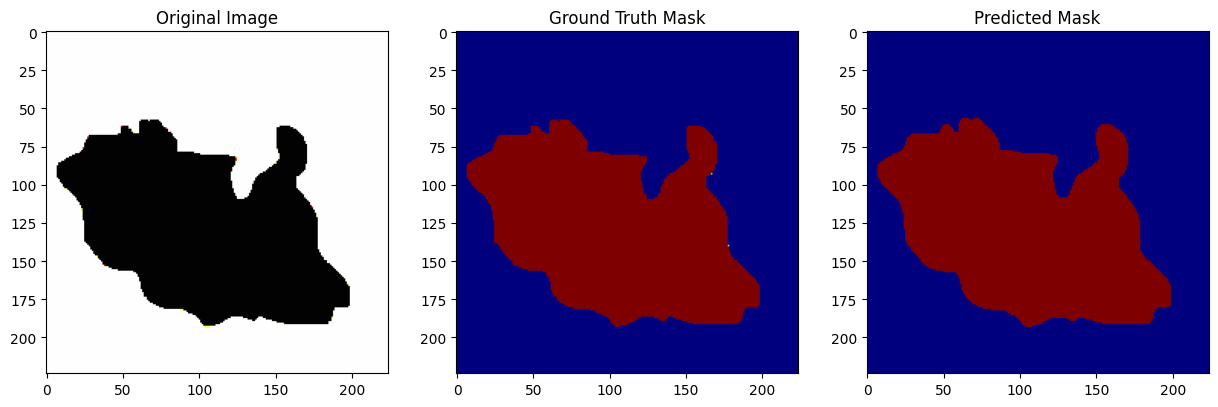

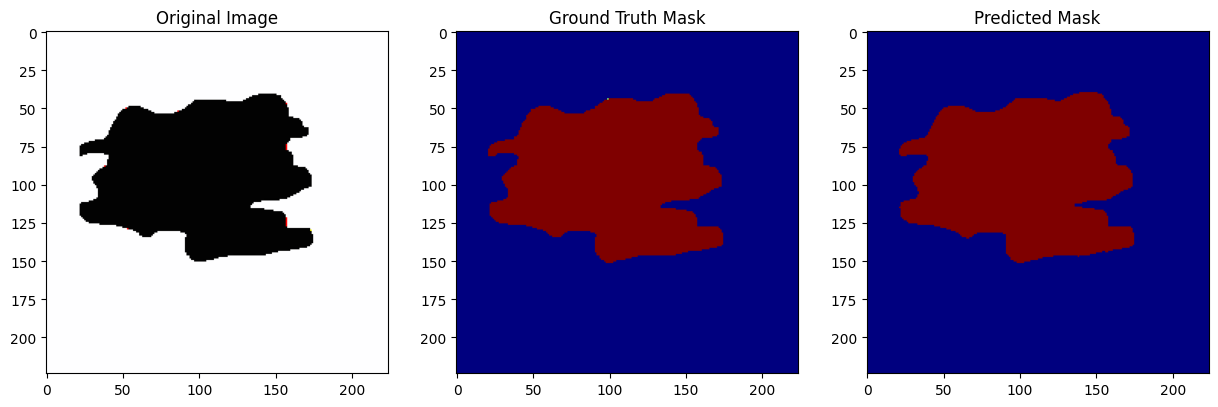

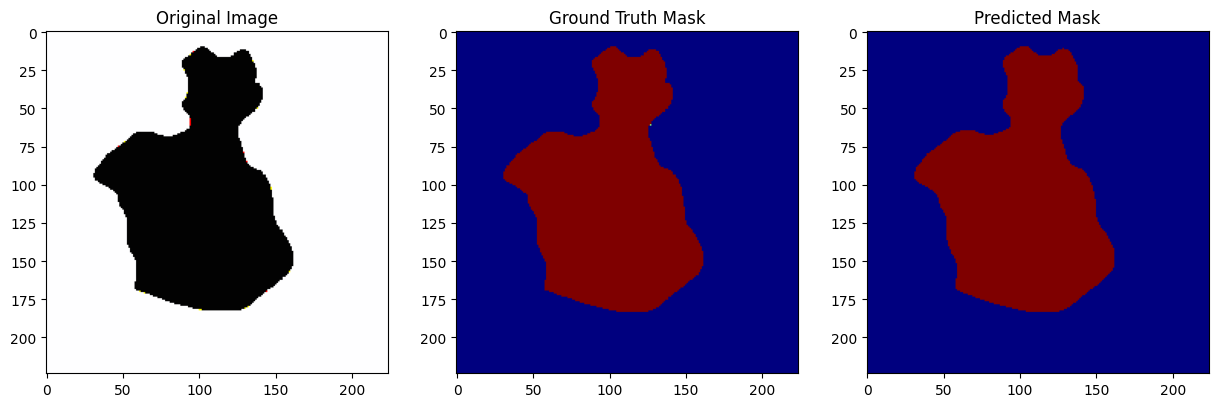

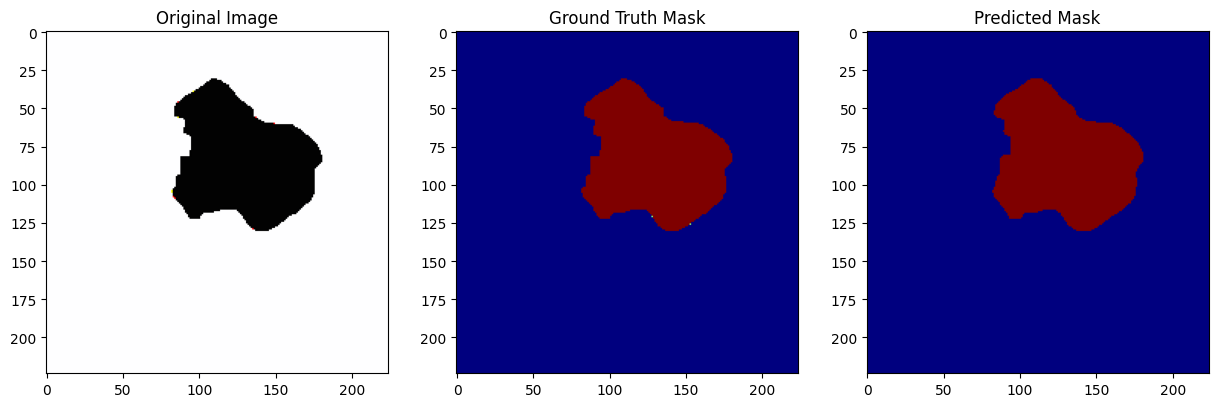

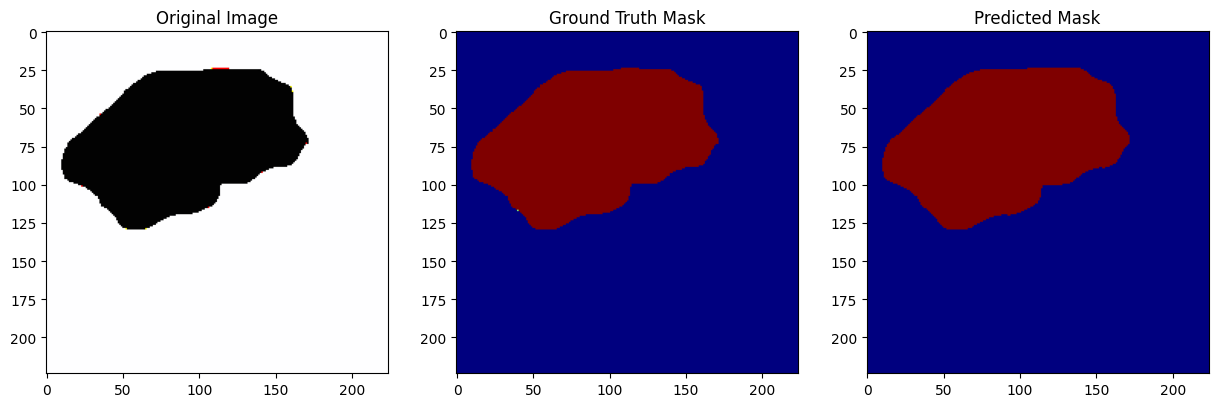

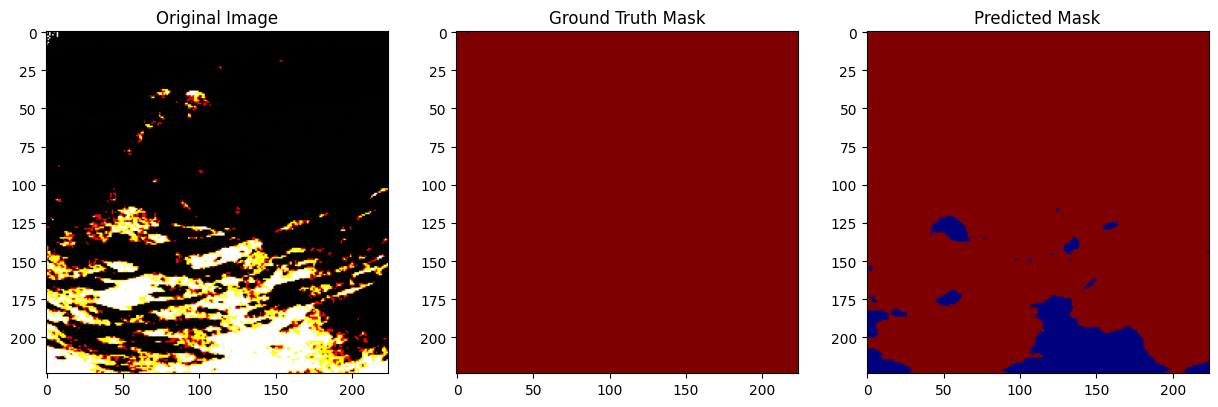

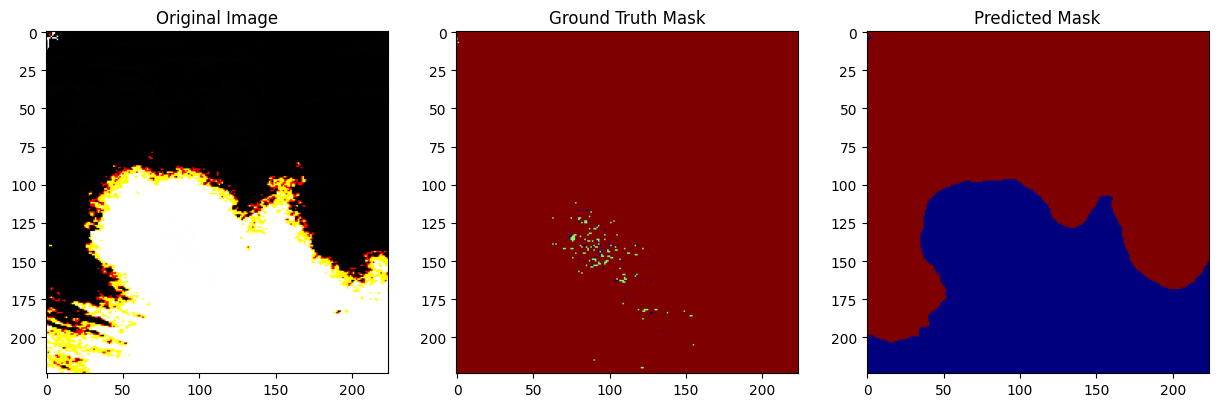

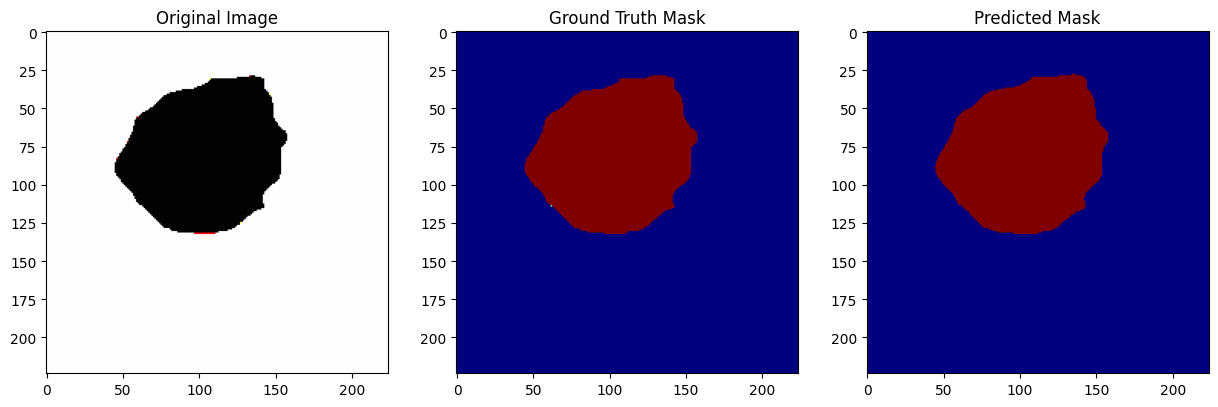

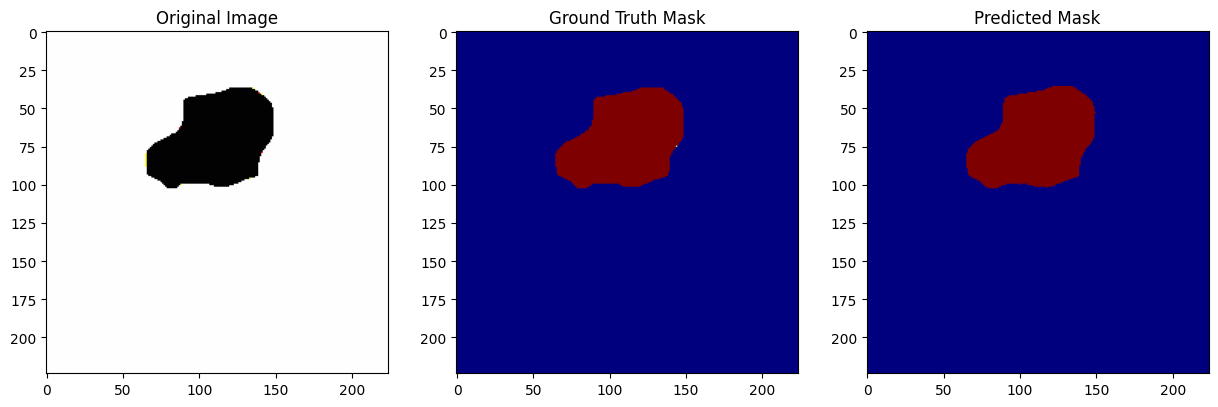

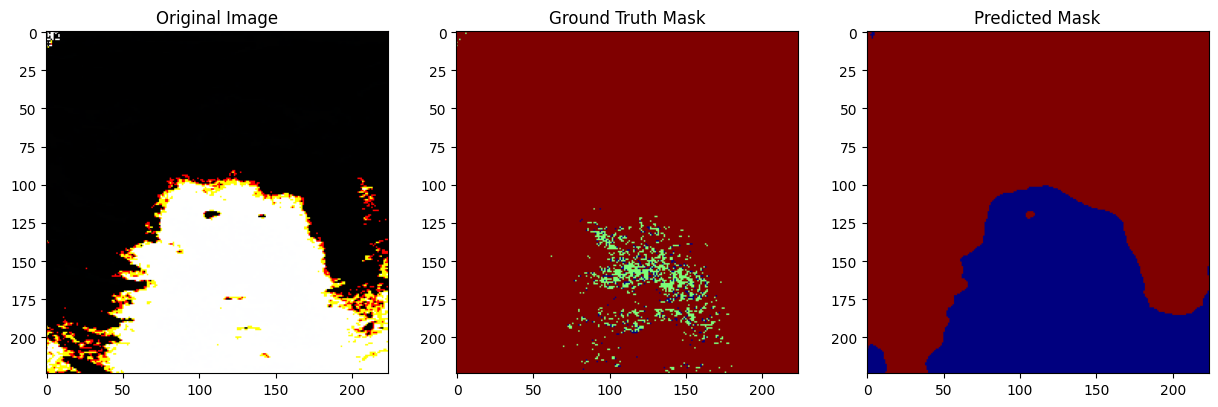

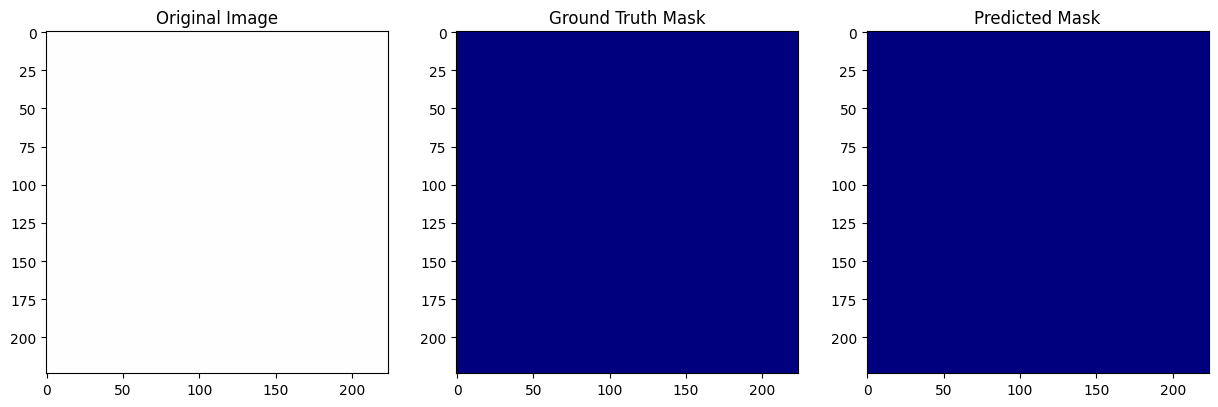

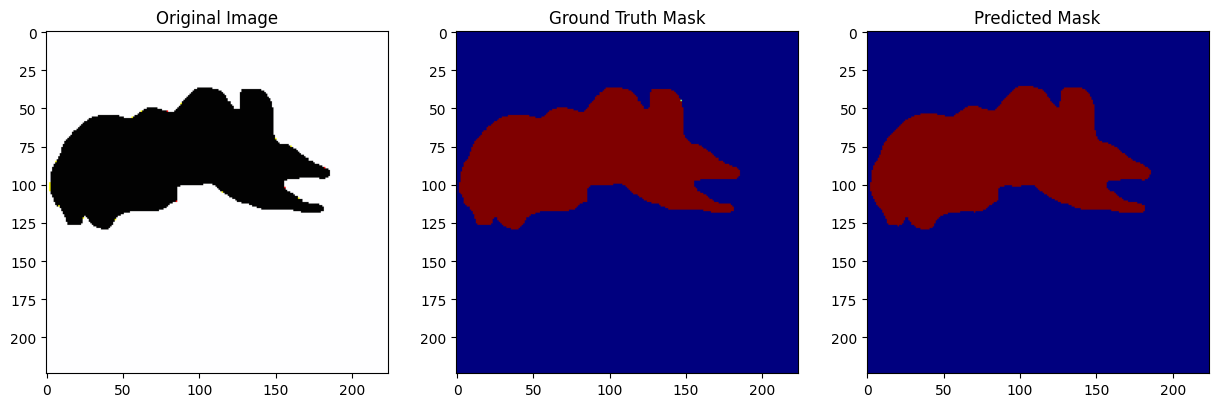

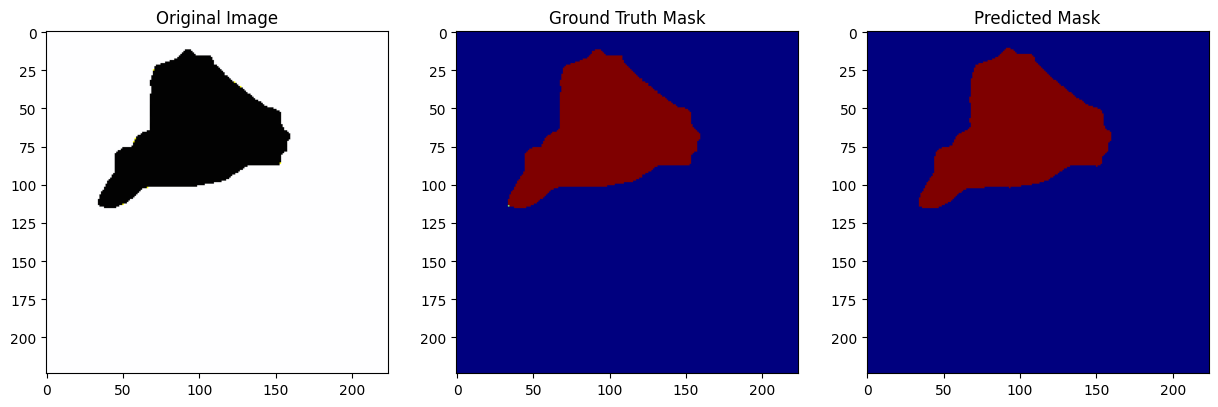

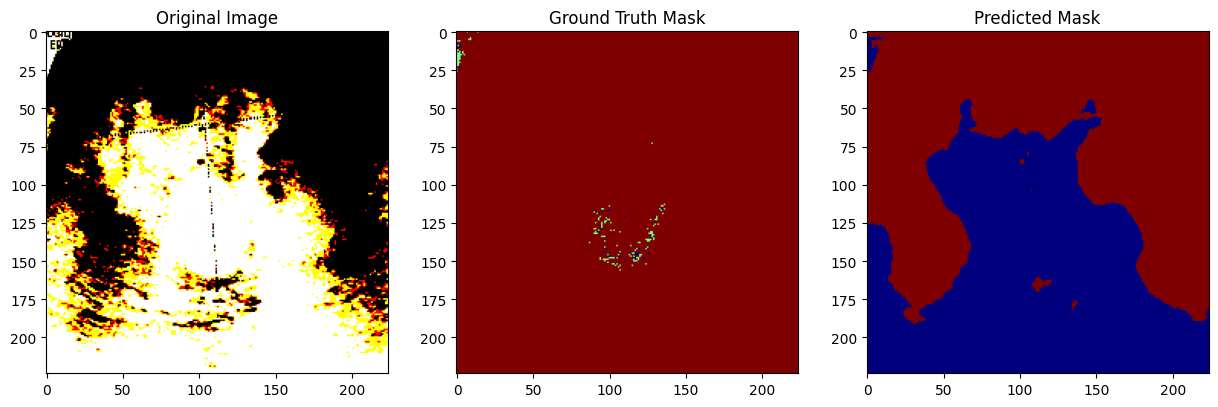

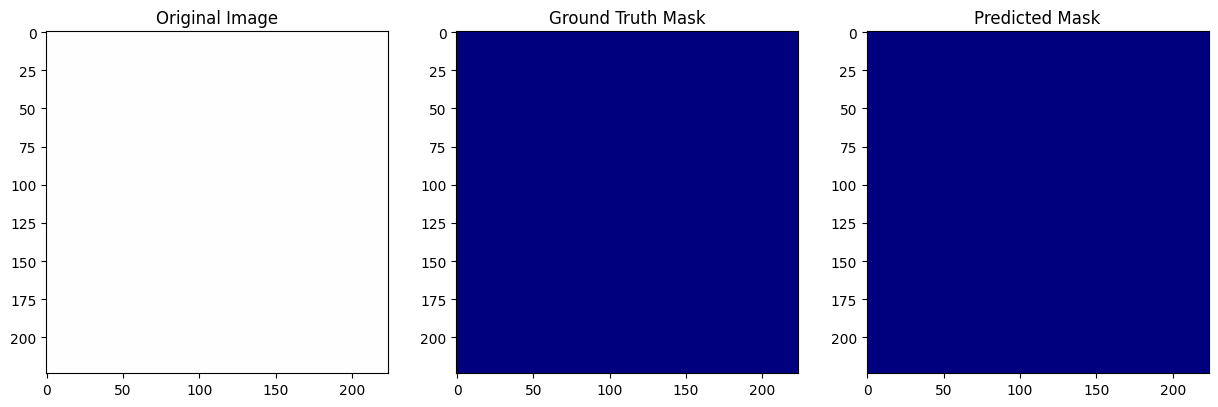

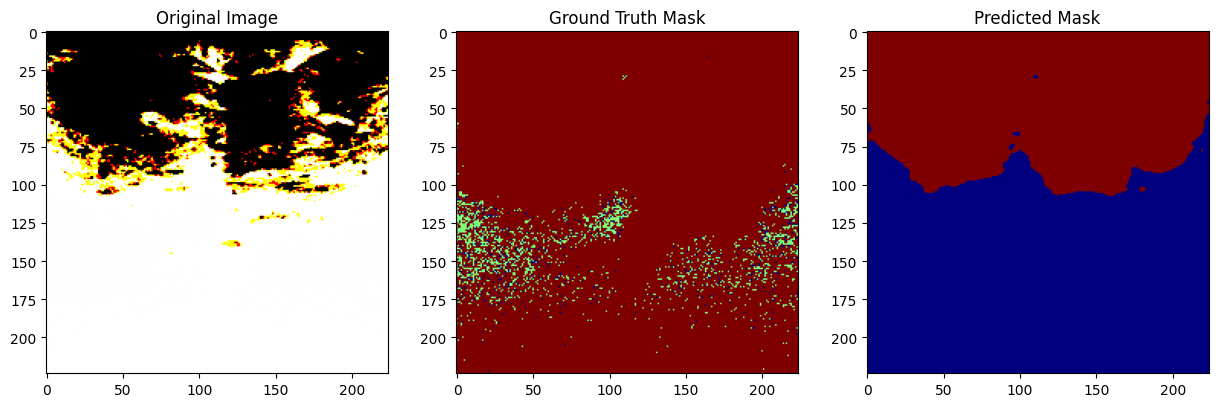

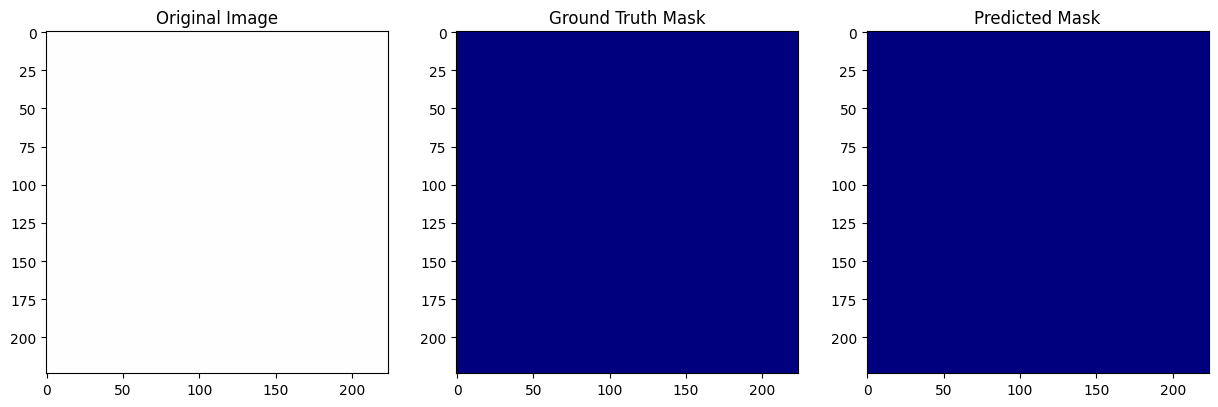

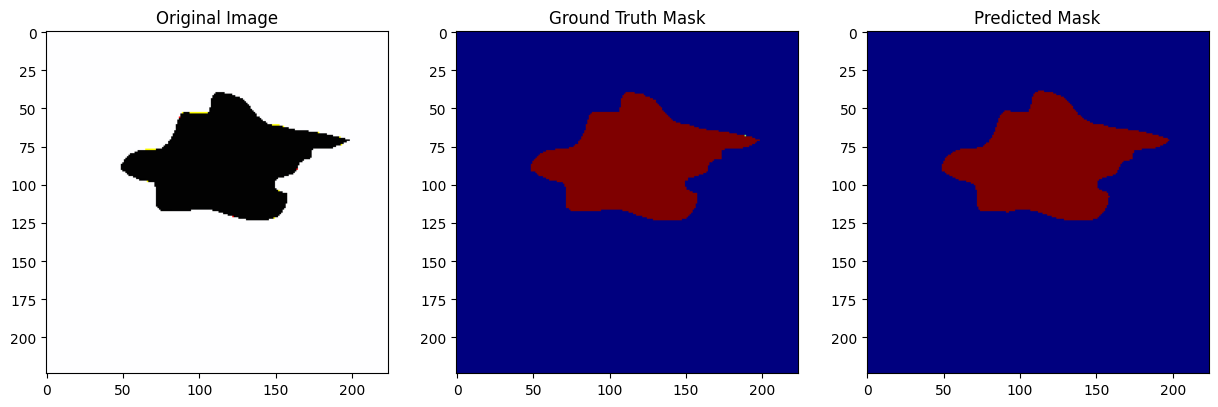

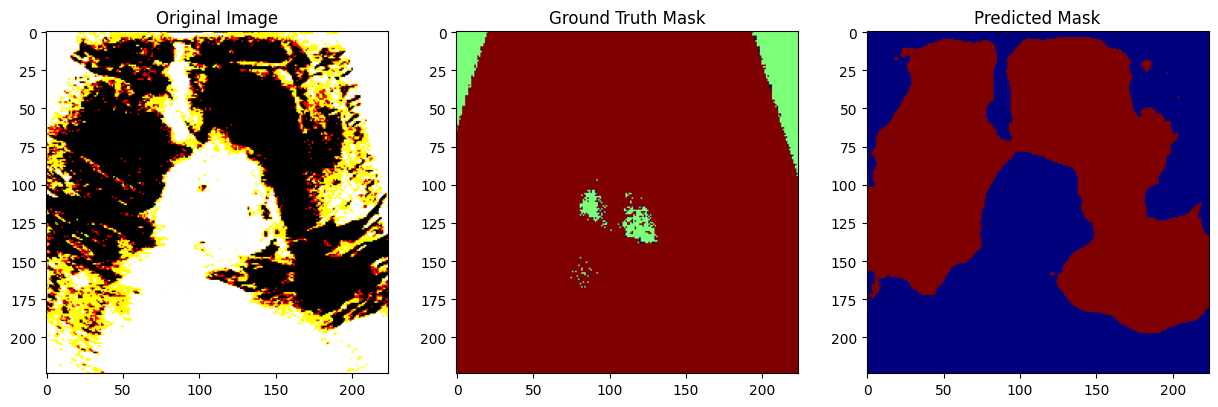

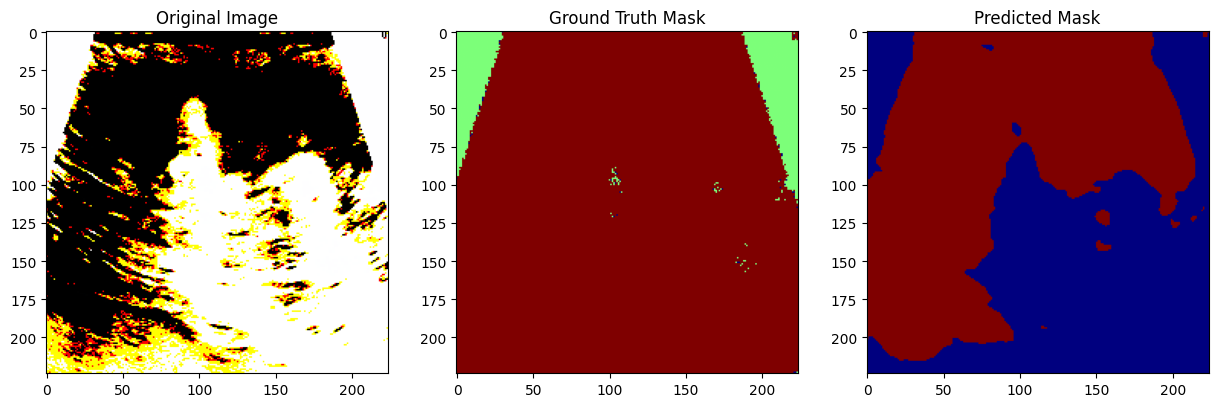

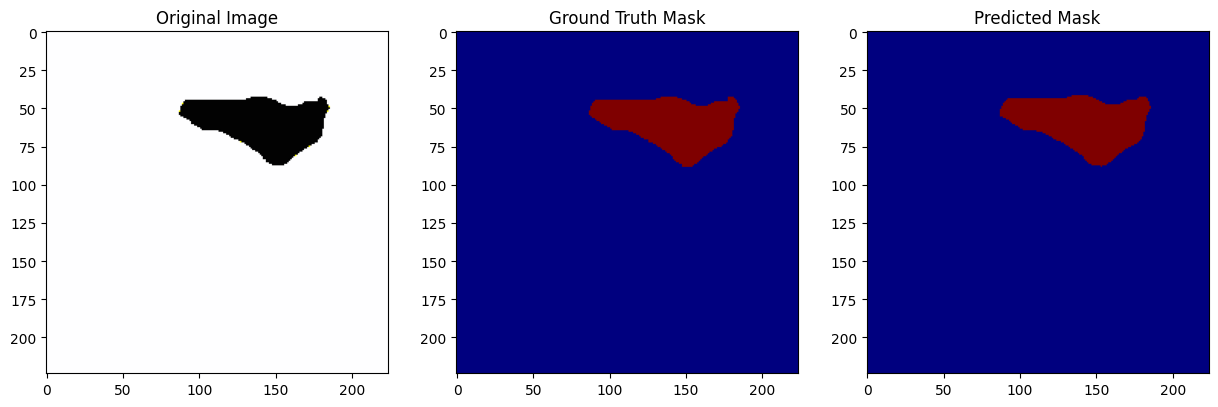

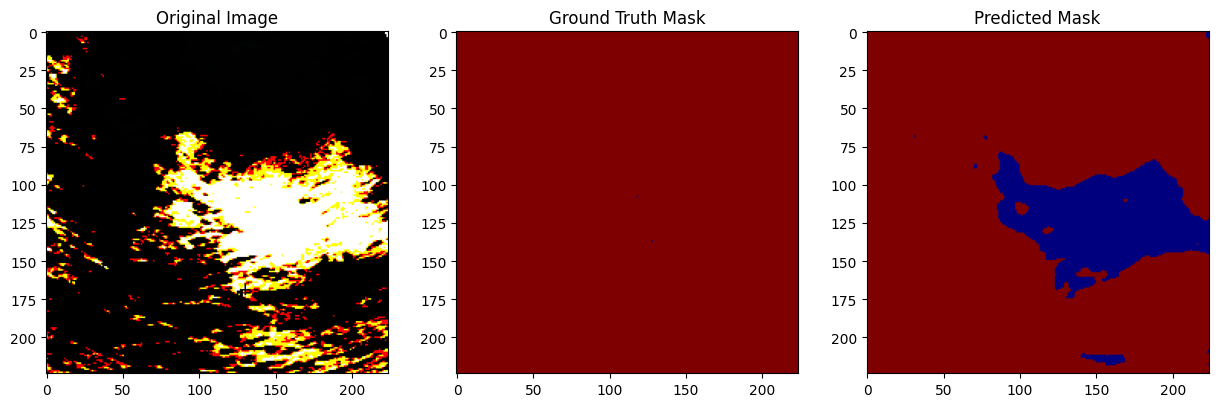

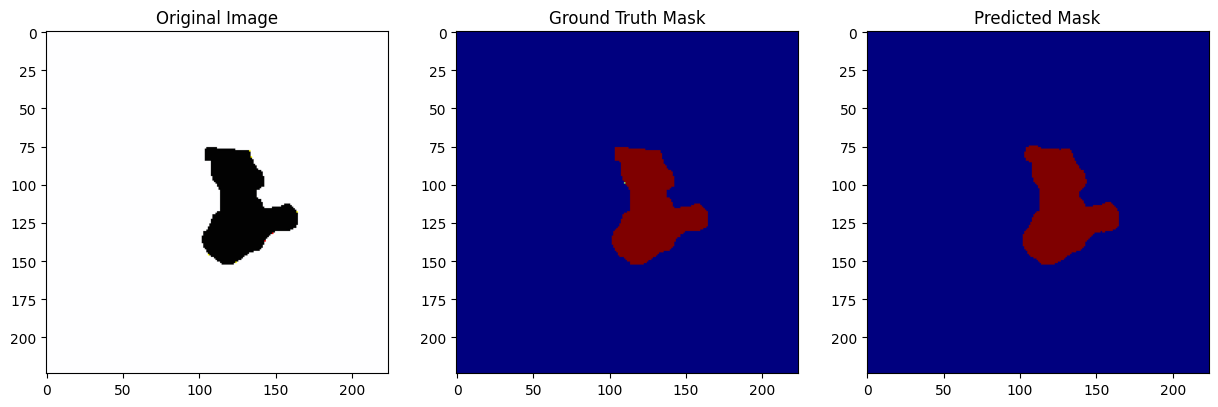

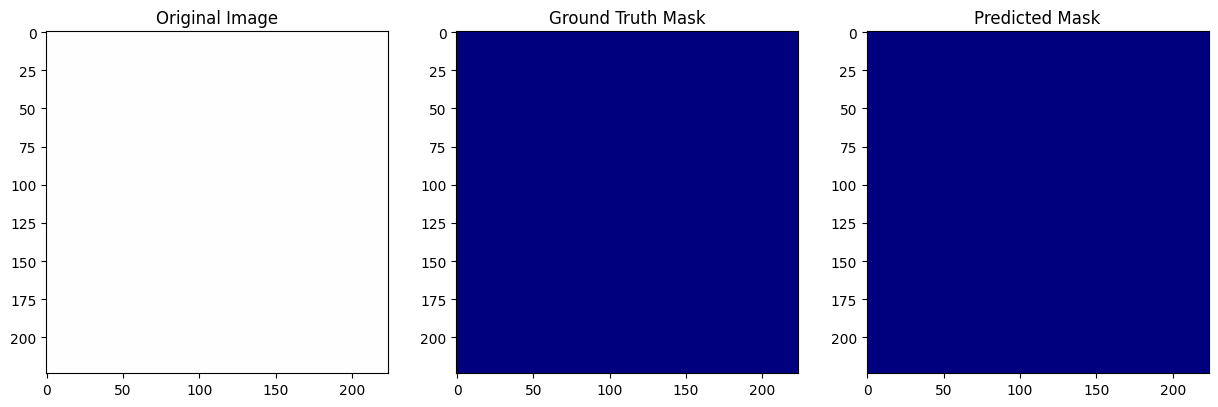

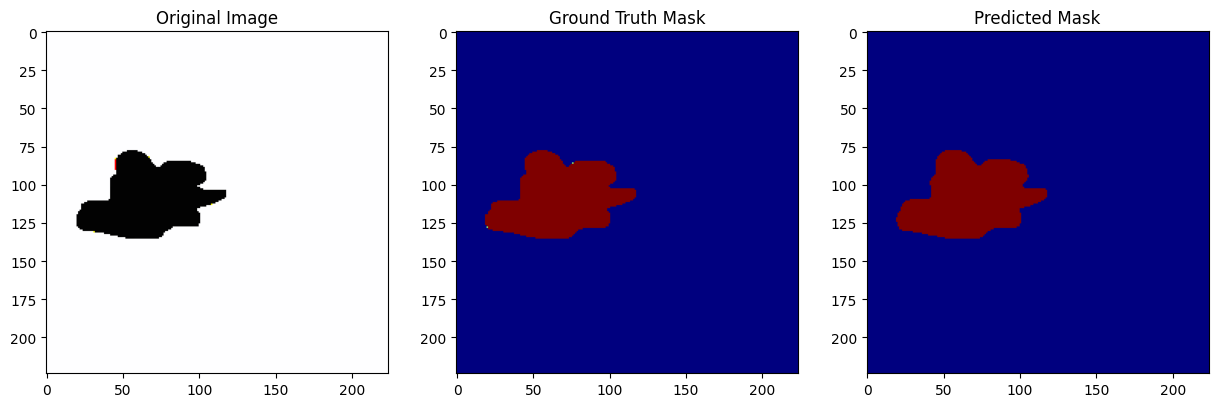

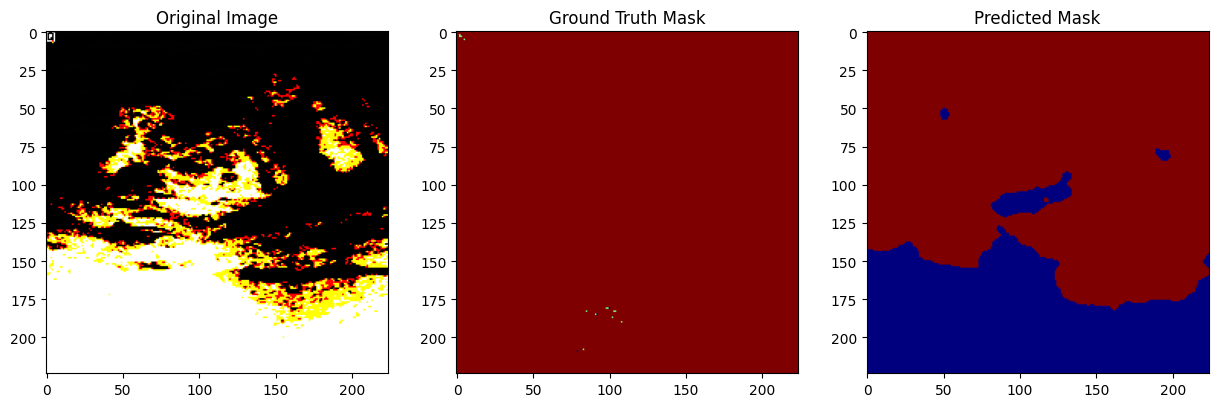

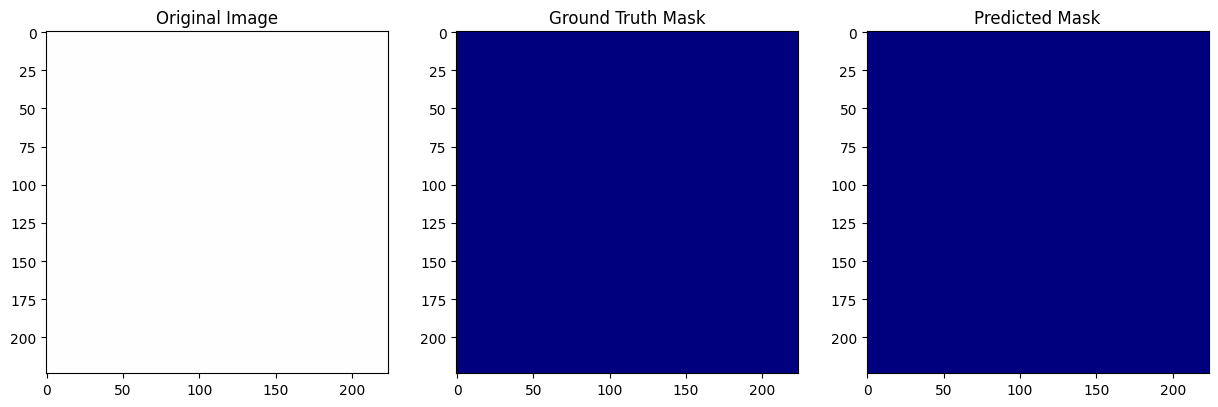

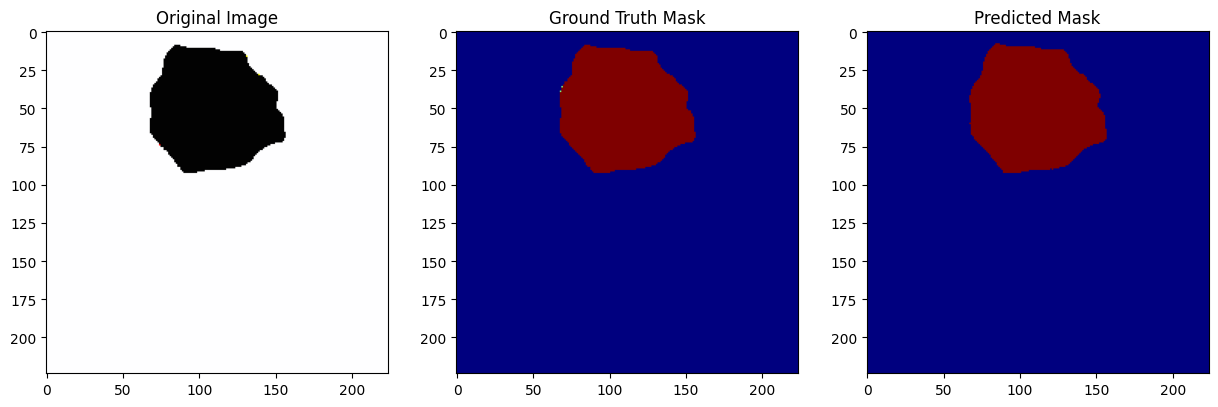

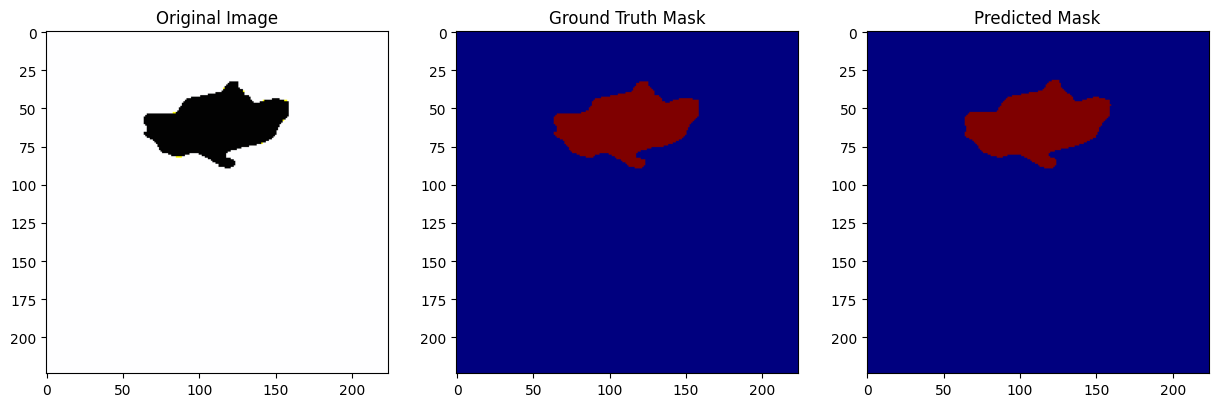

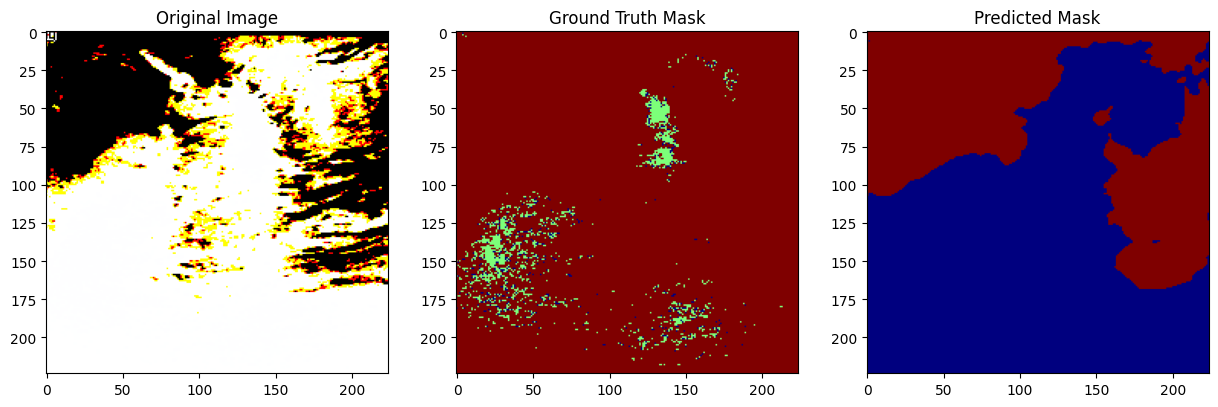

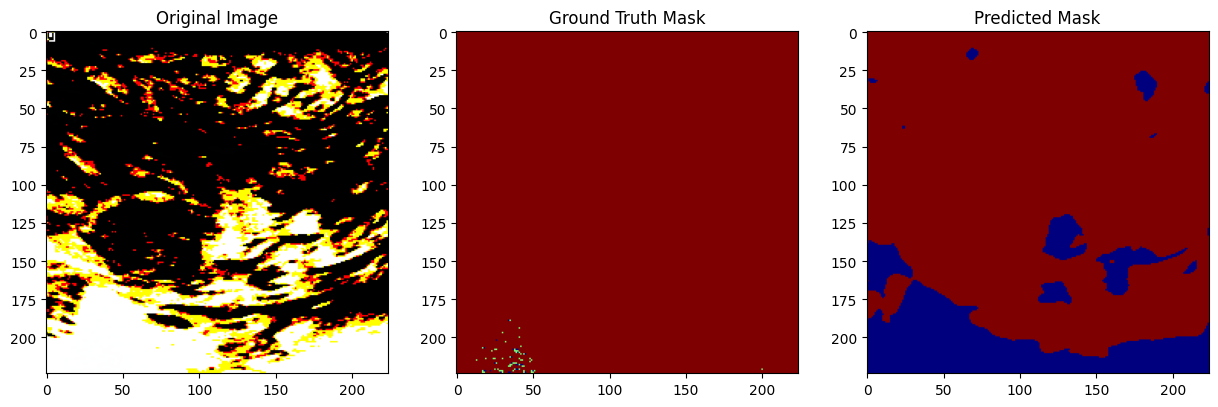

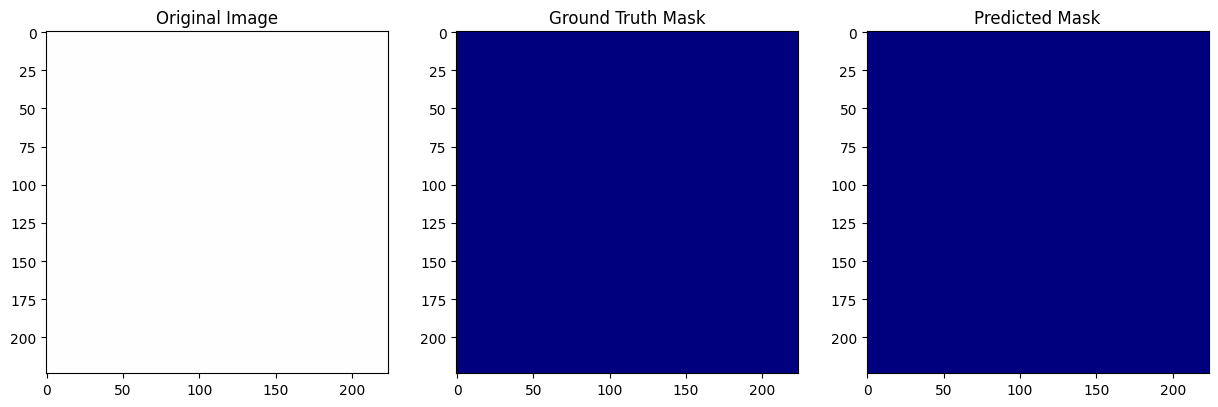

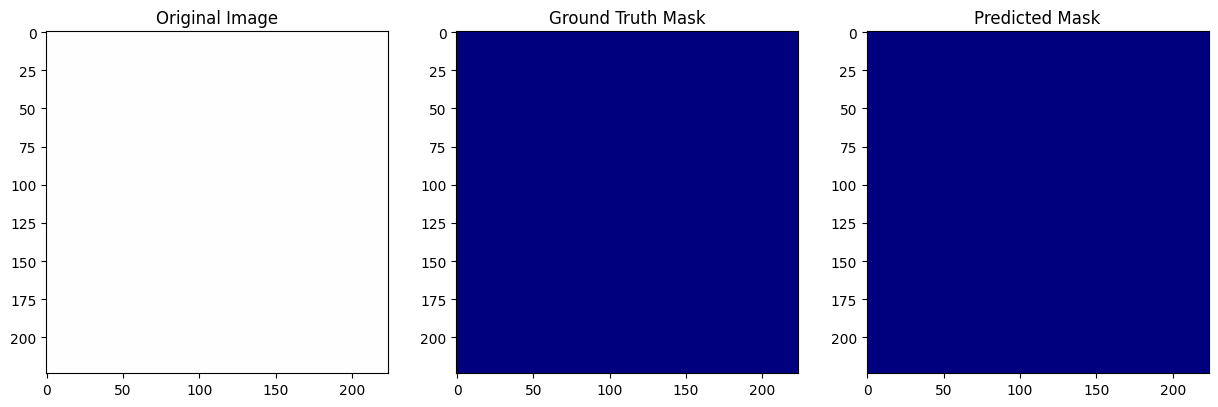

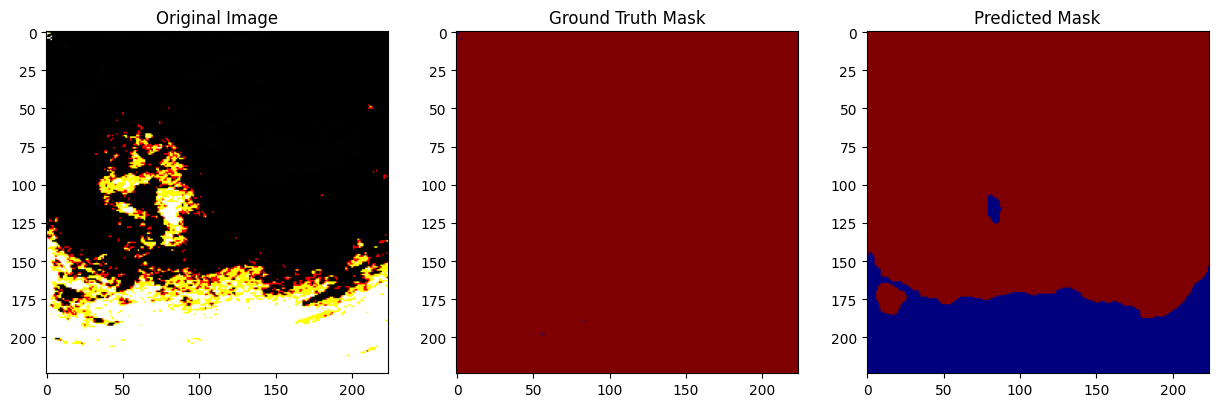

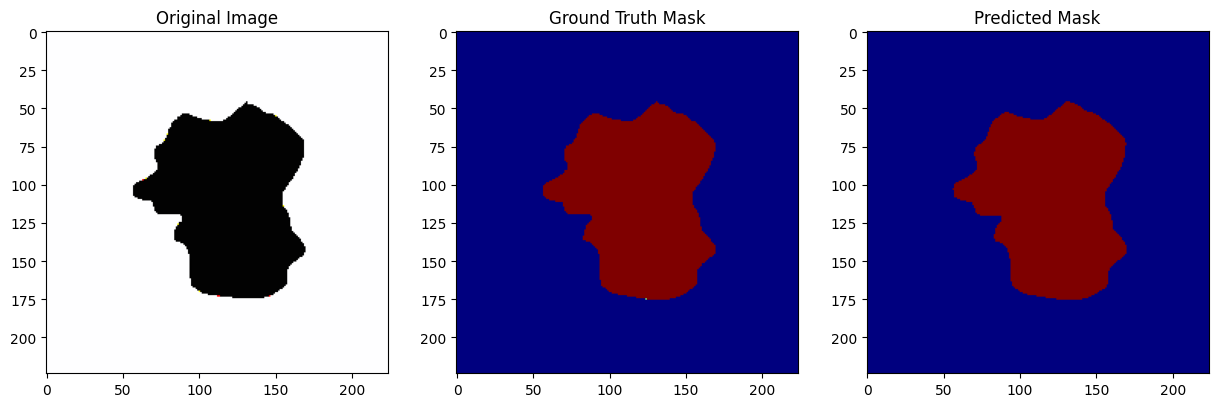

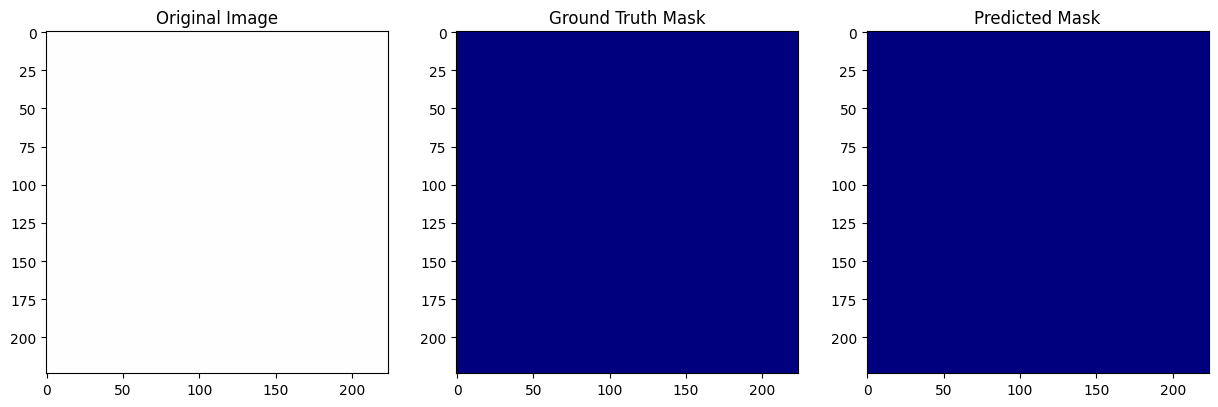

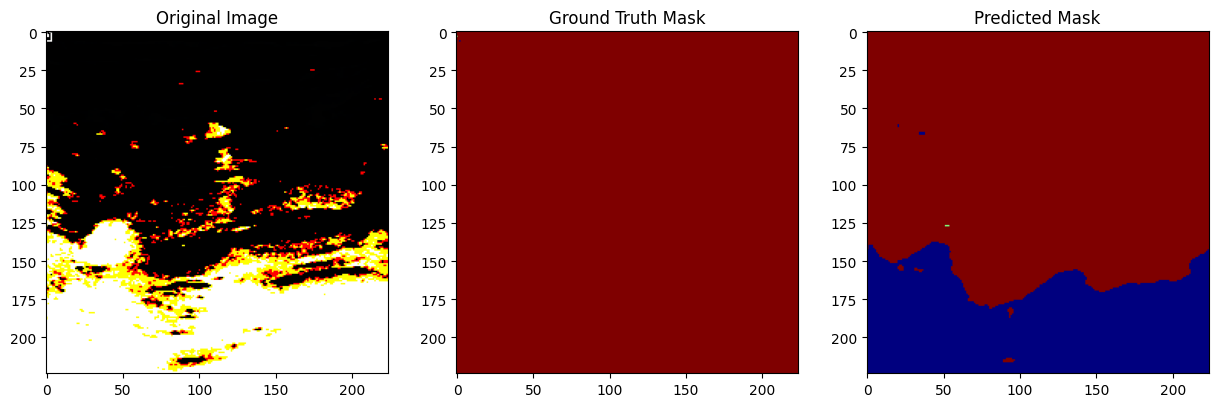

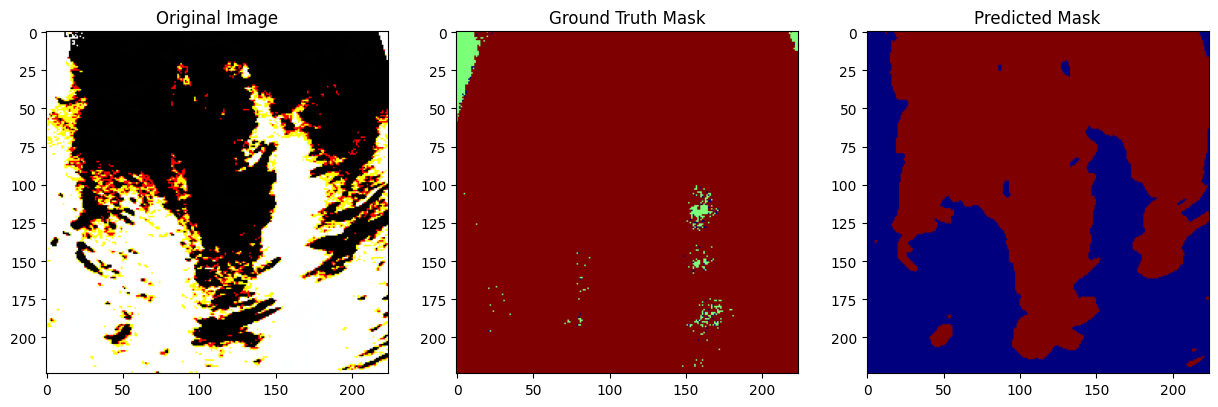

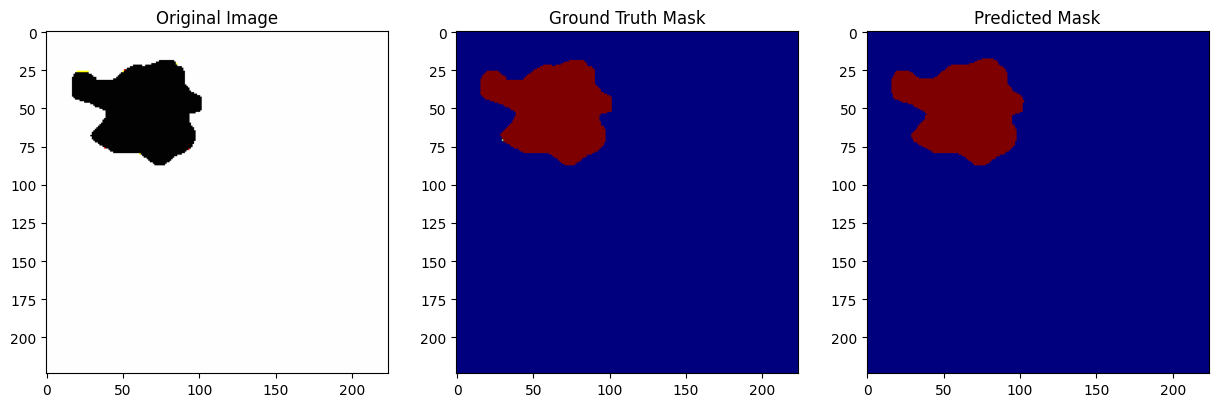

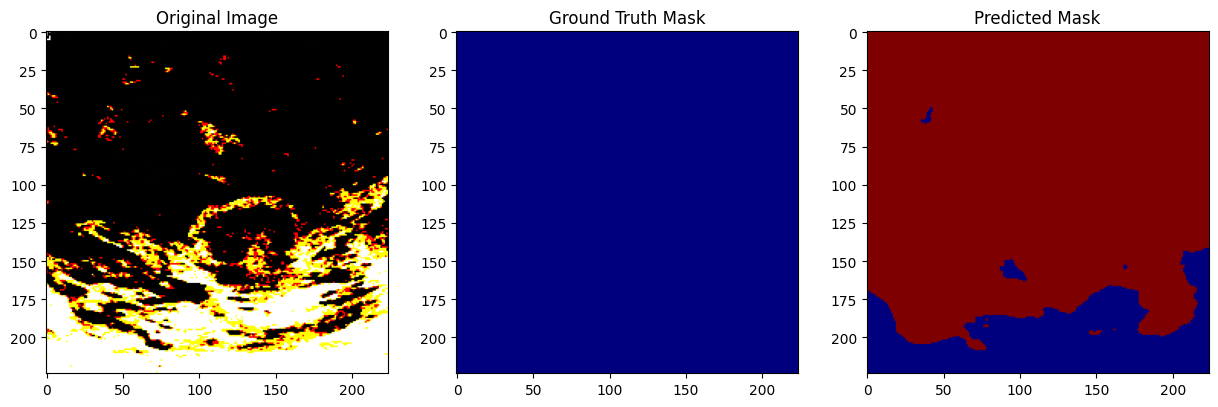

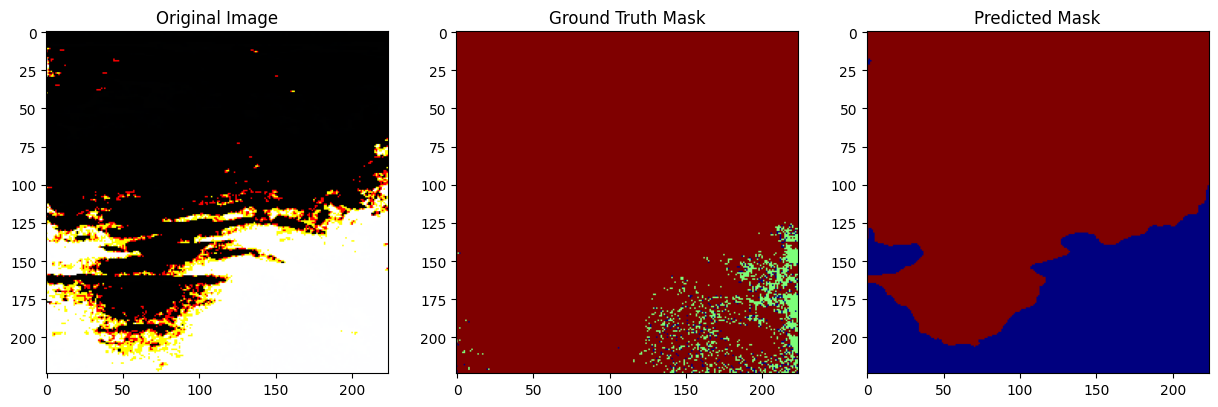

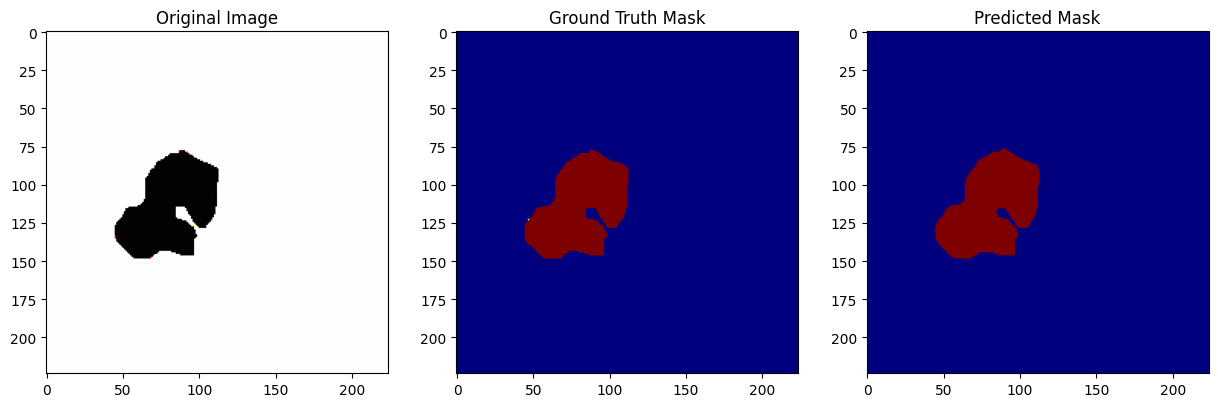

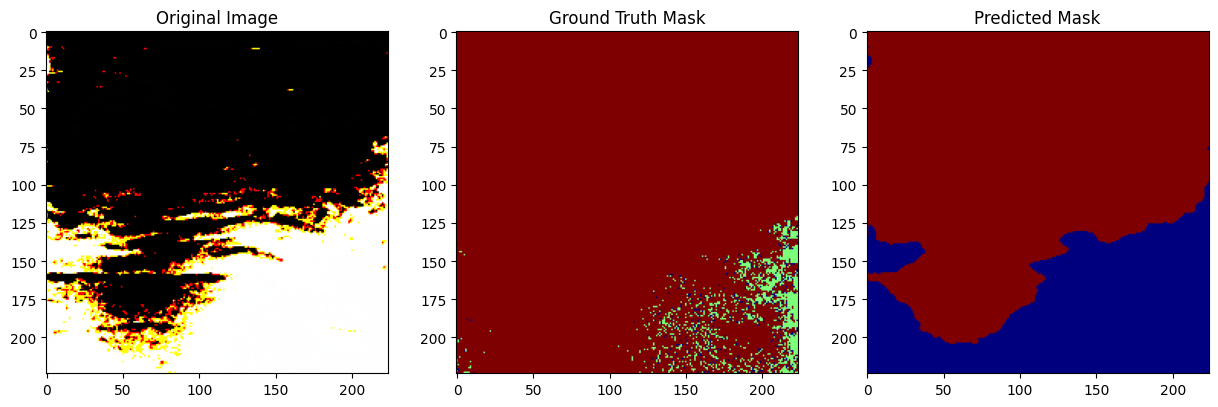

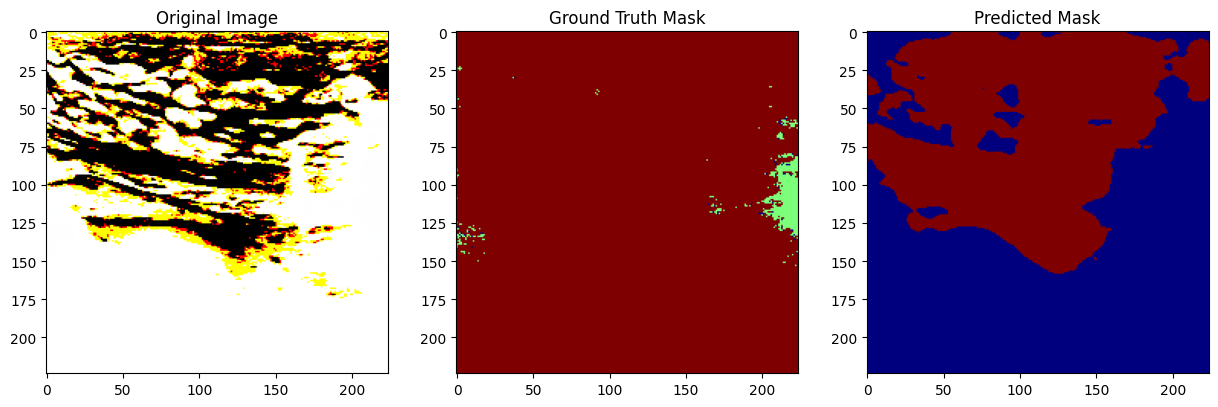

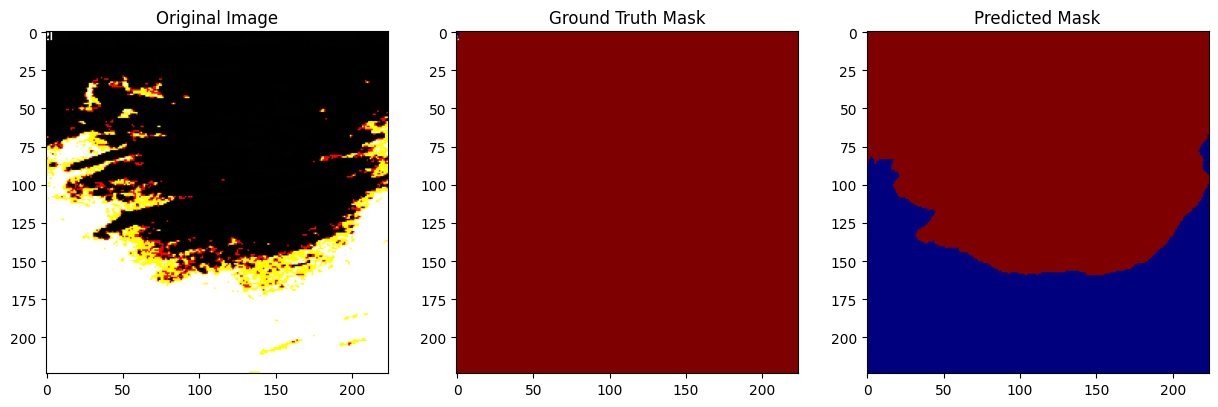

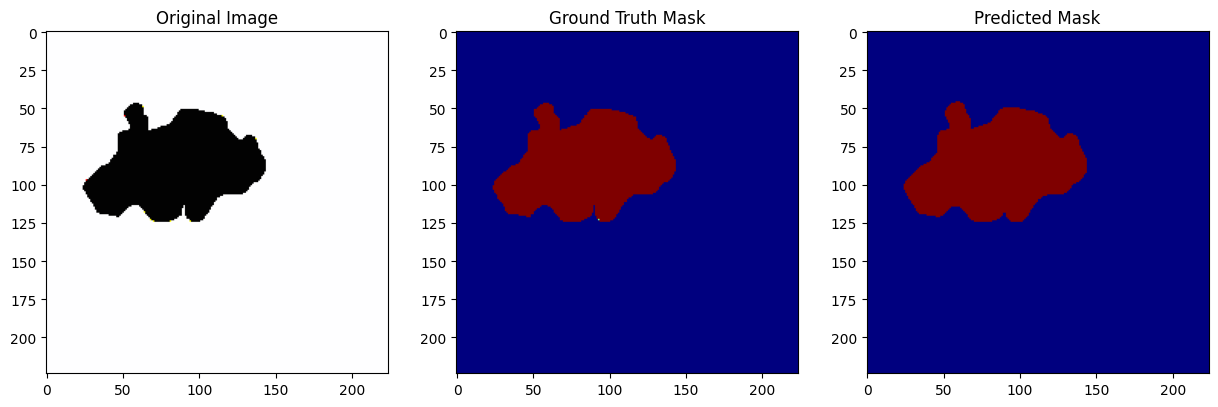

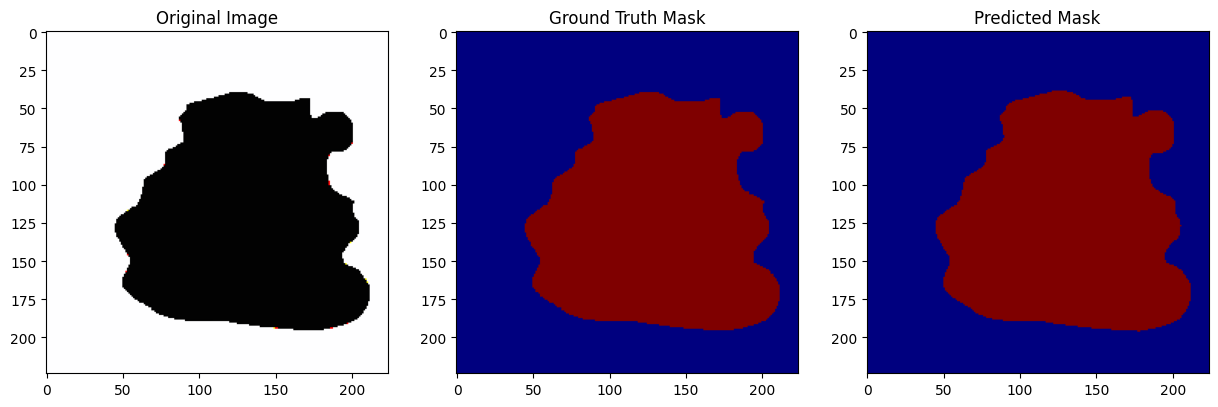

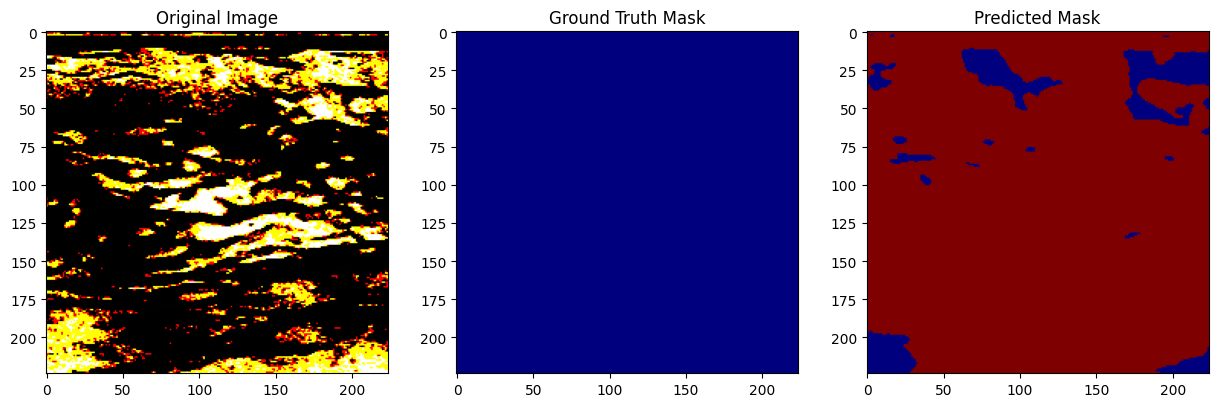

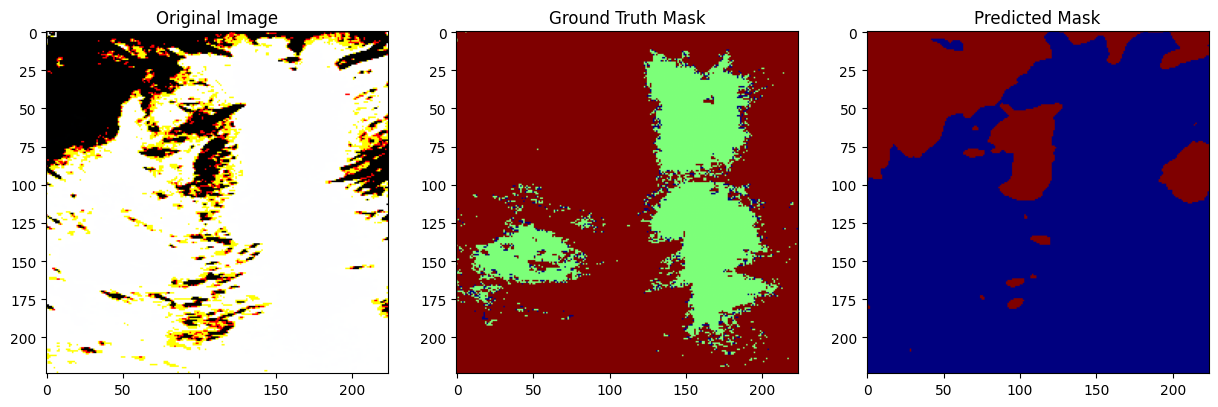

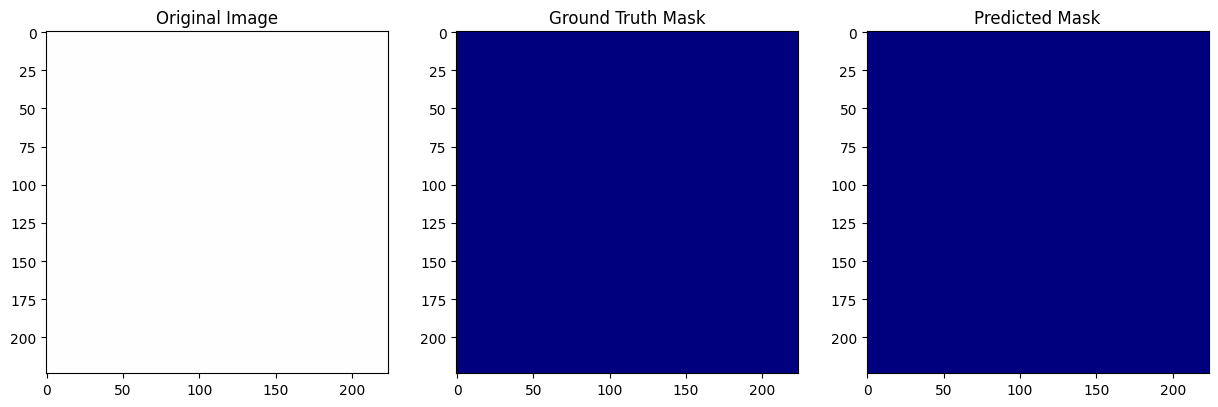

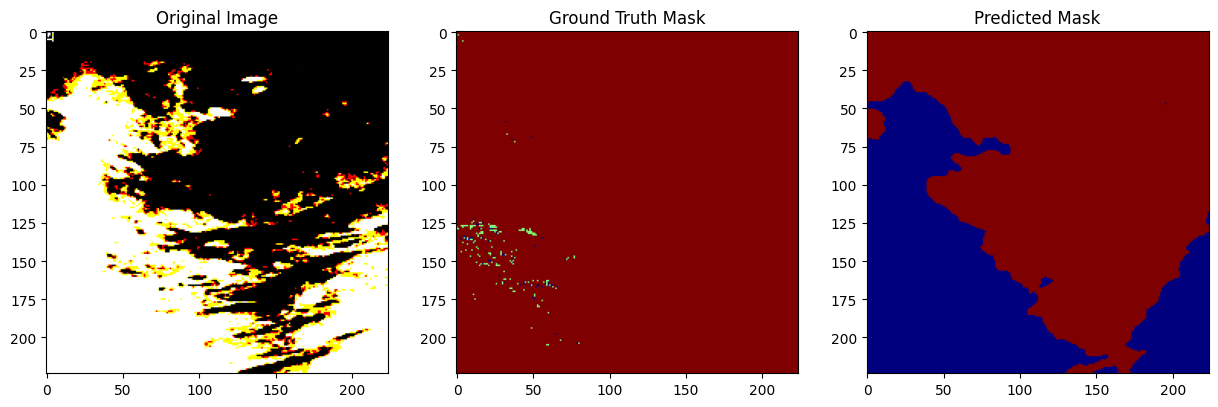

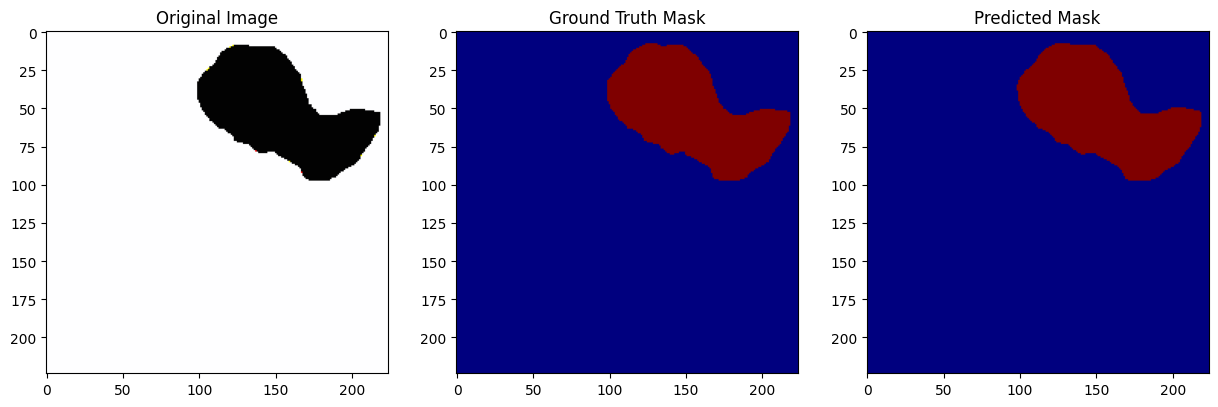

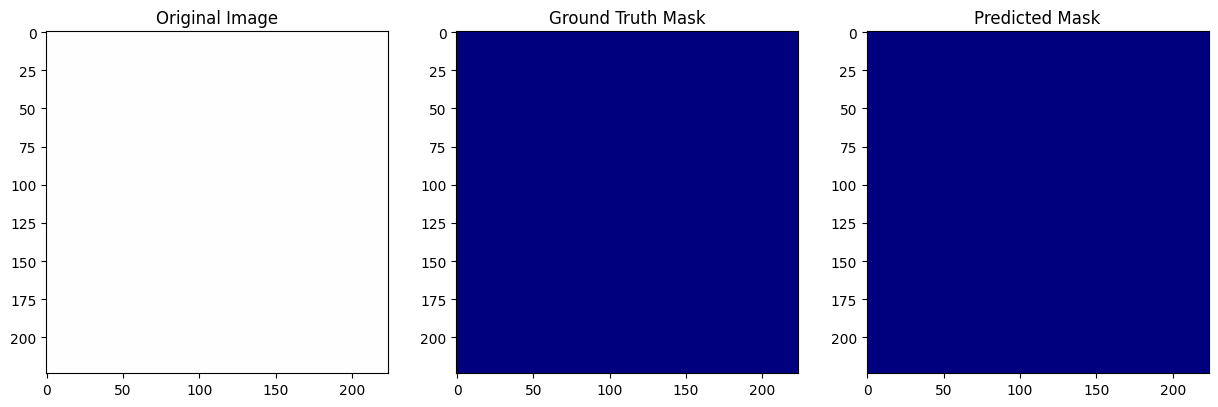

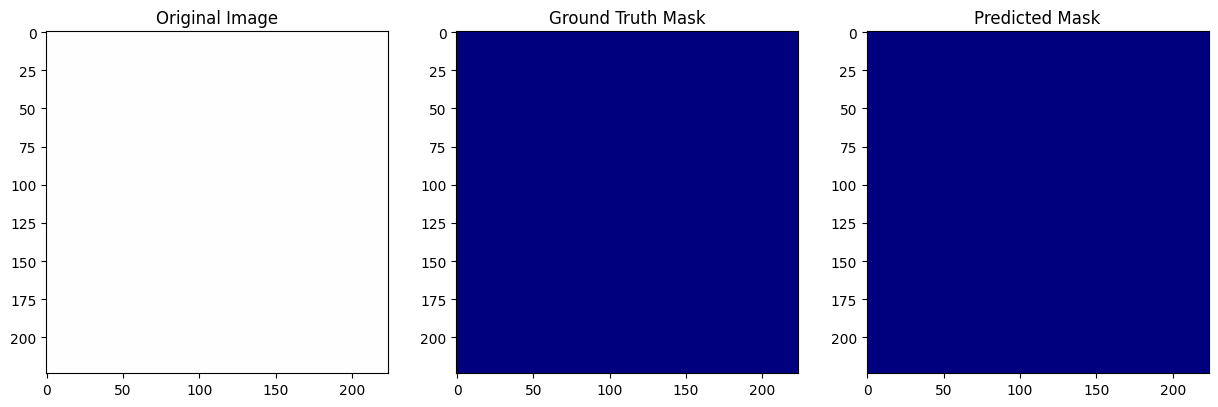

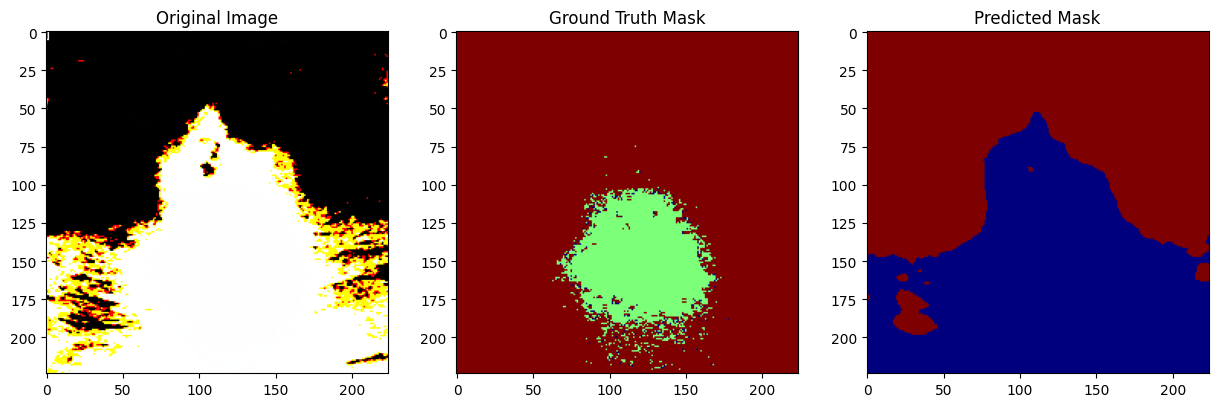

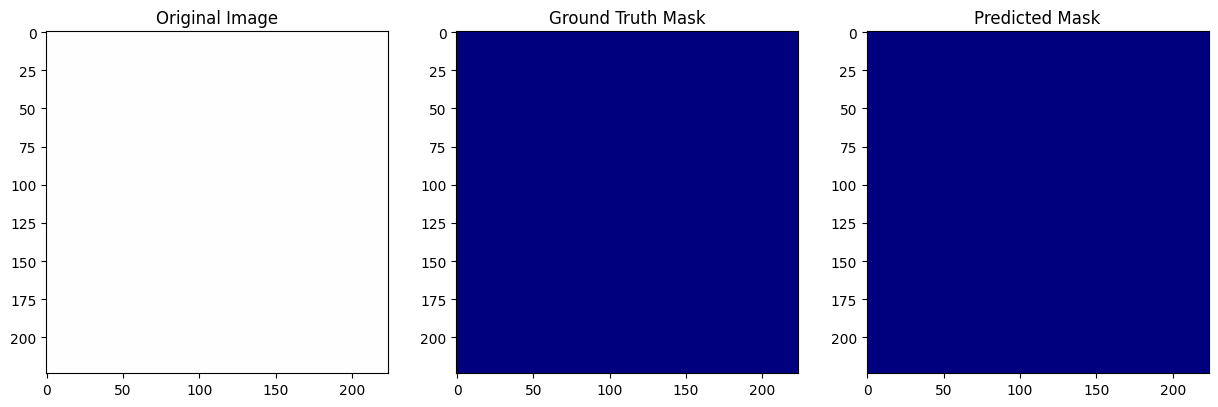

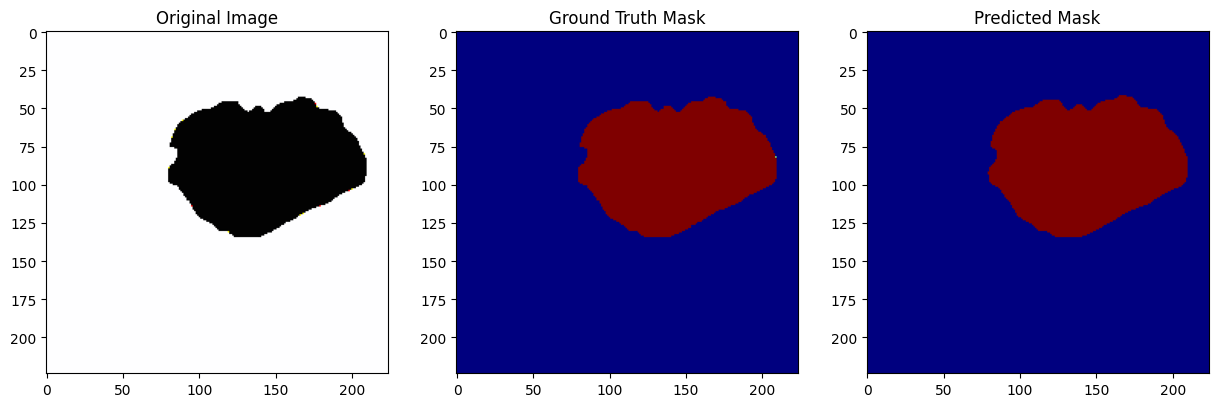

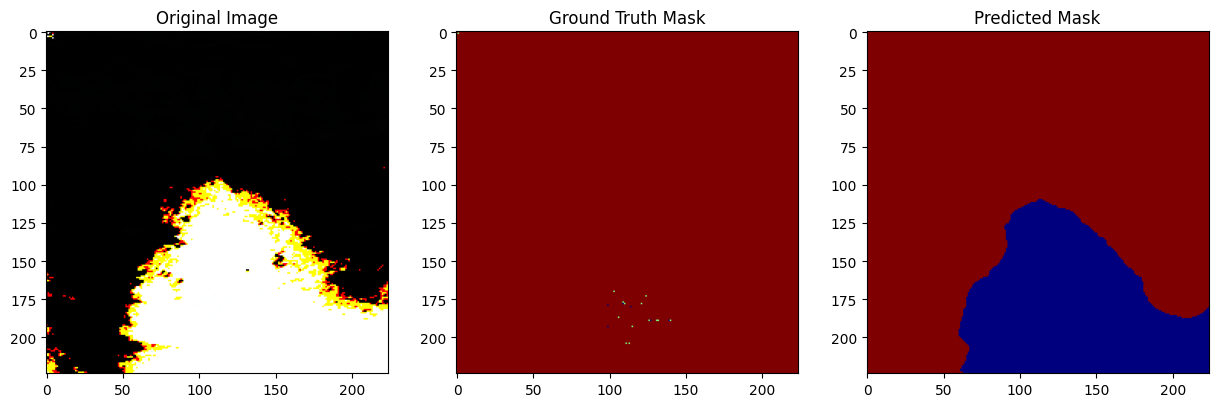

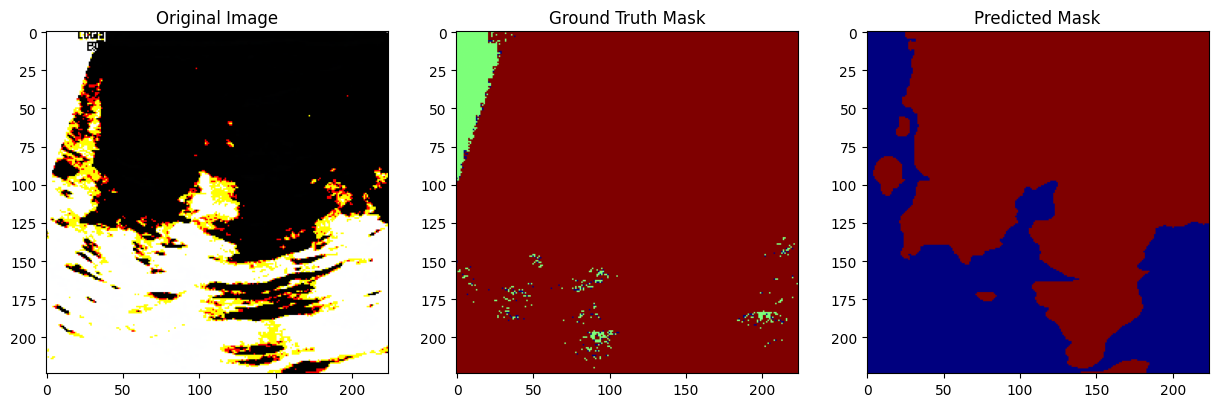

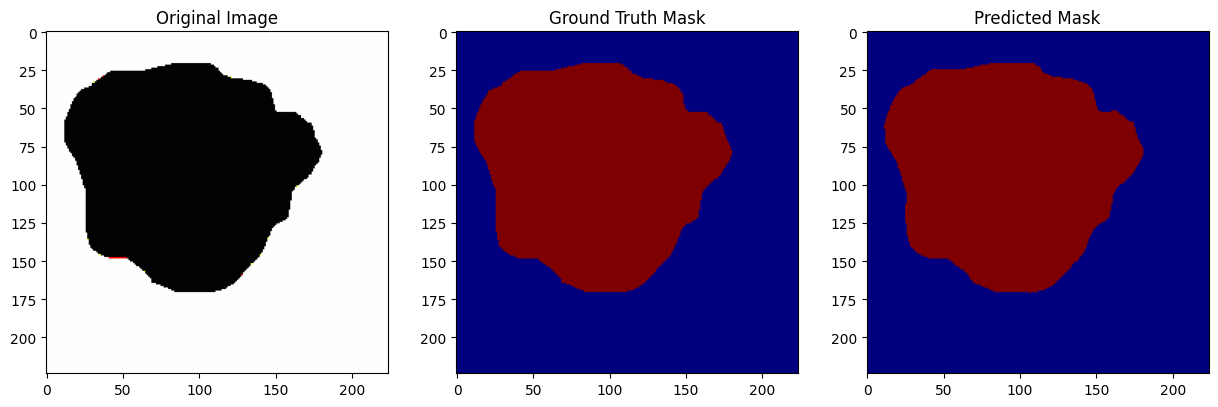

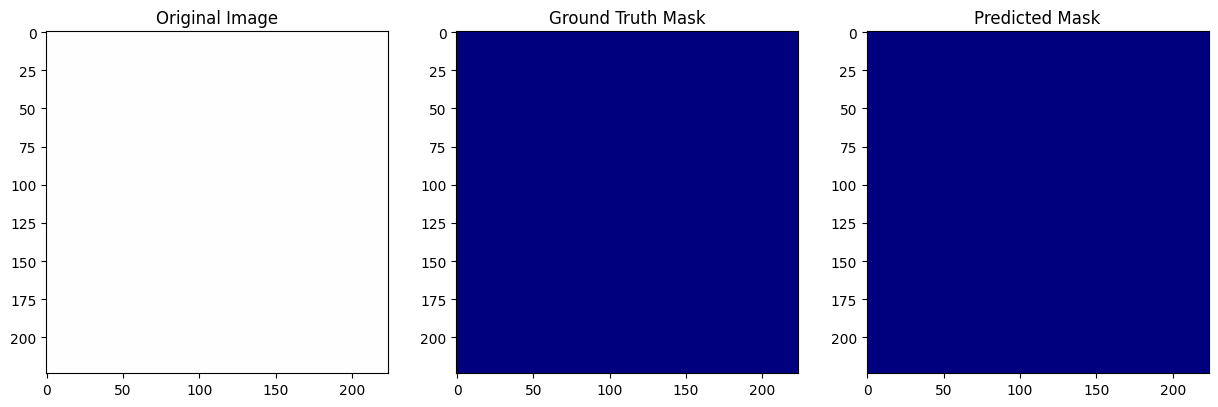

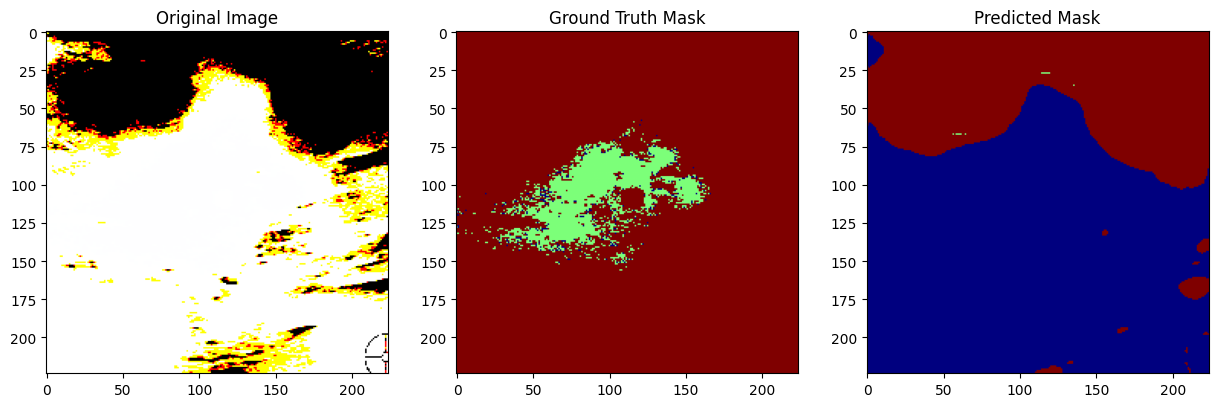

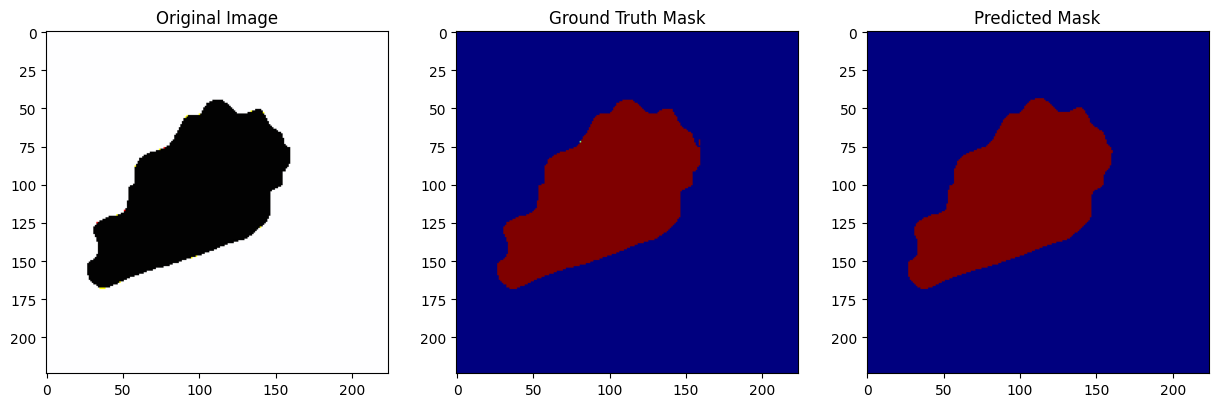

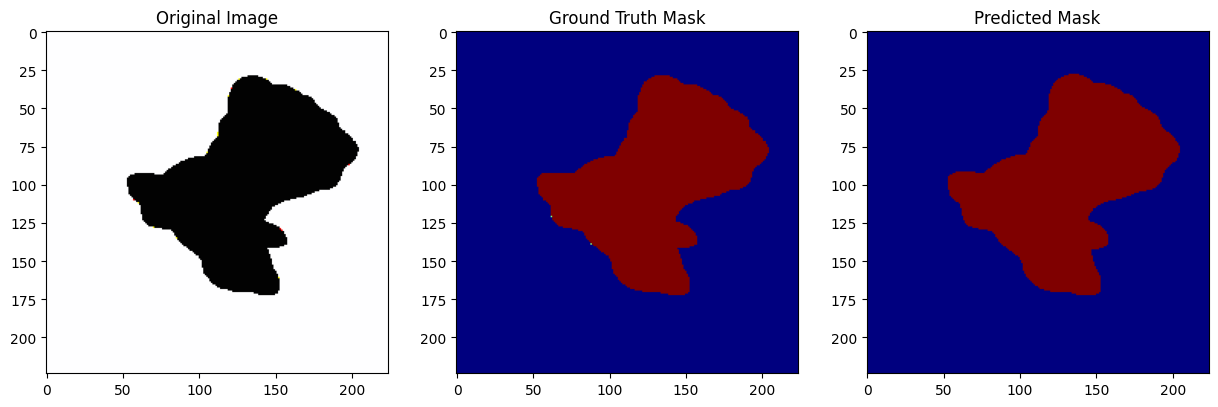

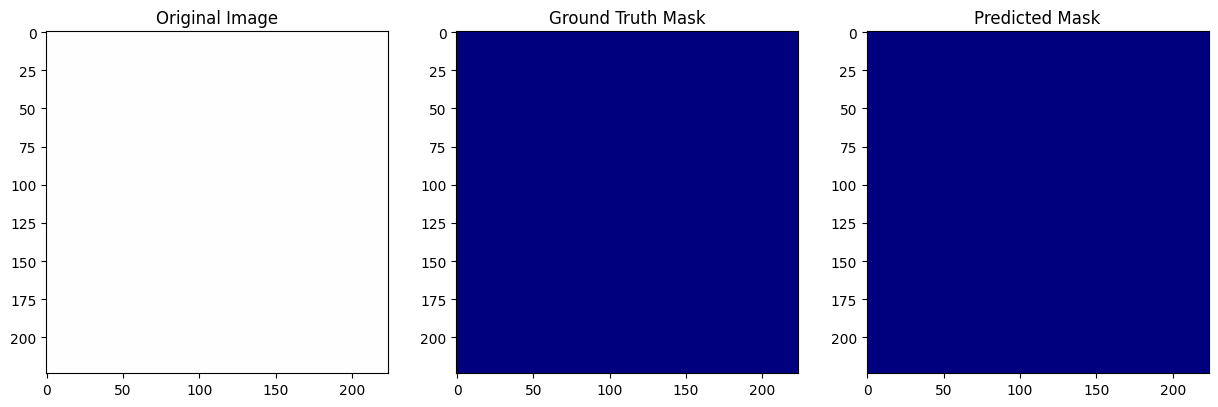

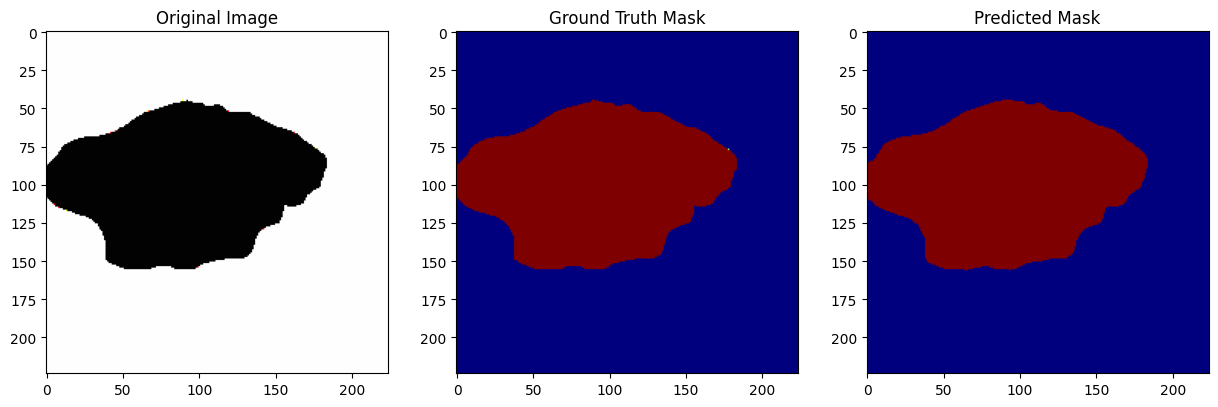

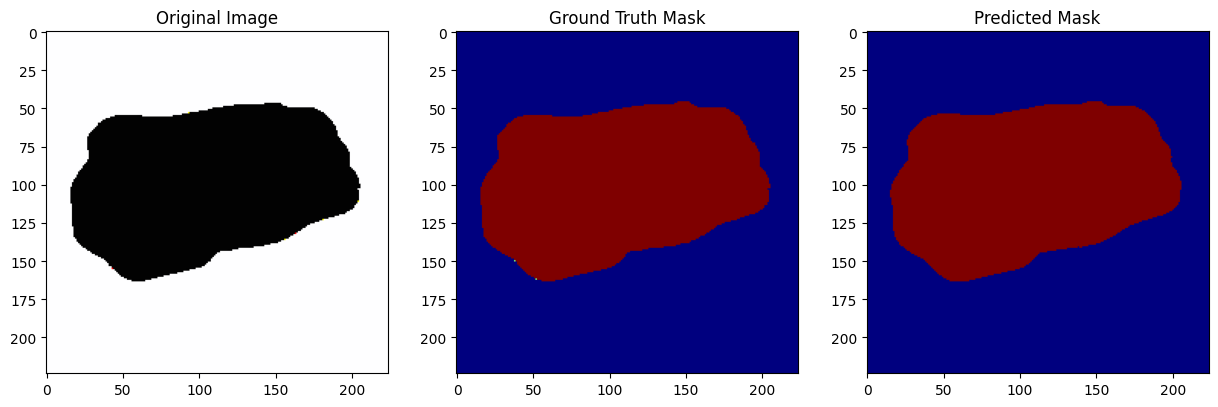

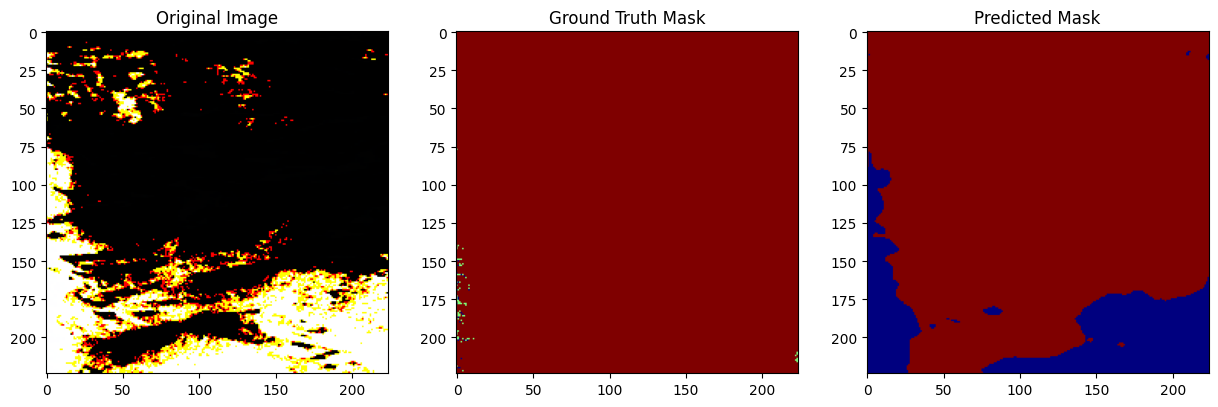

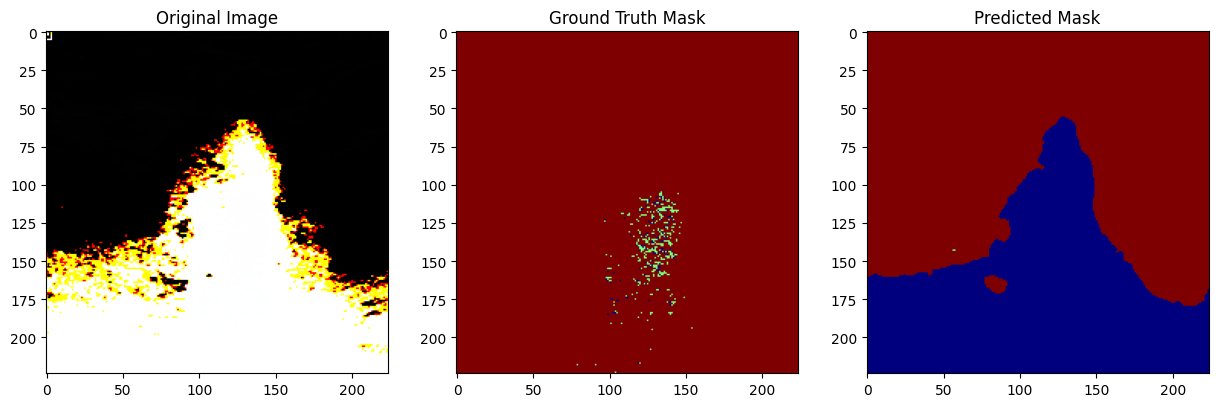

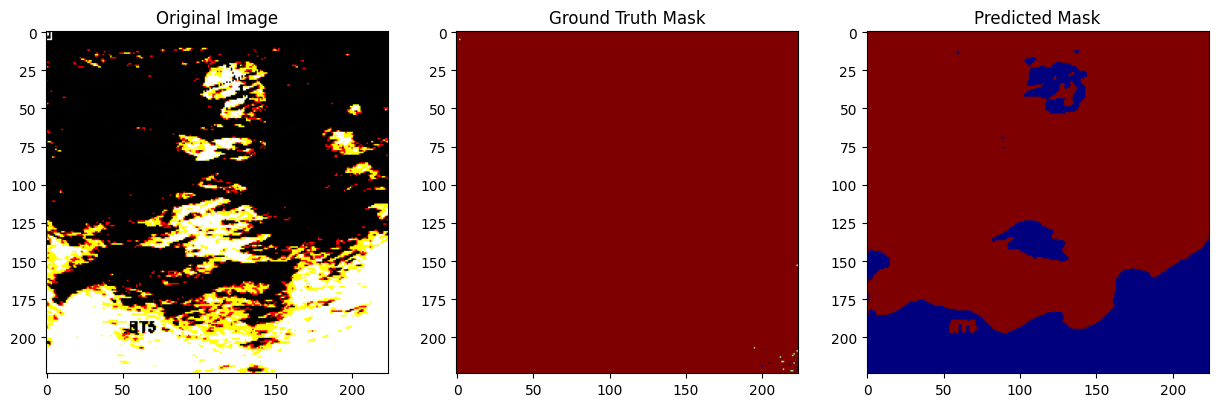

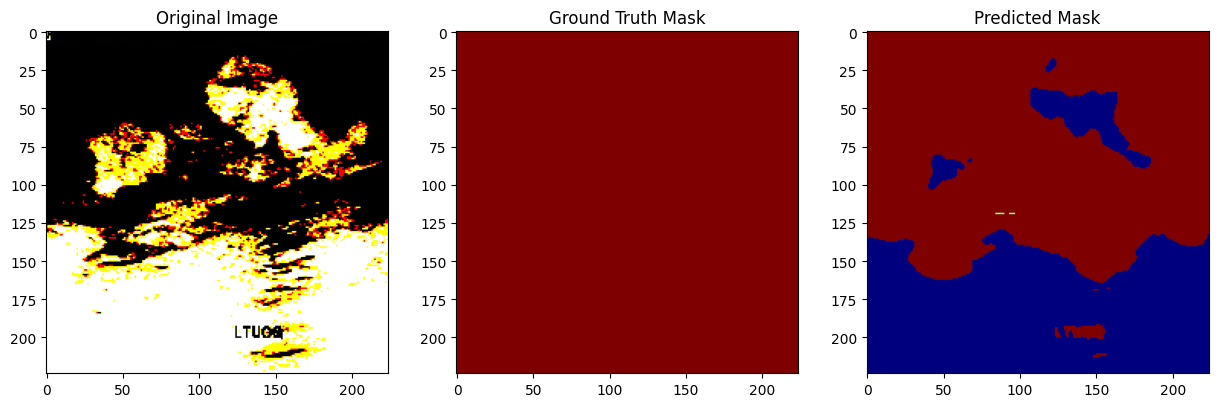

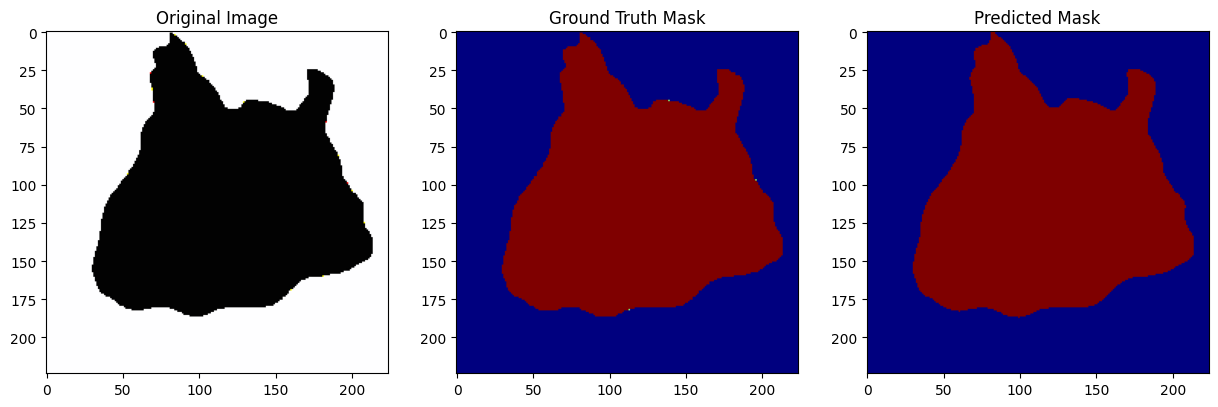

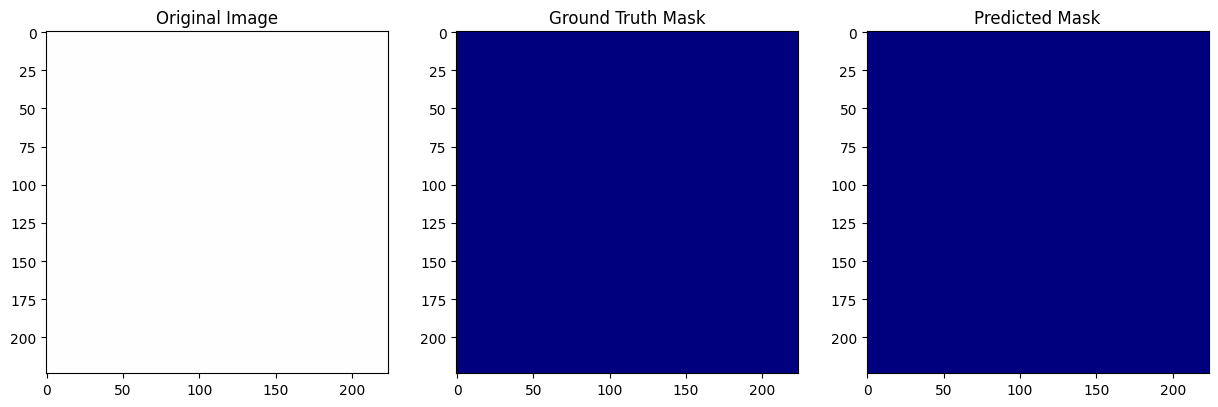

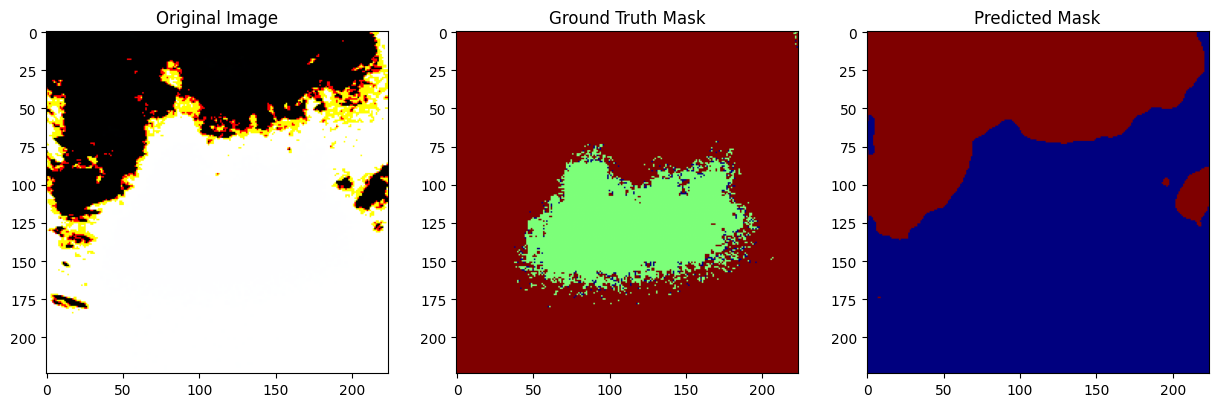

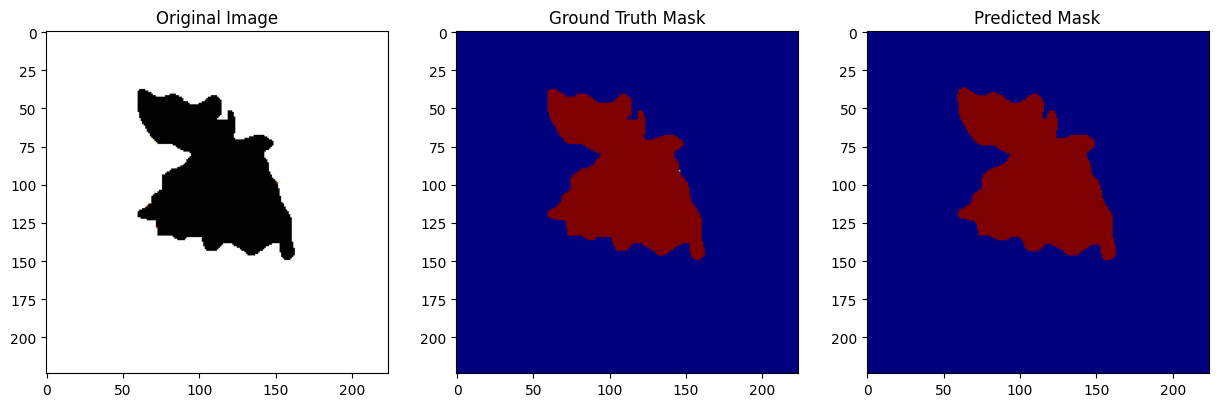

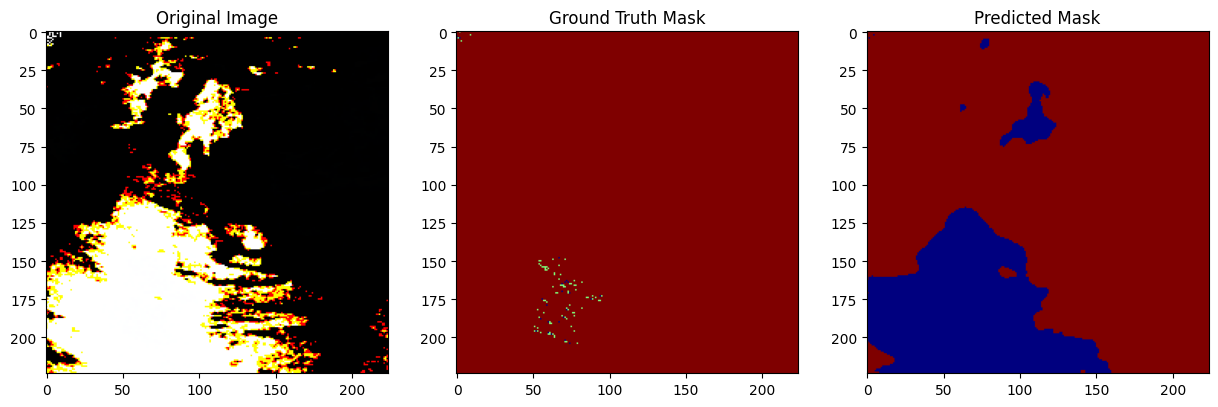

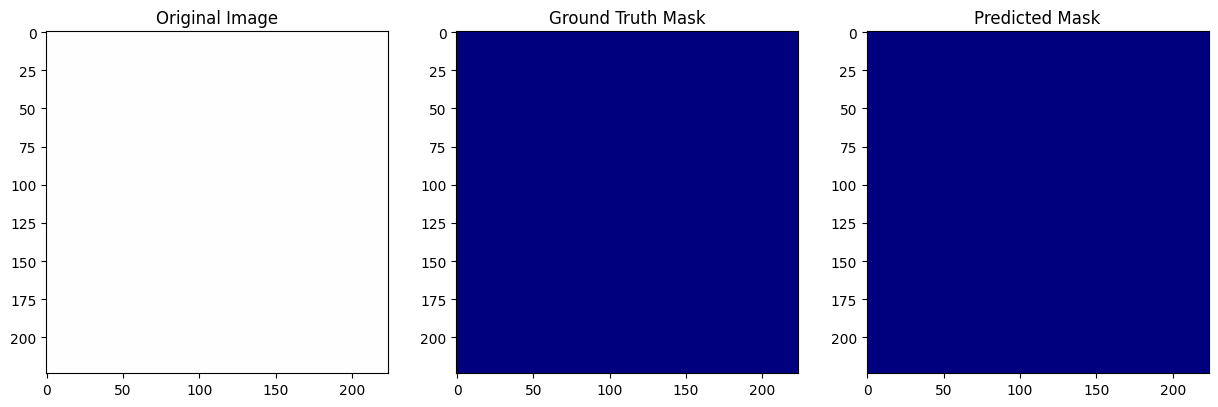

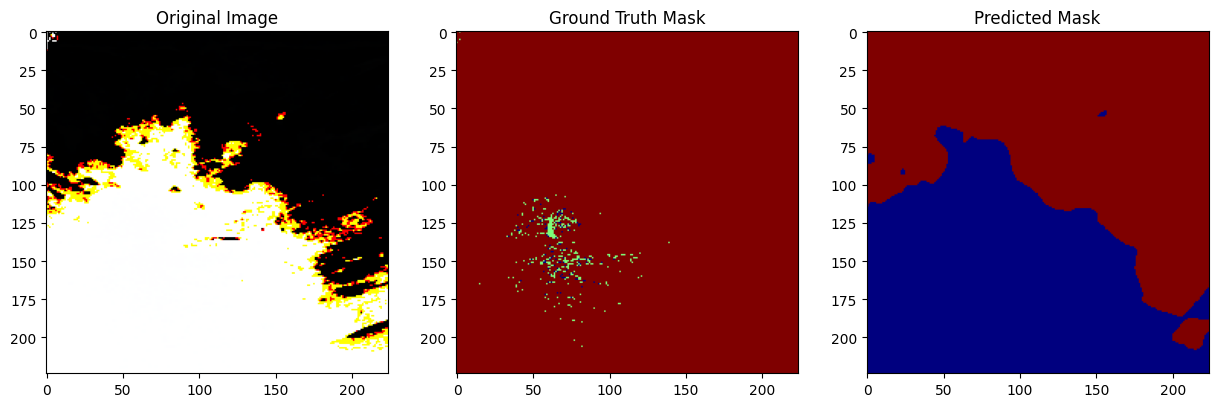

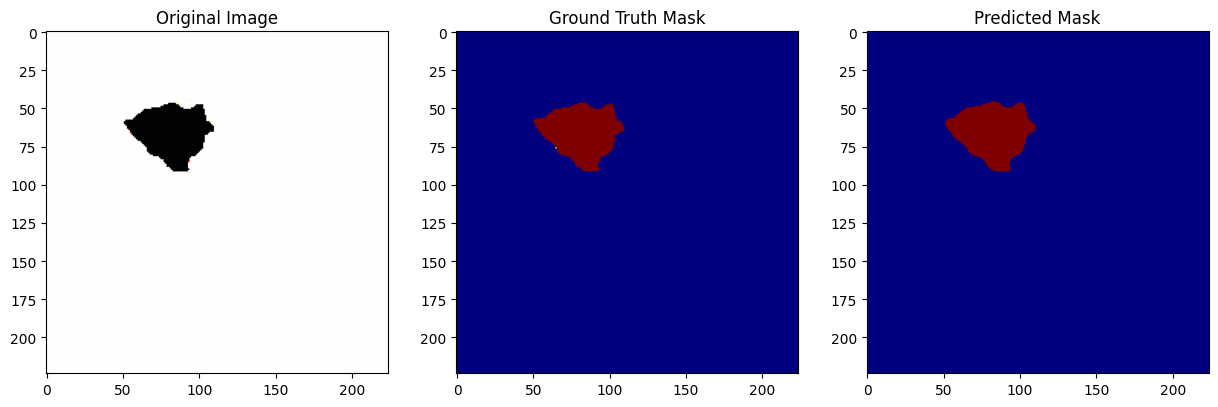

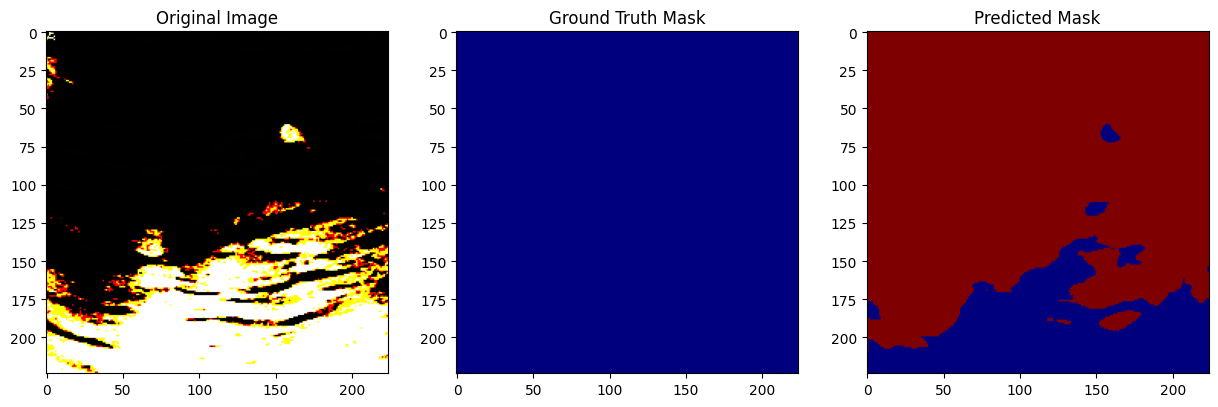

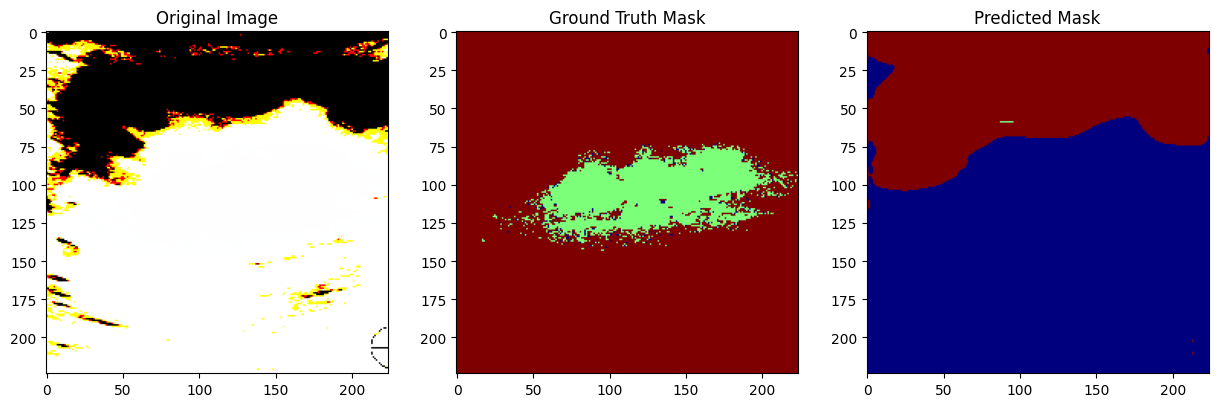

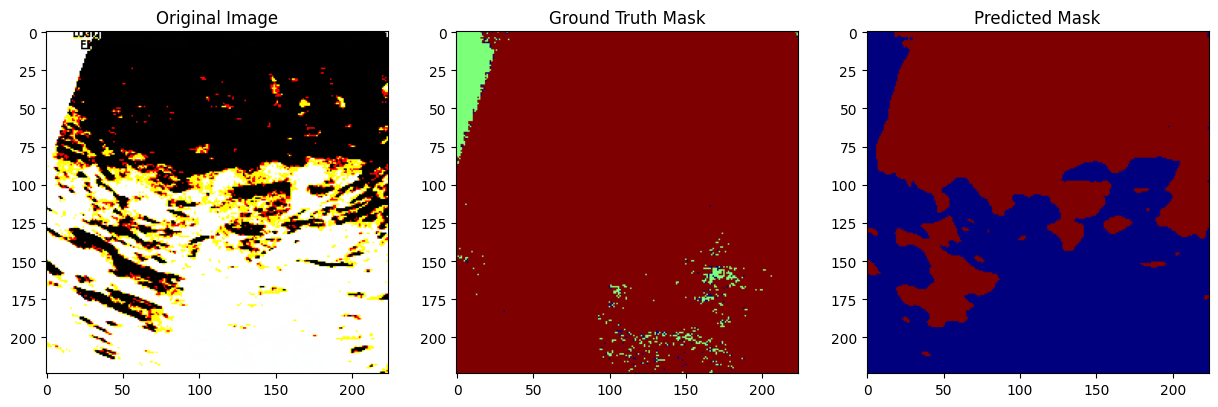

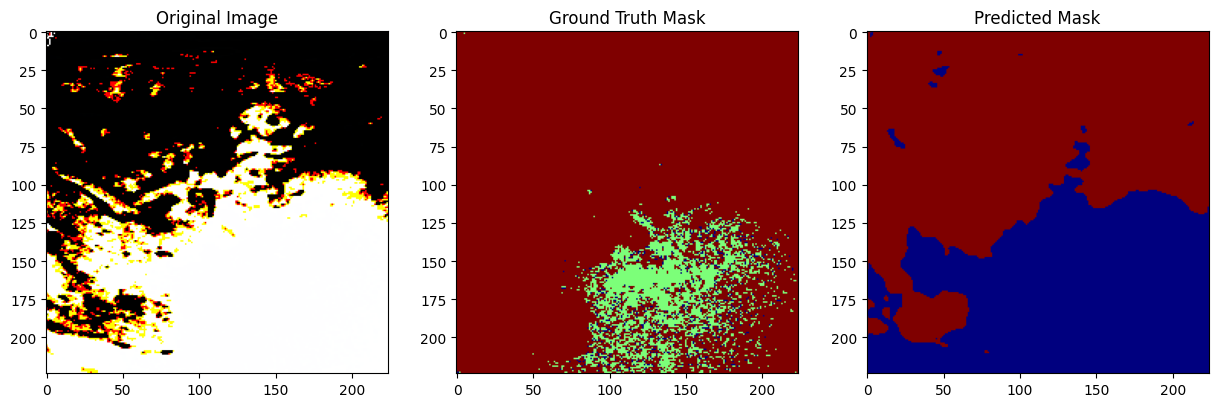

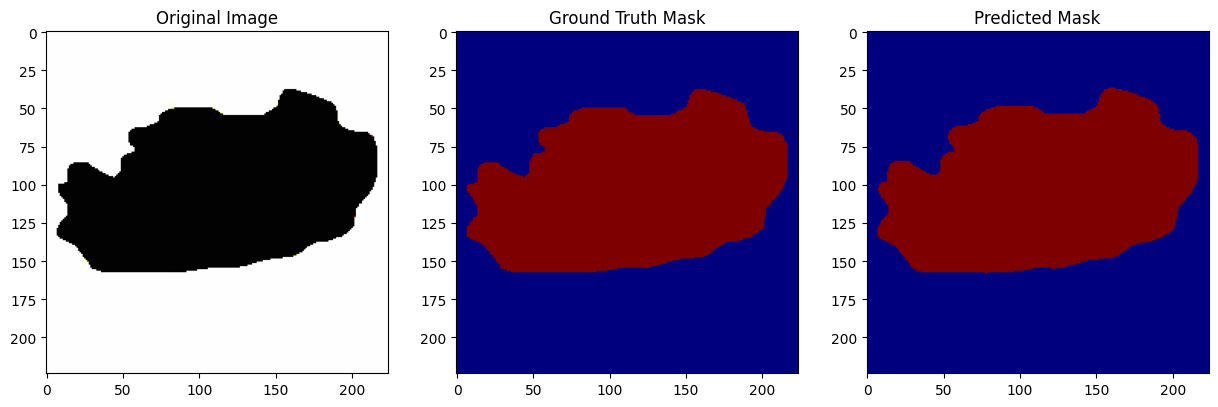

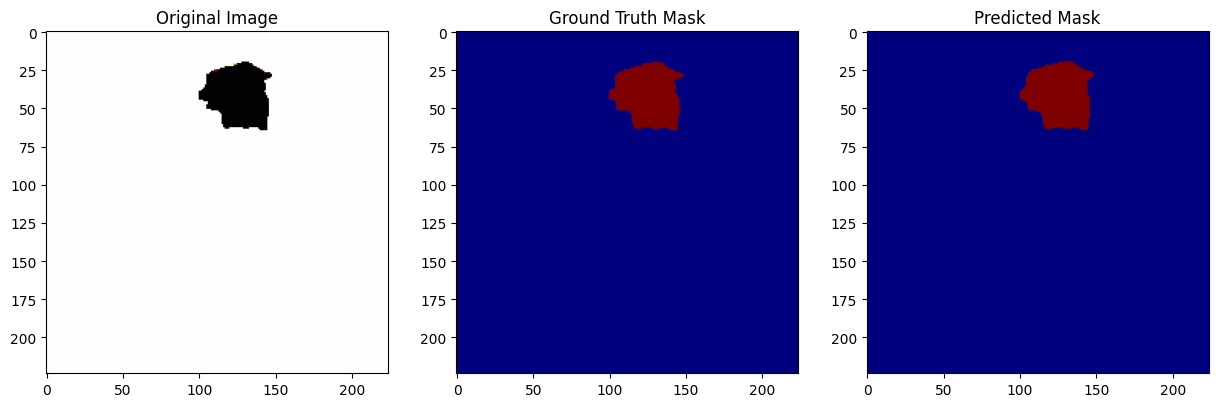

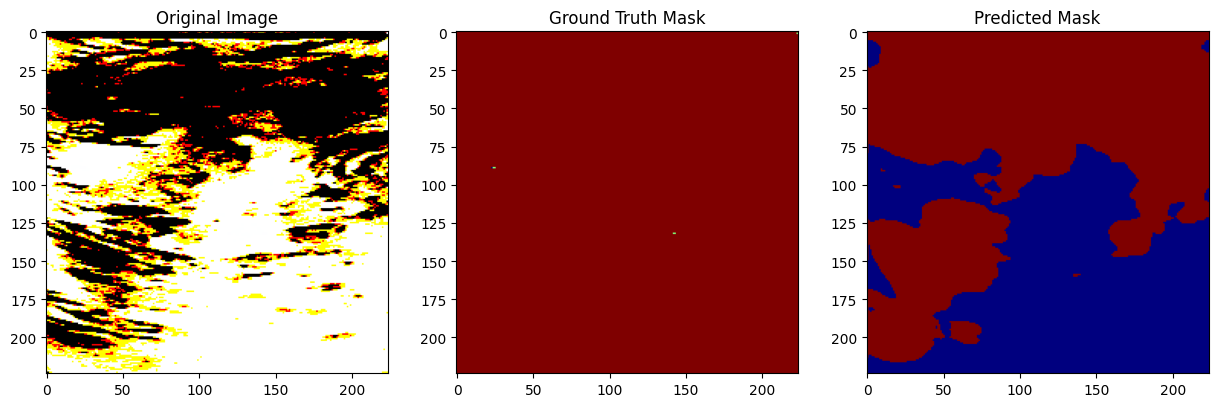

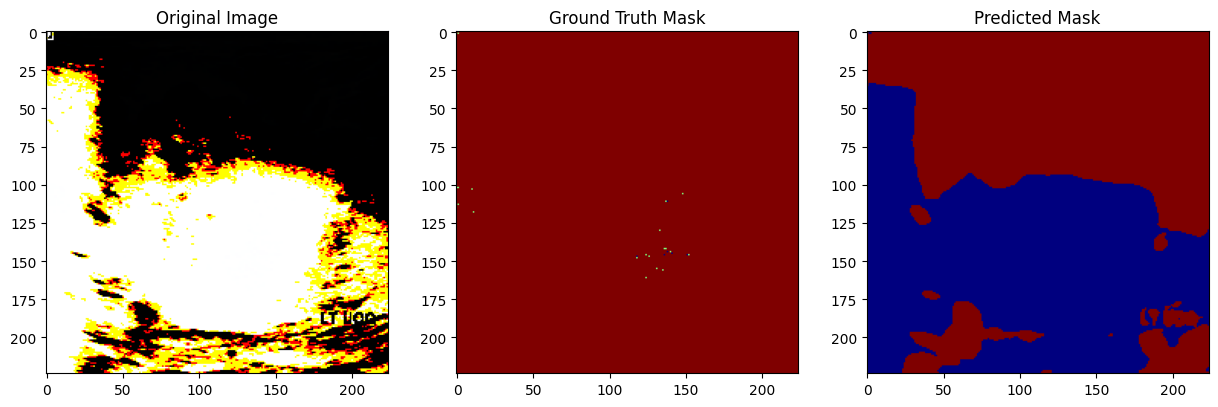

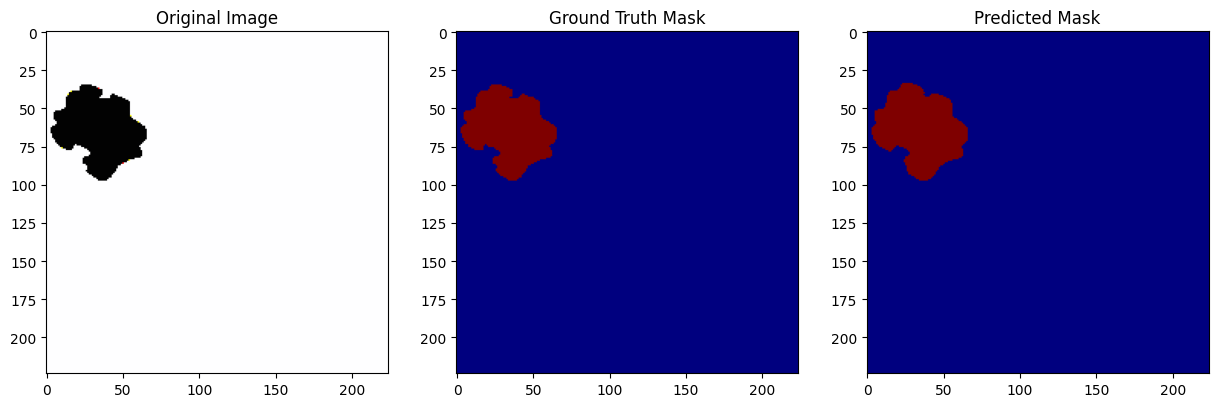

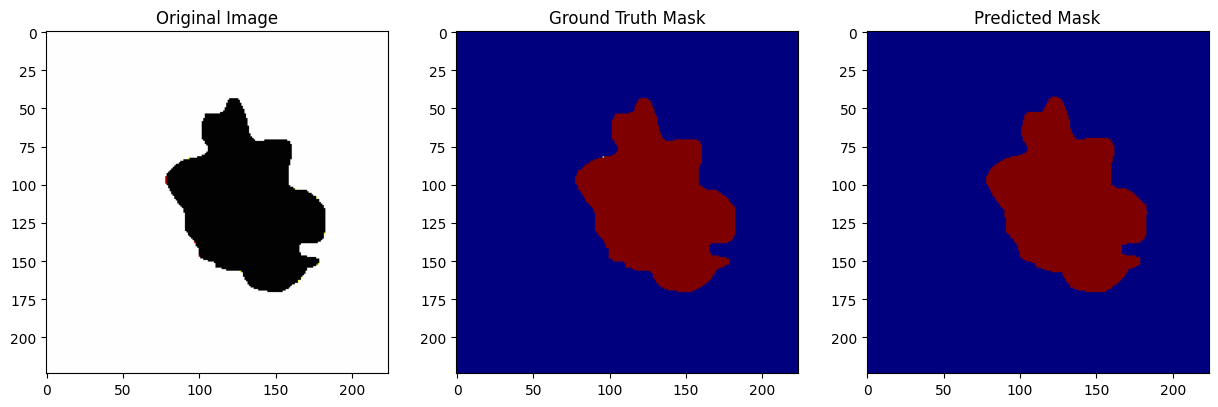

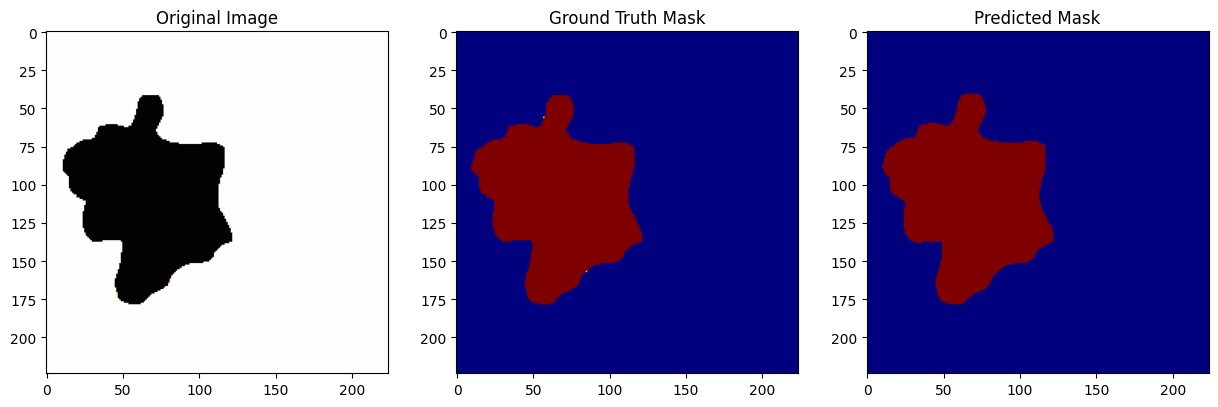

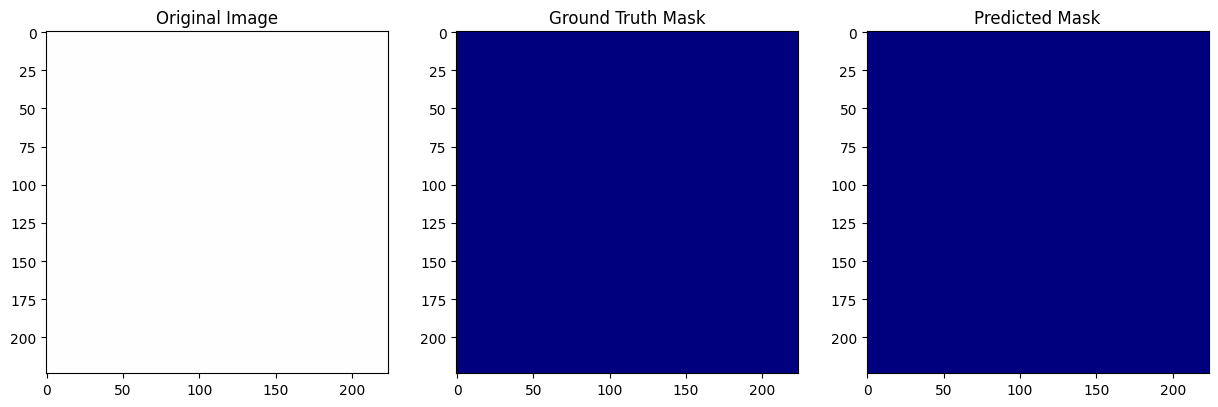

In [ ]:
# Step 4: Visualize the Results
for i in range(len(cancerous_images)):
    plt.figure(figsize=(15, 5))

    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(cancerous_images[i].astype('uint8'))
    plt.title('Original Image')

    # Ground Truth Mask (for one class, e.g., Benign)
    plt.subplot(1, 3, 2)
    plt.imshow(np.argmax(cancerous_masks[i], axis=-1), cmap='jet')
    plt.title('Ground Truth Mask')

    # Predicted Mask (for one class, e.g., Benign)
    plt.subplot(1, 3, 3)
    plt.imshow(np.argmax(predicted_masks[i], axis=-1), cmap='jet')
    plt.title('Predicted Mask')
    plt.show()

## **NEWWWWWW**

In [ ]:
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import Callback

# Step 1: Filter the Classified Images (Benign or Malignant)
cancerous_indices = np.where((y_pred == 1) | (y_pred == 2))[0]  # Indices of Benign and Malignant images
cancerous_images = X_test[cancerous_indices]

In [ ]:
# Step 2: Define the Multi-Class U-Net Model
def unet_model(input_size=(224, 224, 3), num_classes=3):  # num_classes = 3 for Benign, Malignant, Normal
    inputs = Input(input_size)

    # Downsample
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    # Bottleneck
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(conv5)

    # Upsample
    up6 = UpSampling2D(size=(2, 2))(conv5)
    up6 = concatenate([up6, conv4], axis=-1)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(up6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(conv6)
    up7 = UpSampling2D(size=(2, 2))(conv6)
    up7 = concatenate([up7, conv3], axis=-1)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(up7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(conv7)

    up8 = UpSampling2D(size=(2, 2))(conv7)
    up8 = concatenate([up8, conv2], axis=-1)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(up8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(conv8)

    up9 = UpSampling2D(size=(2, 2))(conv8)
    up9 = concatenate([up9, conv1], axis=-1)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(up9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(conv9)
    # Output layer for multi-class segmentation
    outputs = Conv2D(num_classes, 1, activation='softmax')(conv9)  # Softmax for multi-class

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


In [ ]:
# Load or define the U-Net model
num_classes = 3  # Benign, Malignant, Normal
unet = unet_model(num_classes=num_classes)
unet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Step 3: Prepare Ground Truth Masks for Multi-Class Segmentation
# Assuming you have ground truth masks in one-hot encoded format
def load_masks(filepaths, num_classes=3):
    masks = []
    for filepath in filepaths:
        mask = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (224, 224))
        # Ensure pixel values are within the expected range
        mask = np.clip(mask, 0, num_classes - 1) # clip values exceeding the range
        mask = to_categorical(mask, num_classes=num_classes)  # One-hot encode the mask
        masks.append(mask)
    return np.array(masks)

# Load masks for cancerous images (assuming you have them)
cancerous_masks = load_masks(test_df.iloc[cancerous_indices]['filepaths'].values, num_classes=num_classes)


In [ ]:
# Step 4: Define Dice Score Calculation
def dice_score(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

In [ ]:
# Step 5: Custom Callback to Track Dice Scores
class DiceScoreCallback(Callback):
    def __init__(self, train_data, val_data, num_classes): # Add num_classes
        super(DiceScoreCallback, self).__init__()
        self.train_data = train_data
        self.val_data = val_data
        self.train_dice_scores = []
        self.val_dice_scores = []
        self.num_classes = num_classes # Store num_classes

    def on_epoch_end(self, epoch, logs=None):
        # Calculate Dice score for training data
        train_pred = self.model.predict(self.train_data[0])
        # Convert predictions to class labels before calculating Dice score
        train_pred_labels = np.argmax(train_pred, axis=-1)
        train_true_labels = np.argmax(self.train_data[1], axis=-1) if self.train_data[1].ndim == 4 else self.train_data[1] # Convert to labels if one-hot encoded
        # Reshape train_true_labels to match train_pred_labels
        train_true_labels = train_true_labels[cancerous_indices]  # Select labels for cancerous images only
        train_true_labels = train_true_labels.flatten()
        train_pred_labels = train_pred_labels.flatten()

        train_dice = dice_score(train_true_labels, train_pred_labels) # Calculate Dice score on class labels
        self.train_dice_scores.append(train_dice)
        # Calculate Dice score for validation data
        val_pred = self.model.predict(self.val_data[0])
        # Convert predictions to class labels before calculating Dice score
        val_pred_labels = np.argmax(val_pred, axis=-1)
        val_true_labels = np.argmax(self.val_data[1], axis=-1) if self.val_data[1].ndim == 4 else self.val_data[1]  # Convert to labels if one-hot encoded
        # Reshape val_true_labels to match val_pred_labels
        val_true_labels = val_true_labels[cancerous_indices]  # Select labels for cancerous images only
        val_true_labels = val_true_labels.flatten()
        val_pred_labels = val_pred_labels.flatten()
        val_dice = dice_score(val_true_labels, val_pred_labels) # Calculate Dice score on class labels
        self.val_dice_scores.append(val_dice)

        print(f'Epoch {epoch + 1}: Train Dice = {train_dice:.4f}, Val Dice = {val_dice:.4f}')

In [ ]:
# Step 6: Train the U-Net Model with Dice Score Tracking
dice_callback = DiceScoreCallback(
    train_data=(X_train, to_categorical(y_train_encoded, num_classes=num_classes)),  # Convert y_train_encoded to one-hot
    val_data=(X_test, to_categorical(y_test_encoded, num_classes=num_classes)),  # Convert y_test_encoded to one-hot
    num_classes=num_classes # Pass num_classes to callback
)

NameError: name 'DiceScoreCallback' is not defined

In [ ]:
history = unet.fit(
    cancerous_images, cancerous_masks,
    batch_size=8,
    epochs=10,
    validation_split=0.2,
    callbacks=[dice_callback]
)

NameError: name 'unet' is not defined

In [ ]:
# Step 7: Visualize Training vs. Validation Dice Scores
plt.figure(figsize=(10, 5))
plt.plot(dice_callback.train_dice_scores, label='Train Dice Score')
plt.plot(dice_callback.val_dice_scores, label='Validation Dice Score')
plt.title('Training vs. Validation Dice Scores')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()
plt.show()

In [ ]:
# Step 8: Visualize Training and Validation Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Step 9: Visualize the Results with Actual and Predicted Class Labels
for i in range(len(cancerous_images)):
    plt.figure(figsize=(15, 5))

    # Original Image with Actual Class Label
    plt.subplot(1, 3, 1)
    plt.imshow(cancerous_images[i].astype('uint8'))
    actual_class = le.inverse_transform([y_test_encoded[cancerous_indices[i]]])[0]  # Get actual class label
    plt.title(f'Original Image\nActual Class: {actual_class}')
    plt.axis('off')  # Hide axes
    # Ground Truth Mask
    plt.subplot(1, 3, 2)
    plt.imshow(np.argmax(cancerous_masks[i], axis=-1), cmap='jet')
    plt.title('Ground Truth Mask')
    plt.axis('off')  # Hide axes

In [ ]:
  # Predicted Mask with Predicted Class Label
    plt.subplot(1, 3, 3)
    predicted_class_index = np.argmax(np.mean(predicted_masks[i], axis=(0, 1)))  # Predicted class index
    predicted_class = le.inverse_transform([predicted_class_index])[0]  # Get predicted class label
    plt.imshow(np.argmax(predicted_masks[i], axis=-1), cmap='jet')
    plt.title(f'Predicted Mask\nPredicted Class: {predicted_class}')
    plt.axis('off')  # Hide axes

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()